парсинг waypoints с сайта https://opennav.com/waypoint/RU в json {name, lat, lon}

In [ ]:
import requests
from bs4 import BeautifulSoup
import json
import re

URL = "https://opennav.com/waypoint/RU"


def dms_to_decimal(dms):
    pattern = r"(\d+)°\s*(\d+)'?\s*([\d.]+)\"?\s*([NSEW])"
    match = re.search(pattern, dms.strip())
    if not match:
        return None

    deg = float(match.group(1))
    minutes = float(match.group(2))
    seconds = float(match.group(3))
    direction = match.group(4)

    decimal = deg + minutes / 60 + seconds / 3600
    if direction in ["S", "W"]:
        decimal *= -1

    return decimal


def parse_waypoints():
    r = requests.get(URL)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    table = soup.find("table", {"class": "datagrid fullwidth"})
    rows = table.find_all("tr")

    waypoints = []

    for row in rows:
        cols = row.find_all("td")

        # пропускаем строки не с данными
        if len(cols) != 5:
            continue

        link = cols[0].find("a")
        if not link:
            continue

        name = link.text.strip()
        lat_str = cols[2].text.strip()
        lon_str = cols[4].text.strip()

        lat = dms_to_decimal(lat_str)
        lon = dms_to_decimal(lon_str)

        if lat is None or lon is None:
            continue

        waypoints.append({
            "name": name,
            "lat": lat,
            "lon": lon
        })

    return waypoints


if __name__ == "__main__":
    data = parse_waypoints()

    with open("russia_waypoints.json", "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

    print(f"Сохранено {len(data)} waypoints")


Сохранено 1865 waypoints


важно помнить, что эти точки обозначены не для международных рейсов

In [ ]:
import json
import plotly.graph_objects as go

# загрузка данных
with open("russia_waypoints.json", "r", encoding="utf-8") as f:
    waypoints = json.load(f)

names = [wp["name"] for wp in waypoints]
lats = [wp["lat"] for wp in waypoints]
lons = [wp["lon"] for wp in waypoints]

# карта
fig = go.Figure()

fig.add_trace(go.Scattergeo(
    lon=lons,
    lat=lats,
    text=names,
    mode='markers',
    marker=dict(
        size=4
    )
))

fig.update_layout(
    title="Waypoints Russia",
    geo=dict(
        projection_type="natural earth",
        showland=True,
        landcolor="rgb(230, 230, 230)",
        showcountries=True,
        countrycolor="rgb(150,150,150)",
        coastlinecolor="rgb(100,100,100)"
    ),
    width=1200,
    height=700
)

fig.show()


In [ ]:
airports_coords=[
  { "name": "Sheremetyevo", "coords": [55.9726, 37.4146] },
  { "name": "Pulkovo",     "coords": [59.8003, 30.2625] },
  { "name": "Tolmachevo",  "coords": [55.0126, 82.6507] },
  { "name": "Sochi",       "coords": [43.4499, 39.9566] },
  { "name": "Kazan",       "coords": [55.6062, 49.2787] },
  { "name": "Knevichi",    "coords": [43.3990, 132.1480] },
  { "name": "Novy",        "coords": [48.5280, 135.1880] },
  { "name": "Yelizovo",    "coords": [53.1679, 158.4539] }
]


In [ ]:
import json
import math
import random
import heapq
from typing import List, Dict, Tuple, Optional

# ── Аэропорты ────────────────────────────────────────────────────────────────
AIRPORTS = [
    {"name": "Sheremetyevo", "coords": [55.9726, 37.4146]},
    {"name": "Pulkovo",      "coords": [59.8003, 30.2625]},
    {"name": "Tolmachevo",   "coords": [55.0126, 82.6507]},
    {"name": "Sochi",        "coords": [43.4499, 39.9566]},
    {"name": "Kazan",        "coords": [55.6062, 49.2787]},
    {"name": "Knevichi",     "coords": [43.3990, 132.1480]},
    {"name": "Novy",         "coords": [48.5280, 135.1880]},
    {"name": "Yelizovo",     "coords": [53.1679, 158.4539]},
]

WAYPOINTS_FILE = "russia_waypoints.json"


# ── Геодезия ─────────────────────────────────────────────────────────────────
def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Расстояние между двумя точками на сфере (км)."""
    R = 6371.0
    φ1, φ2 = math.radians(lat1), math.radians(lat2)
    dφ = math.radians(lat2 - lat1)
    dλ = math.radians(lon2 - lon1)
    a = math.sin(dφ / 2) ** 2 + math.cos(φ1) * math.cos(φ2) * math.sin(dλ / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# ── Загрузка waypoints ────────────────────────────────────────────────────────
def load_waypoints(path: str) -> List[Dict]:
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    # Поддерживаем как список, так и обёртку {"waypoints": [...]}
    if isinstance(data, list):
        return data
    for key in ("waypoints", "data", "points"):
        if key in data:
            return data[key]
    raise ValueError("Не удалось распознать структуру файла waypoints")


# ── Поиск ближайшего waypoint к аэропорту ────────────────────────────────────
def nearest_waypoint_index(waypoints: List[Dict], lat: float, lon: float) -> int:
    best_i, best_d = 0, float("inf")
    for i, wp in enumerate(waypoints):
        d = haversine(lat, lon, wp["lat"], wp["lon"])
        if d < best_d:
            best_d, best_i = d, i
    return best_i


# ── Построение графа соседей (K ближайших) ────────────────────────────────────
def build_graph(waypoints: List[Dict], k: int = 8) -> Dict[int, List[Tuple[float, int]]]:
    """Для каждого узла — k ближайших соседей (dist, idx)."""
    n = len(waypoints)
    graph: Dict[int, List[Tuple[float, int]]] = {i: [] for i in range(n)}
    for i in range(n):
        dists = []
        for j in range(n):
            if i == j:
                continue
            d = haversine(waypoints[i]["lat"], waypoints[i]["lon"],
                          waypoints[j]["lat"], waypoints[j]["lon"])
            dists.append((d, j))
        dists.sort()
        graph[i] = dists[:k]
    return graph


# ── A* по графу ──────────────────────────────────────────────────────────────
def astar(graph: Dict[int, List[Tuple[float, int]]],
          waypoints: List[Dict],
          start: int, goal: int) -> Optional[List[int]]:
    open_heap: List[Tuple[float, int, List[int]]] = []
    heapq.heappush(open_heap, (0.0, start, [start]))
    visited = {}

    goal_lat = waypoints[goal]["lat"]
    goal_lon = waypoints[goal]["lon"]

    while open_heap:
        cost, node, path = heapq.heappop(open_heap)

        if node == goal:
            return path

        if node in visited and visited[node] <= cost:
            continue
        visited[node] = cost

        for edge_dist, neighbor in graph[node]:
            new_cost = cost + edge_dist
            h = haversine(waypoints[neighbor]["lat"], waypoints[neighbor]["lon"],
                          goal_lat, goal_lon)
            heapq.heappush(open_heap, (new_cost + h, neighbor, path + [neighbor]))

    return None


# ── Аппроксимация маршрута к N точкам ────────────────────────────────────────
def approximate_route(route_coords: List[Tuple[float, float]], n: int = 20) -> List[Tuple[float, float]]:
    """
    Равномерно выбирает n точек вдоль маршрута по накопленному расстоянию.
    """
    if len(route_coords) <= n:
        return list(route_coords)

    # Накопленные расстояния
    cum = [0.0]
    for i in range(1, len(route_coords)):
        d = haversine(*route_coords[i - 1], *route_coords[i])
        cum.append(cum[-1] + d)
    total = cum[-1]

    result = []
    for k in range(n):
        target = total * k / (n - 1)
        # Найти сегмент
        for i in range(1, len(cum)):
            if cum[i] >= target or i == len(cum) - 1:
                seg_len = cum[i] - cum[i - 1]
                if seg_len == 0:
                    lat, lon = route_coords[i]
                else:
                    t = (target - cum[i - 1]) / seg_len
                    lat = route_coords[i - 1][0] + t * (route_coords[i][0] - route_coords[i - 1][0])
                    lon = route_coords[i - 1][1] + t * (route_coords[i][1] - route_coords[i - 1][1])
                result.append((round(lat, 6), round(lon, 6)))
                break
    return result


# ── Основная логика ───────────────────────────────────────────────────────────
def simulate(waypoints_path: str = WAYPOINTS_FILE, k_neighbors: int = 8) -> Dict:
    print("Загрузка waypoints...")
    waypoints = load_waypoints(waypoints_path)
    print(f"  Загружено {len(waypoints)} точек")

    # Случайный выбор аэропортов (разные)
    dep_ap, arr_ap = random.sample(AIRPORTS, 2)
    print(f"\nМаршрут: {dep_ap['name']} → {arr_ap['name']}")

    # Ближайшие waypoints к аэропортам
    dep_lat, dep_lon = dep_ap["coords"]
    arr_lat, arr_lon = arr_ap["coords"]
    start_idx = nearest_waypoint_index(waypoints, dep_lat, dep_lon)
    goal_idx  = nearest_waypoint_index(waypoints, arr_lat, arr_lon)

    print(f"  Ближайший WP к вылету:  [{start_idx}] {waypoints[start_idx]['name']} "
          f"({waypoints[start_idx]['lat']:.4f}, {waypoints[start_idx]['lon']:.4f})")
    print(f"  Ближайший WP к прилёту: [{goal_idx}] {waypoints[goal_idx]['name']} "
          f"({waypoints[goal_idx]['lat']:.4f}, {waypoints[goal_idx]['lon']:.4f})")

    # Построение графа
    print(f"\nПостроение графа (k={k_neighbors})...")
    graph = build_graph(waypoints, k=k_neighbors)

    # A* поиск
    print("Поиск кратчайшего пути (A*)...")
    path_indices = astar(graph, waypoints, start_idx, goal_idx)

    if path_indices is None:
        raise RuntimeError("Путь не найден — попробуйте увеличить k_neighbors")

    print(f"  Найден путь из {len(path_indices)} waypoints")

    # Координаты маршрута (включая сами аэропорты на концах)
    route_coords: List[Tuple[float, float]] = (
        [(dep_lat, dep_lon)]
        + [(waypoints[i]["lat"], waypoints[i]["lon"]) for i in path_indices]
        + [(arr_lat, arr_lon)]
    )

    # Waypoints маршрута (без аэропортов — только найденные WP)
    route_waypoints = [
        {"name": waypoints[i]["name"], "lat": waypoints[i]["lat"], "lon": waypoints[i]["lon"]}
        for i in path_indices
    ]

    # Аппроксимация к 20 позициям
    approx_20 = approximate_route(route_coords, n=20)
    approx_list = [{"lat": lat, "lon": lon} for lat, lon in approx_20]

    result = {
        "departure": {"name": dep_ap["name"], "lat": dep_lat, "lon": dep_lon},
        "arrival":   {"name": arr_ap["name"], "lat": arr_lat, "lon": arr_lon},
        "route_waypoints": route_waypoints,
        "approximated_20": approx_list,
    }

    # Сохранение
    out_path = "simulation_result.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    print(f"\nРезультат сохранён: {out_path}")

    # Краткий вывод
    print("\n=== АППРОКСИМИРОВАННЫЕ 20 ПОЗИЦИЙ САМОЛЁТА ===")
    for i, pt in enumerate(approx_list):
        print(f"  [{i+1:2d}]  lat={pt['lat']:.5f}  lon={pt['lon']:.5f}")

    return result


# ── Визуализация Plotly ───────────────────────────────────────────────────────
def draw_map(result: Dict, all_waypoints: List[Dict]) -> None:
    import plotly.graph_objects as go

    dep      = result["departure"]
    arr      = result["arrival"]
    route_wps = result["route_waypoints"]
    approx_20 = result["approximated_20"]

    fig = go.Figure()

    # 1. Все waypoints из файла — серый фон
    fig.add_trace(go.Scattergeo(
        lat=[wp["lat"] for wp in all_waypoints],
        lon=[wp["lon"] for wp in all_waypoints],
        mode="markers",
        marker=dict(size=3, color="#94a3b8", opacity=0.45),
        name="Все waypoints",
        hovertemplate="%{text}<br>(%{lat:.4f}, %{lon:.4f})<extra></extra>",
        text=[wp["name"] for wp in all_waypoints],
    ))

    # 2. Пунктирная линия маршрута по waypoints
    route_lats = [dep["lat"]] + [wp["lat"] for wp in route_wps] + [arr["lat"]]
    route_lons = [dep["lon"]] + [wp["lon"] for wp in route_wps] + [arr["lon"]]
    fig.add_trace(go.Scattergeo(
        lat=route_lats,
        lon=route_lons,
        mode="lines",
        line=dict(width=1.2, color="#64748b", dash="dot"),
        name="Маршрут по WP",
        hoverinfo="skip",
    ))

    # 3. Waypoints маршрута — синие кружки
    fig.add_trace(go.Scattergeo(
        lat=[wp["lat"] for wp in route_wps],
        lon=[wp["lon"] for wp in route_wps],
        mode="markers",
        marker=dict(size=6, color="#3b82f6", symbol="circle",
                    line=dict(width=1, color="#1d4ed8")),
        name="Waypoints маршрута",
        hovertemplate="%{text}<br>(%{lat:.4f}, %{lon:.4f})<extra></extra>",
        text=[wp["name"] for wp in route_wps],
    ))

    # 4. Сплошная линия 20 аппроксимированных позиций
    fig.add_trace(go.Scattergeo(
        lat=[p["lat"] for p in approx_20],
        lon=[p["lon"] for p in approx_20],
        mode="lines",
        line=dict(width=3, color="#f97316"),
        name="Траектория (20 позиций)",
        hoverinfo="skip",
    ))

    # 5. Аппроксимированные 20 позиций самолёта — оранжевые ромбы с номерами
    fig.add_trace(go.Scattergeo(
        lat=[p["lat"] for p in approx_20],
        lon=[p["lon"] for p in approx_20],
        mode="markers+text",
        marker=dict(size=8, color="#f97316", symbol="diamond",
                    line=dict(width=1, color="#c2410c")),
        text=[str(i + 1) for i in range(len(approx_20))],
        textposition="top right",
        textfont=dict(size=8, color="#c2410c"),
        name="Позиции самолёта (20)",
        hovertemplate="Позиция %{text}<br>(%{lat:.5f}, %{lon:.5f})<extra></extra>",
    ))

    # 6. Аэропорт вылета — зелёная звезда
    fig.add_trace(go.Scattergeo(
        lat=[dep["lat"]],
        lon=[dep["lon"]],
        mode="markers+text",
        marker=dict(size=16, color="#16a34a", symbol="star",
                    line=dict(width=1.5, color="#14532d")),
        text=[f"  {dep['name']}"],
        textposition="middle right",
        textfont=dict(size=12, color="#15803d", family="Inter, sans-serif"),
        name=f"Вылет: {dep['name']}",
        hovertemplate=f"<b>Вылет</b>: {dep['name']}<br>({dep['lat']:.4f}, {dep['lon']:.4f})<extra></extra>",
    ))

    # 7. Аэропорт прилёта — красная звезда
    fig.add_trace(go.Scattergeo(
        lat=[arr["lat"]],
        lon=[arr["lon"]],
        mode="markers+text",
        marker=dict(size=16, color="#dc2626", symbol="star",
                    line=dict(width=1.5, color="#7f1d1d")),
        text=[f"  {arr['name']}"],
        textposition="middle right",
        textfont=dict(size=12, color="#b91c1c", family="Inter, sans-serif"),
        name=f"Прилёт: {arr['name']}",
        hovertemplate=f"<b>Прилёт</b>: {arr['name']}<br>({arr['lat']:.4f}, {arr['lon']:.4f})<extra></extra>",
    ))

    # Вычисляем bbox маршрута для автозума
    all_lats = [dep["lat"], arr["lat"]] + [wp["lat"] for wp in route_wps]
    all_lons = [dep["lon"], arr["lon"]] + [wp["lon"] for wp in route_wps]
    pad_lat = max((max(all_lats) - min(all_lats)) * 0.25, 5)
    pad_lon = max((max(all_lons) - min(all_lons)) * 0.25, 5)
    center_lat = (max(all_lats) + min(all_lats)) / 2
    center_lon = (max(all_lons) + min(all_lons)) / 2

    fig.update_layout(
        title=dict(
            text=f"✈  {dep['name']}  →  {arr['name']}",
            font=dict(size=18, family="Inter, sans-serif", color="#0f172a"),
            x=0.5,
        ),
        geo=dict(
            projection_type="natural earth",
            showland=True,
            landcolor="#f8fafc",
            showocean=True,
            oceancolor="#dbeafe",
            showlakes=True,
            lakecolor="#bfdbfe",
            showcountries=True,
            countrycolor="#cbd5e1",
            countrywidth=0.7,
            showcoastlines=True,
            coastlinecolor="#94a3b8",
            coastlinewidth=0.8,
            showrivers=False,
            bgcolor="#f1f5f9",
            lataxis=dict(range=[min(all_lats) - pad_lat, max(all_lats) + pad_lat]),
            lonaxis=dict(range=[min(all_lons) - pad_lon, max(all_lons) + pad_lon]),
            center=dict(lat=center_lat, lon=center_lon),
        ),
        paper_bgcolor="#ffffff",
        legend=dict(
            bgcolor="rgba(255,255,255,0.92)",
            bordercolor="#e2e8f0",
            borderwidth=1,
            font=dict(size=11, family="Inter, sans-serif"),
            x=0.01, y=0.99,
            xanchor="left", yanchor="top",
        ),
        margin=dict(l=0, r=0, t=55, b=0),
        height=750,
    )

    out_html = "route_map.html"
    fig.write_html(out_html)
    print(f"\nКарта сохранена: {out_html}")
    fig.show()


# ── Точка входа ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    waypoints = load_waypoints(WAYPOINTS_FILE)
    result = simulate(waypoints_path=WAYPOINTS_FILE)
    draw_map(result, waypoints)

Загрузка waypoints...
  Загружено 1865 точек

Маршрут: Pulkovo → Tolmachevo
  Ближайший WP к вылету:  [1378] PONB (59.7816, 30.3477)
  Ближайший WP к прилёту: [1445] RILTO (54.9238, 82.8093)

Построение графа (k=8)...
Поиск кратчайшего пути (A*)...
  Найден путь из 38 waypoints

Результат сохранён: simulation_result.json

=== АППРОКСИМИРОВАННЫЕ 20 ПОЗИЦИЙ САМОЛЁТА ===
  [ 1]  lat=59.80030  lon=30.26250
  [ 2]  lat=58.40886  lon=28.81248
  [ 3]  lat=56.75870  lon=30.61020
  [ 4]  lat=58.01554  lon=33.03767
  [ 5]  lat=59.60676  lon=34.42043
  [ 6]  lat=59.81146  lon=38.26308
  [ 7]  lat=59.79928  lon=42.10165
  [ 8]  lat=59.47363  lon=45.90700
  [ 9]  lat=59.04899  lon=49.63378
  [10]  lat=60.18154  lon=52.28217
  [11]  lat=60.87206  lon=55.89364
  [12]  lat=62.14715  lon=58.79275
  [13]  lat=61.98883  lon=62.77832
  [14]  lat=60.95735  lon=66.11720
  [15]  lat=60.36408  lon=69.79098
  [16]  lat=59.04748  lon=72.00648
  [17]  lat=57.61462  lon=74.52298
  [18]  lat=56.41283  lon=77.31948

In [ ]:
result

{'departure': {'name': 'Pulkovo', 'lat': 59.8003, 'lon': 30.2625},
 'arrival': {'name': 'Tolmachevo', 'lat': 55.0126, 'lon': 82.6507},
 'route_waypoints': [{'name': 'PONB',
   'lat': 59.78158055555556,
   'lon': 30.347749999999998},
  {'name': 'OLSON', 'lat': 59.56666666666667, 'lon': 29.783333333333335},
  {'name': 'LENGA', 'lat': 59.32155277777778, 'lon': 29.1811},
  {'name': 'BEKON', 'lat': 58.9332, 'lon': 28.347783333333332},
  {'name': 'UBORI', 'lat': 58.318200000000004, 'lon': 28.89282777777778},
  {'name': 'PEMAS', 'lat': 57.73153333333334, 'lon': 29.391199999999998},
  {'name': 'GUBIT', 'lat': 56.94153333333333, 'lon': 30.116255555555558},
  {'name': 'KUDIM', 'lat': 56.718205555555556, 'lon': 30.719608333333333},
  {'name': 'AMABI', 'lat': 57.28990833333333, 'lon': 32.394597222222224},
  {'name': 'OKULO', 'lat': 58.403275, 'lon': 33.38129722222222},
  {'name': 'LUREB', 'lat': 59.57, 'lon': 33.751666666666665},
  {'name': 'BEGUT', 'lat': 59.688338888888886, 'lon': 35.90450555555

In [ ]:
import json
import random
import math
import heapq
import re
import plotly.graph_objects as go

def simulate_flight():
    # -----------------------------
    # Конвертер DMS -> decimal degrees
    # -----------------------------
    def dms_to_dd(dms_str):
        match = re.match(r"(\d+)° (\d+)' ([\d\.]+)\" ([NSEW])", dms_str.strip())
        if not match:
            return None
        deg, minutes, sec, direction = match.groups()
        dd = float(deg) + float(minutes)/60 + float(sec)/3600
        if direction in ['S','W']:
            dd *= -1
        return dd

    # -----------------------------
    # Аэропорты
    # -----------------------------
    airports_coords = [
        { "name": "Sheremetyevo", "coords": [55.9726, 37.4146] },
        { "name": "Pulkovo",     "coords": [59.8003, 30.2625] },
        { "name": "Tolmachevo",  "coords": [55.0126, 82.6507] },
        { "name": "Sochi",       "coords": [43.4499, 39.9566] },
        { "name": "Kazan",       "coords": [55.6062, 49.2787] },
        { "name": "Knevichi",    "coords": [43.3990, 132.1480] },
        { "name": "Novy",        "coords": [48.5280, 135.1880] },
        { "name": "Yelizovo",    "coords": [53.1679, 158.4539] }
    ]

    # -----------------------------
    # Загружаем waypoints
    # -----------------------------
    with open("russia_waypoints.json", "r", encoding="utf-8") as f:
        waypoints_raw = json.load(f)

    waypoints = []
    for wp in waypoints_raw:
        lat = dms_to_dd(wp["lat"])
        lon = dms_to_dd(wp["lon"])
        if lat is not None and lon is not None:
            waypoints.append({"name": wp["name"], "lat": lat, "lon": lon})

    # -----------------------------
    # Функции геометрии
    # -----------------------------
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        phi1, phi2 = math.radians(lat1), math.radians(lat2)
        dphi = math.radians(lat2 - lat1)
        dlambda = math.radians(lon2 - lon1)
        a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
        return 2 * R * math.asin(math.sqrt(a))

    def find_nearest_waypoint(coord):
        nearest = min(waypoints, key=lambda wp: haversine(coord[0], coord[1], wp["lat"], wp["lon"]))
        return nearest

    def build_graph(k=5):
        graph = {wp["name"]: [] for wp in waypoints}
        for wp in waypoints:
            distances = []
            for other in waypoints:
                if wp["name"] == other["name"]:
                    continue
                d = haversine(wp["lat"], wp["lon"], other["lat"], other["lon"])
                distances.append((d, other["name"]))
            distances.sort()
            for d, name in distances[:k]:
                graph[wp["name"]].append((name, d))
        return graph

    def dijkstra(graph, start, end):
        queue = [(0, start)]
        distances = {node: float("inf") for node in graph}
        previous = {node: None for node in graph}
        distances[start] = 0

        while queue:
            current_dist, current = heapq.heappop(queue)
            if current == end:
                break
            for neighbor, weight in graph[current]:
                distance = current_dist + weight
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    previous[neighbor] = current
                    heapq.heappush(queue, (distance, neighbor))

        path = []
        node = end
        while node:
            path.append(node)
            node = previous[node]
        return path[::-1]

    def get_coords_by_name(path_names):
        name_to_wp = {wp["name"]: [wp["lat"], wp["lon"]] for wp in waypoints}
        return [name_to_wp[name] for name in path_names]

    def interpolate_path(path_coords, num_points=20):
        distances = [0]
        for i in range(1, len(path_coords)):
            d = haversine(*path_coords[i-1], *path_coords[i])
            distances.append(distances[-1] + d)

        total_dist = distances[-1]
        target_distances = [total_dist * i / (num_points-1) for i in range(num_points)]

        interpolated = []
        j = 0
        for td in target_distances:
            while j < len(distances)-1 and distances[j+1] < td:
                j += 1
            if j == len(distances)-1:
                interpolated.append(path_coords[-1])
                continue
            ratio = (td - distances[j]) / (distances[j+1] - distances[j])
            lat = path_coords[j][0] + ratio * (path_coords[j+1][0] - path_coords[j][0])
            lon = path_coords[j][1] + ratio * (path_coords[j+1][1] - path_coords[j][1])
            interpolated.append([lat, lon])
        return interpolated

    # -----------------------------
    # Симуляция рейса
    # -----------------------------
    departure, arrival = random.sample(airports_coords, 2)
    start_wp = find_nearest_waypoint(departure["coords"])
    end_wp = find_nearest_waypoint(arrival["coords"])
    graph = build_graph(k=5)
    path_names = dijkstra(graph, start_wp["name"], end_wp["name"])
    path_coords = get_coords_by_name(path_names)
    interpolated_positions = interpolate_path(path_coords, 20)

    # -----------------------------
    # Рисуем карту
    # -----------------------------
    fig = go.Figure()

    # Waypoints маршрута
    fig.add_trace(go.Scattergeo(
        lon=[c[1] for c in path_coords],
        lat=[c[0] for c in path_coords],
        mode='lines+markers',
        marker=dict(size=4, color='blue'),
        line=dict(color='blue'),
        name='Waypoints'
    ))

    # 20 аппрокс. позиций самолета
    fig.add_trace(go.Scattergeo(
        lon=[c[1] for c in interpolated_positions],
        lat=[c[0] for c in interpolated_positions],
        mode='markers',
        marker=dict(size=8, color='red'),
        name='20 Positions'
    ))

    # Аэропорты
    fig.add_trace(go.Scattergeo(
        lon=[departure["coords"][1]],
        lat=[departure["coords"][0]],
        mode='markers+text',
        marker=dict(size=12, color='green'),
        text=[departure["name"]],
        textposition="top center",
        name='Departure'
    ))
    fig.add_trace(go.Scattergeo(
        lon=[arrival["coords"][1]],
        lat=[arrival["coords"][0]],
        mode='markers+text',
        marker=dict(size=12, color='orange'),
        text=[arrival["name"]],
        textposition="top center",
        name='Arrival'
    ))

    fig.update_layout(
        title='Flight Simulation Map',
        geo=dict(
            projection_type='natural earth',
            showland=True,
            landcolor='rgb(243, 243, 243)',
            showcountries=True,
        ),
        legend=dict(x=0.8, y=0.1)
    )

    fig.show()

    return interpolated_positions

# -----------------------------
# Вызов функции
# -----------------------------
positions_20 = simulate_flight()
print(positions_20)


AttributeError: 'float' object has no attribute 'strip'

#s

In [ ]:
import json
import math
import random
import heapq
from typing import List, Dict, Tuple, Optional

# ── Аэропорты ────────────────────────────────────────────────────────────────
AIRPORTS = [
    {"name": "Sheremetyevo", "coords": [55.9726, 37.4146]},
    {"name": "Pulkovo",      "coords": [59.8003, 30.2625]},
    {"name": "Tolmachevo",   "coords": [55.0126, 82.6507]},
    {"name": "Sochi",        "coords": [43.4499, 39.9566]},
    {"name": "Kazan",        "coords": [55.6062, 49.2787]},
    {"name": "Knevichi",     "coords": [43.3990, 132.1480]},
    {"name": "Novy",         "coords": [48.5280, 135.1880]},
    {"name": "Yelizovo",     "coords": [53.1679, 158.4539]},
]

WAYPOINTS_FILE = "russia_waypoints.json"
CORRIDOR_KM    = 800   # макс. поперечное отклонение waypoint от ортодромии
pos_num        = 50


# ── Геодезия ──────────────────────────────────────────────────────────────────
def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def _bearing(lat1, lon1, lat2, lon2) -> float:
    """Азимут от точки 1 к точке 2 (радианы)."""
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dl = math.radians(lon2 - lon1)
    x = math.sin(dl) * math.cos(p2)
    y = math.cos(p1)*math.sin(p2) - math.sin(p1)*math.cos(p2)*math.cos(dl)
    return math.atan2(x, y)


def cross_track_distance(lat: float, lon: float,
                          lat1: float, lon1: float,
                          lat2: float, lon2: float) -> float:
    """Поперечное расстояние точки от ортодромии lat1→lat2 (км)."""
    R = 6371.0
    d13 = haversine(lat1, lon1, lat, lon) / R
    t13 = _bearing(lat1, lon1, lat, lon)
    t12 = _bearing(lat1, lon1, lat2, lon2)
    return abs(math.asin(math.sin(d13) * math.sin(t13 - t12)) * R)


def along_track_fraction(lat: float, lon: float,
                          lat1: float, lon1: float,
                          lat2: float, lon2: float) -> float:
    """Продольная доля [0..1] проекции точки на отрезок lat1→lat2."""
    R = 6371.0
    d13 = haversine(lat1, lon1, lat, lon) / R
    d12 = haversine(lat1, lon1, lat2, lon2) / R
    t13 = _bearing(lat1, lon1, lat, lon)
    t12 = _bearing(lat1, lon1, lat2, lon2)
    sin_xtd = math.sin(d13) * math.sin(t13 - t12)
    cos_xtd = max(math.cos(math.asin(sin_xtd)), 1e-10)
    atd = math.acos(min(math.cos(d13) / cos_xtd, 1.0)) * R
    return atd / (d12 * R) if d12 > 1e-6 else 0.0


# ── Загрузка waypoints ────────────────────────────────────────────────────────
def load_waypoints(path: str) -> List[Dict]:
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, list):
        return data
    for key in ("waypoints", "data", "points"):
        if key in data:
            return data[key]
    raise ValueError("Не удалось распознать структуру файла waypoints")


# ── Фильтрация коридором ──────────────────────────────────────────────────────
def filter_corridor(waypoints: List[Dict],
                    dep_lat: float, dep_lon: float,
                    arr_lat: float, arr_lon: float,
                    corridor_km: float = CORRIDOR_KM) -> List[Dict]:
    """
    Оставляет waypoints, которые:
      - не дальше corridor_km от ортодромии (поперечное расстояние)
      - проецируются между стартом и финишем (продольная доля -0.05..1.05)
    """
    result = []
    for wp in waypoints:
        xtd = cross_track_distance(wp["lat"], wp["lon"],
                                   dep_lat, dep_lon, arr_lat, arr_lon)
        if xtd > corridor_km:
            continue
        frac = along_track_fraction(wp["lat"], wp["lon"],
                                    dep_lat, dep_lon, arr_lat, arr_lon)
        if -0.05 <= frac <= 1.05:
            result.append(wp)
    return result


# ── Ближайший waypoint ────────────────────────────────────────────────────────
def nearest_waypoint_index(waypoints: List[Dict], lat: float, lon: float) -> int:
    best_i, best_d = 0, float("inf")
    for i, wp in enumerate(waypoints):
        d = haversine(lat, lon, wp["lat"], wp["lon"])
        if d < best_d:
            best_d, best_i = d, i
    return best_i


# ── Граф K ближайших соседей ─────────────────────────────────────────────────
def build_graph(waypoints: List[Dict], k: int = 8) -> Dict[int, List[Tuple[float, int]]]:
    n = len(waypoints)
    graph: Dict[int, List[Tuple[float, int]]] = {i: [] for i in range(n)}
    for i in range(n):
        dists = sorted(
            (haversine(waypoints[i]["lat"], waypoints[i]["lon"],
                       waypoints[j]["lat"], waypoints[j]["lon"]), j)
            for j in range(n) if j != i
        )
        graph[i] = dists[:k]
    return graph


# ── A* ────────────────────────────────────────────────────────────────────────
def astar(graph: Dict[int, List[Tuple[float, int]]],
          waypoints: List[Dict],
          start: int, goal: int) -> Optional[List[int]]:
    heap: List[Tuple[float, int, List[int]]] = [(0.0, start, [start])]
    visited: Dict[int, float] = {}
    glat, glon = waypoints[goal]["lat"], waypoints[goal]["lon"]

    while heap:
        cost, node, path = heapq.heappop(heap)
        if node == goal:
            return path
        if visited.get(node, float("inf")) <= cost:
            continue
        visited[node] = cost
        for edge_d, nb in graph[node]:
            h = haversine(waypoints[nb]["lat"], waypoints[nb]["lon"], glat, glon)
            heapq.heappush(heap, (cost + edge_d + h, nb, path + [nb]))
    return None


# ── Аппроксимация маршрута к N точкам ────────────────────────────────────────
def approximate_route(route_coords: List[Tuple[float, float]],
                      n: int = pos_num) -> List[Tuple[float, float]]:
    if len(route_coords) <= n:
        return list(route_coords)
    cum = [0.0]
    for i in range(1, len(route_coords)):
        cum.append(cum[-1] + haversine(*route_coords[i-1], *route_coords[i]))
    total = cum[-1]
    result = []
    for k in range(n):
        target = total * k / (n - 1)
        for i in range(1, len(cum)):
            if cum[i] >= target or i == len(cum) - 1:
                seg = cum[i] - cum[i-1]
                if seg == 0:
                    lat, lon = route_coords[i]
                else:
                    t = (target - cum[i-1]) / seg
                    lat = route_coords[i-1][0] + t*(route_coords[i][0] - route_coords[i-1][0])
                    lon = route_coords[i-1][1] + t*(route_coords[i][1] - route_coords[i-1][1])
                result.append((round(lat, 6), round(lon, 6)))
                break
    return result


# ── Основная логика ───────────────────────────────────────────────────────────
def simulate(waypoints_path: str = WAYPOINTS_FILE,
             k_neighbors: int = 8,
             corridor_km: float = CORRIDOR_KM) -> Tuple[Dict, List[Dict]]:

    print("Загрузка waypoints...")
    all_waypoints = load_waypoints(waypoints_path)
    print(f"  Загружено {len(all_waypoints)} точек")

    dep_ap, arr_ap = random.sample(AIRPORTS, 2)
    dep_lat, dep_lon = dep_ap["coords"]
    arr_lat, arr_lon = arr_ap["coords"]
    gc_dist = haversine(dep_lat, dep_lon, arr_lat, arr_lon)

    print(f"\nМаршрут: {dep_ap['name']} → {arr_ap['name']}")
    print(f"  Ортодромия: {gc_dist:.0f} км")

    # ── Фильтрация коридором ───
    corridor_wps = filter_corridor(all_waypoints,
                                   dep_lat, dep_lon,
                                   arr_lat, arr_lon,
                                   corridor_km)
    print(f"  Waypoints в коридоре ±{corridor_km} км: "
          f"{len(corridor_wps)} из {len(all_waypoints)}")

    if len(corridor_wps) < 2:
        raise RuntimeError(
            "Слишком мало waypoints в коридоре — "
            "увеличьте corridor_km или проверьте данные"
        )

    start_idx = nearest_waypoint_index(corridor_wps, dep_lat, dep_lon)
    goal_idx  = nearest_waypoint_index(corridor_wps, arr_lat, arr_lon)

    print(f"  WP старта : [{start_idx}] {corridor_wps[start_idx]['name']} "
          f"({corridor_wps[start_idx]['lat']:.4f}, {corridor_wps[start_idx]['lon']:.4f})")
    print(f"  WP финиша : [{goal_idx}]  {corridor_wps[goal_idx]['name']} "
          f"({corridor_wps[goal_idx]['lat']:.4f}, {corridor_wps[goal_idx]['lon']:.4f})")

    print(f"\nПостроение графа (k={k_neighbors}, {len(corridor_wps)} узлов)...")
    graph = build_graph(corridor_wps, k=k_neighbors)

    print("Поиск кратчайшего пути (A*)...")
    path_indices = astar(graph, corridor_wps, start_idx, goal_idx)

    if path_indices is None:
        raise RuntimeError(
            "Путь не найден — попробуйте увеличить k_neighbors или corridor_km"
        )
    print(f"  Найден путь из {len(path_indices)} waypoints")

    route_waypoints = [
        {"name": corridor_wps[i]["name"],
         "lat":  corridor_wps[i]["lat"],
         "lon":  corridor_wps[i]["lon"]}
        for i in path_indices
    ]

    route_coords: List[Tuple[float, float]] = (
        [(dep_lat, dep_lon)]
        + [(wp["lat"], wp["lon"]) for wp in route_waypoints]
        + [(arr_lat, arr_lon)]
    )

    # Контрольная метрика
    max_dev = max(
        (cross_track_distance(wp["lat"], wp["lon"],
                              dep_lat, dep_lon, arr_lat, arr_lon)
         for wp in route_waypoints),
        default=0.0
    )
    print(f"  Макс. отклонение от ортодромии: {max_dev:.0f} км")

    approx = approximate_route(route_coords, n=pos_num)
    approx_list = [{"lat": lat, "lon": lon} for lat, lon in approx]

    result = {
        "departure":        {"name": dep_ap["name"], "lat": dep_lat, "lon": dep_lon},
        "arrival":          {"name": arr_ap["name"], "lat": arr_lat, "lon": arr_lon},
        "gc_distance_km":   round(gc_dist, 1),
        "max_deviation_km": round(max_dev, 1),
        "corridor_km":      corridor_km,
        "route_waypoints":  route_waypoints,
        "approximated_20":  approx_list,
    }

    with open("simulation_result.json", "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    print("\nРезультат сохранён: simulation_result.json")

    print(f"\n=== АППРОКСИМИРОВАННЫЕ {pos_num} ПОЗИЦИЙ САМОЛЁТА ===")
    for i, pt in enumerate(approx_list):
        print(f"  [{i+1:2d}]  lat={pt['lat']:.5f}  lon={pt['lon']:.5f}")

    return result, all_waypoints


# ── Визуализация Plotly ───────────────────────────────────────────────────────
def draw_map(result: Dict, all_waypoints: List[Dict]) -> None:
    import plotly.graph_objects as go

    dep       = result["departure"]
    arr       = result["arrival"]
    route_wps = result["route_waypoints"]
    approx_20 = result["approximated_20"]

    fig = go.Figure()

    # Все waypoints — серый фон
    fig.add_trace(go.Scattergeo(
        lat=[wp["lat"] for wp in all_waypoints],
        lon=[wp["lon"] for wp in all_waypoints],
        mode="markers",
        marker=dict(size=3, color="#94a3b8", opacity=0.35),
        name="Все waypoints",
        hovertemplate="%{text}<br>(%{lat:.4f}, %{lon:.4f})<extra></extra>",
        text=[wp["name"] for wp in all_waypoints],
    ))

    # Ортодромия — тонкая пунктирная серая линия
    fig.add_trace(go.Scattergeo(
        lat=[dep["lat"], arr["lat"]],
        lon=[dep["lon"], arr["lon"]],
        mode="lines",
        line=dict(width=1.2, color="#cbd5e1", dash="dash"),
        name="Ортодромия",
        hoverinfo="skip",
    ))

    # Маршрут по waypoints
    route_lats = [dep["lat"]] + [wp["lat"] for wp in route_wps] + [arr["lat"]]
    route_lons = [dep["lon"]] + [wp["lon"] for wp in route_wps] + [arr["lon"]]
    fig.add_trace(go.Scattergeo(
        lat=route_lats, lon=route_lons,
        mode="lines",
        line=dict(width=1.5, color="#64748b", dash="dot"),
        name="Маршрут по WP",
        hoverinfo="skip",
    ))

    # Waypoints маршрута — синие
    fig.add_trace(go.Scattergeo(
        lat=[wp["lat"] for wp in route_wps],
        lon=[wp["lon"] for wp in route_wps],
        mode="markers",
        marker=dict(size=6, color="#3b82f6", symbol="circle",
                    line=dict(width=1, color="#1d4ed8")),
        name="Waypoints маршрута",
        hovertemplate="%{text}<br>(%{lat:.4f}, %{lon:.4f})<extra></extra>",
        text=[wp["name"] for wp in route_wps],
    ))

    # Оранжевая линия аппроксимации
    fig.add_trace(go.Scattergeo(
        lat=[p["lat"] for p in approx_20],
        lon=[p["lon"] for p in approx_20],
        mode="lines",
        line=dict(width=3, color="#f97316"),
        name=f"Траектория ({pos_num} поз.)",
        hoverinfo="skip",
    ))

    # Позиции самолёта — оранжевые ромбы
    fig.add_trace(go.Scattergeo(
        lat=[p["lat"] for p in approx_20],
        lon=[p["lon"] for p in approx_20],
        mode="markers+text",
        marker=dict(size=8, color="#f97316", symbol="diamond",
                    line=dict(width=1, color="#c2410c")),
        text=[str(i+1) for i in range(len(approx_20))],
        textposition="top right",
        textfont=dict(size=8, color="#c2410c"),
        name=f"Позиции ({pos_num})",
        hovertemplate="Поз. %{text}<br>(%{lat:.5f}, %{lon:.5f})<extra></extra>",
    ))

    # Аэропорт вылета
    fig.add_trace(go.Scattergeo(
        lat=[dep["lat"]], lon=[dep["lon"]],
        mode="markers+text",
        marker=dict(size=16, color="#16a34a", symbol="star",
                    line=dict(width=1.5, color="#14532d")),
        text=[f"  {dep['name']}"],
        textposition="middle right",
        textfont=dict(size=12, color="#15803d", family="Inter, sans-serif"),
        name=f"Вылет: {dep['name']}",
        hovertemplate=f"<b>Вылет</b>: {dep['name']}<br>({dep['lat']:.4f}, {dep['lon']:.4f})<extra></extra>",
    ))

    # Аэропорт прилёта
    fig.add_trace(go.Scattergeo(
        lat=[arr["lat"]], lon=[arr["lon"]],
        mode="markers+text",
        marker=dict(size=16, color="#dc2626", symbol="star",
                    line=dict(width=1.5, color="#7f1d1d")),
        text=[f"  {arr['name']}"],
        textposition="middle right",
        textfont=dict(size=12, color="#b91c1c", family="Inter, sans-serif"),
        name=f"Прилёт: {arr['name']}",
        hovertemplate=f"<b>Прилёт</b>: {arr['name']}<br>({arr['lat']:.4f}, {arr['lon']:.4f})<extra></extra>",
    ))

    all_lats = [dep["lat"], arr["lat"]] + [wp["lat"] for wp in route_wps]
    all_lons = [dep["lon"], arr["lon"]] + [wp["lon"] for wp in route_wps]
    pad_lat  = max((max(all_lats) - min(all_lats)) * 0.3, 5)
    pad_lon  = max((max(all_lons) - min(all_lons)) * 0.3, 5)

    fig.update_layout(
        title=dict(
            text=(f"✈  {dep['name']}  →  {arr['name']}   "
                  f"<span style='font-size:13px;color:#64748b'>"
                  f"ортодромия {result['gc_distance_km']} км · "
                  f"макс. откл. {result['max_deviation_km']} км</span>"),
            font=dict(size=17, family="Inter, sans-serif", color="#0f172a"),
            x=0.5,
        ),
        geo=dict(
            projection_type="natural earth",
            showland=True,       landcolor="#f8fafc",
            showocean=True,      oceancolor="#dbeafe",
            showlakes=True,      lakecolor="#bfdbfe",
            showcountries=True,  countrycolor="#cbd5e1", countrywidth=0.7,
            showcoastlines=True, coastlinecolor="#94a3b8", coastlinewidth=0.8,
            showrivers=False,    bgcolor="#f1f5f9",
            lataxis=dict(range=[min(all_lats)-pad_lat, max(all_lats)+pad_lat]),
            lonaxis=dict(range=[min(all_lons)-pad_lon, max(all_lons)+pad_lon]),
            center=dict(lat=(max(all_lats)+min(all_lats))/2,
                        lon=(max(all_lons)+min(all_lons))/2),
        ),
        paper_bgcolor="#ffffff",
        legend=dict(
            bgcolor="rgba(255,255,255,0.92)", bordercolor="#e2e8f0", borderwidth=1,
            font=dict(size=11, family="Inter, sans-serif"),
            x=0.01, y=0.99, xanchor="left", yanchor="top",
        ),
        margin=dict(l=0, r=0, t=60, b=0),
        height=750,
    )

    fig.write_html("route_map.html")
    print("\nКарта сохранена: route_map.html")
    fig.show()


# ── Точка входа ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    result, all_waypoints = simulate()
    draw_map(result, all_waypoints)

Загрузка waypoints...
  Загружено 1865 точек

Маршрут: Tolmachevo → Pulkovo
  Ортодромия: 3098 км
  Waypoints в коридоре ±800 км: 804 из 1865
  WP старта : [627] RILTO (54.9238, 82.8093)
  WP финиша : [601]  PONB (59.7816, 30.3477)

Построение графа (k=8, 804 узлов)...
Поиск кратчайшего пути (A*)...
  Найден путь из 30 waypoints
  Макс. отклонение от ортодромии: 280 км

Результат сохранён: simulation_result.json

=== АППРОКСИМИРОВАННЫЕ 50 ПОЗИЦИЙ САМОЛЁТА ===
  [ 1]  lat=55.01260  lon=82.65070
  [ 2]  lat=54.92379  lon=82.80931
  [ 3]  lat=55.18212  lon=81.50426
  [ 4]  lat=55.06211  lon=79.82088
  [ 5]  lat=55.87333  lon=77.92167
  [ 6]  lat=56.55379  lon=77.39576
  [ 7]  lat=57.28879  lon=75.03733
  [ 8]  lat=58.46713  lon=73.17723
  [ 9]  lat=57.70043  lon=71.16552
  [10]  lat=58.14208  lon=68.27541
  [11]  lat=57.98205  lon=65.92867
  [12]  lat=57.82833  lon=64.14000
  [13]  lat=57.26535  lon=63.75030
  [14]  lat=57.13533  lon=62.00192
  [15]  lat=57.52167  lon=60.60833
  [16]  lat

#погодный модуль


In [ ]:
"""
weather_gen.py
Генерирует погодные данные для навигационных точек и строит интерактивную карту.
"""

import json, math, random
import numpy as np
from typing import List, Dict, Tuple
from pathlib import Path

WAYPOINTS_FILE = "russia_waypoints.json"
OUTPUT_FILE    = "weather_data.json"

N_TIMES  = 100
N_LEVELS = 5
N_FRONTS = 4

LAT_MIN, LAT_MAX = 41.0, 77.0
LON_MIN, LON_MAX = 26.0, 170.0

SEED = 42
rng  = np.random.default_rng(SEED)
random.seed(SEED)


# ── Шум Перлина ───────────────────────────────────────────────────────────────
def _fade(t): return t*t*t*(t*(t*6-15)+10)
def _lerp(a,b,t): return a+t*(b-a)

class PerlinNoise2D:
    def __init__(self, size=16):
        self.size = size
        angles = rng.uniform(0, 2*math.pi, (size+1, size+1))
        self.gx = np.cos(angles)
        self.gy = np.sin(angles)

    def sample(self, x, y):
        ix, iy = int(x) % self.size, int(y) % self.size
        fx, fy = x-int(x), y-int(y)
        u, v = _fade(fx), _fade(fy)
        def dot(ddx, ddy):
            cx = (ix+ddx) % (self.size+1)
            cy = (iy+ddy) % (self.size+1)
            return self.gx[cy,cx]*(fx-ddx) + self.gy[cy,cx]*(fy-ddy)
        return _lerp(_lerp(dot(0,0),dot(1,0),u), _lerp(dot(0,1),dot(1,1),u), v)


# ── Поле ветра ────────────────────────────────────────────────────────────────
class WindField:
    """
    Реалистичное поле ветра:
      - Ослабленный западный перенос (фон), не доминирует
      - 12 региональных центров давления (циклоны/антициклоны) с разными
        знаками и позициями по всей территории — создают разнонаправленные потоки
      - Мезомасштабные центры (малый радиус) для локальных завихрений
      - Два независимых шума Перлина (u и v) с разными дрейфами
      - Все центры дрейфуют и пульсируют с разными частотами
    """
    def __init__(self):
        # ── Крупные центры давления (синоптический масштаб) ──
        self.n_large = 12
        # Равномерно покрываем всю территорию России
        self.clat0 = np.array([
            47, 52, 58, 65, 72,   # широтный пояс 1
            49, 55, 62, 68,       # пояс 2
            50, 60, 70            # пояс 3
        ], dtype=float)
        self.clon0 = np.array([
            40, 80, 130, 60, 100,
            50, 110, 90, 140,
            155, 35, 70
        ], dtype=float)
        self.cstr  = rng.uniform(1.2, 3.5, self.n_large)
        # Знаки чередуются случайно, но с достаточным количеством обоих
        self.csign = np.array([1,-1,1,-1,-1,1,-1,1,1,-1,1,-1], dtype=float)
        self.dlat  = rng.uniform(-0.15, 0.15, self.n_large)
        self.dlon  = rng.uniform(-0.10, 0.20, self.n_large)
        self.phase = rng.uniform(0, 2*math.pi, self.n_large)
        self.pfreq = rng.uniform(0.03, 0.09, self.n_large)

        # ── Мезомасштабные центры (локальные завихрения) ──
        self.n_meso = 8
        self.mlat0 = rng.uniform(45, 73, self.n_meso)
        self.mlon0 = rng.uniform(30, 165, self.n_meso)
        self.mstr  = rng.uniform(0.8, 2.0, self.n_meso)
        self.msign = rng.choice([-1,1], self.n_meso).astype(float)
        self.mdlat = rng.uniform(-0.20, 0.20, self.n_meso)
        self.mdlon = rng.uniform(-0.15, 0.25, self.n_meso)
        self.mphase= rng.uniform(0, 2*math.pi, self.n_meso)
        self.mfreq = rng.uniform(0.06, 0.14, self.n_meso)

        # ── Два независимых шума Перлина ──
        self.pu = PerlinNoise2D(14)
        self.pv = PerlinNoise2D(14)
        # u и v дрейфуют в РАЗНЫХ направлениях → поле вращается
        self.pu_dx = rng.uniform( 0.02, 0.06)
        self.pu_dy = rng.uniform(-0.03, 0.03)
        self.pv_dx = rng.uniform(-0.04, 0.01)
        self.pv_dy = rng.uniform( 0.01, 0.05)

    def _px(self, lat, lon): return (lon-LON_MIN)/(LON_MAX-LON_MIN)*14
    def _py(self, lat, lon): return (lat-LAT_MIN)/(LAT_MAX-LAT_MIN)*14

    def uv(self, lat, lon, level, t):
        # ── Нет доминирующего западного переноса.
        # Слабый фон пульсирует около нуля — иногда западный, иногда нет.
        bg_u =  3.0*math.sin(t*0.06 + lat*0.04)
        bg_v =  3.0*math.cos(t*0.08 + lon*0.02)
        u, v = bg_u, bg_v

        # ── Крупные центры давления ──
        # Каждый создаёт вращение вокруг себя: циклон — против часовой,
        # антициклон — по часовой. Вместе 12 центров покрывают всю территорию
        # и дают принципиально разные направления в разных регионах.
        for i in range(self.n_large):
            clat = self.clat0[i] + self.dlat[i]*t
            clon = self.clon0[i] + self.dlon[i]*t
            # Сила пульсирует, иногда меняет знак → центр «переключается»
            strength = self.cstr[i] * math.sin(self.phase[i] + self.pfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.5
            # Вращательное поле: перпендикуляр к радиусу
            # u ∝ -dlat (север-юг), v ∝ dlon (восток-запад)
            f = strength * 14.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Мезомасштабные центры ──
        for i in range(self.n_meso):
            clat = self.mlat0[i] + self.mdlat[i]*t
            clon = self.mlon0[i] + self.mdlon[i]*t
            strength = self.mstr[i] * math.sin(self.mphase[i] + self.mfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.2
            f = strength * 7.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Два независимых шума Перлина, оба полноценные ──
        # u и v дрейфуют в разные стороны → поле медленно «вращается»
        px = self._px(lat, lon)
        py = self._py(lat, lon)
        pxu = (px + self.pu_dx*t) % 14
        pyu = (py + self.pu_dy*t) % 14
        pxv = (px + self.pv_dx*t) % 14
        pyv = (py + self.pv_dy*t) % 14
        # Амплитуды u и v равны и пульсируют независимо
        amp_u = 10.0 + 5.0*math.sin(t*0.05 + 0.3)
        amp_v = 10.0 + 5.0*math.cos(t*0.07 + 2.0)
        u += self.pu.sample(pxu, pyu) * amp_u
        v += self.pv.sample(pxv, pyv) * amp_v

        # ── Масштаб по эшелону ──
        scale = 1.0 + (level-1)*0.28
        return u*scale, v*scale


# ── Грозовые фронты ───────────────────────────────────────────────────────────
class StormFront:
    """
    Фронт движется вместе с ветром (скорость и направление берутся из WindField
    в центре фронта). Форма (полуоси) медленно деформируется.
    """
    def __init__(self, fid, wind_field: WindField):
        self.wf          = wind_field
        self.lat0        = rng.uniform(50, 67)
        self.lon0        = rng.uniform(45, 125)
        self.semi_lat0   = rng.uniform(3.5, 8.0)
        self.semi_lon0   = rng.uniform(7.0, 16.0)
        self.max_power   = rng.uniform(2.5, 5.0)
        self.rotation0   = rng.uniform(-30, 30)
        self.base_level  = rng.integers(2, 5)   # пик на этом эшелоне
        # Деформация формы: медленная синусоидальная
        self.deform_freq  = rng.uniform(0.03, 0.07)
        self.deform_phase = rng.uniform(0, 2*math.pi)
        self.deform_amp   = rng.uniform(0.5, 2.0)

        # Предрасчитываем траекторию центра через интегрирование ветра
        self._traj = self._precompute_trajectory()

    def _precompute_trajectory(self):
        """
        Интегрируем траекторию: фронт несёт ветром, но с автономией.
        Автономия = случайное блуждание (Браун) + собственная инерция направления.
        Это даёт отклонение от ветрового дрейфа на 20–40%.
        """
        lats, lons = [self.lat0], [self.lon0]
        lat, lon = self.lat0, self.lon0
        R = 6371.0
        # DT_H = 2 часа на шаг — фронт заметно смещается за 100 шагов
        # При скорости ветра ~15 м/с → ~108 км/шаг → ~10800 км за 100 шагов
        # Это реалистично для атмосферных фронтов за ~8 суток
        DT_H = 2.0

        # Собственная инерция фронта (отклонение от ветра)
        own_u = float(rng.uniform(-4.0, 4.0))
        own_v = float(rng.uniform(-4.0, 4.0))

        for t in range(1, N_TIMES+1):
            u_wind, v_wind = self.wf.uv(lat, lon, self.base_level, t)

            # Инерция: случайное блуждание, слабо меняется
            own_u += float(rng.uniform(-0.6, 0.6))
            own_v += float(rng.uniform(-0.6, 0.6))
            own_u = float(np.clip(own_u, -6.0, 6.0))
            own_v = float(np.clip(own_v, -6.0, 6.0))

            # Результат: 75% ветер + 25% собственная инерция
            # Скорость фронта чуть медленнее ветра (коэффициент 0.75)
            u_eff = (0.75*u_wind + 0.25*own_u) * 0.75
            v_eff = (0.75*v_wind + 0.25*own_v) * 0.75

            dlat = (v_eff * DT_H * 3600) / (R * 1000 / 57.296)
            dlon = (u_eff * DT_H * 3600) / (R * 1000 / 57.296 * max(math.cos(math.radians(lat)), 0.05))
            lat = max(LAT_MIN - 8, min(LAT_MAX + 8, lat + dlat))
            lon = lon + dlon
            if lon > 200: lon -= 360
            if lon < -20: lon += 360
            lats.append(lat)
            lons.append(lon)
        return list(zip(lats, lons))

    def center(self, t):
        return self._traj[min(t, len(self._traj)-1)]

    def semi_axes(self, t):
        """Деформация полуосей во времени."""
        d = self.deform_amp * math.sin(self.deform_phase + self.deform_freq*t)
        return self.semi_lat0 + d*0.4, self.semi_lon0 + d

    def rotation(self, t):
        return self.rotation0 + 8*math.sin(t*0.04)

    def travel_dir_speed(self, level, t):
        """Направление и скорость движения фронта = ветер в его центре на эшелоне."""
        clat, clon = self.center(t)
        u, v = self.wf.uv(clat, clon, level, t)
        spd = math.sqrt(u**2 + v**2) * 3.6   # м/с → км/ч
        bearing = (math.degrees(math.atan2(u, v)) + 360) % 360
        return round(bearing, 1), round(spd, 1)

    def power_at(self, lat, lon, level, t):
        clat, clon = self.center(t)
        sl, so = self.semi_axes(t)
        rot = math.radians(self.rotation(t))

        dlat = lat - clat
        dlon = (lon - clon) * math.cos(math.radians(clat))
        dr =  dlat*math.cos(rot) + dlon*math.sin(rot)
        dc = -dlat*math.sin(rot) + dlon*math.cos(rot)

        nd = math.sqrt((dr/sl)**2 + (dc/so)**2)
        if nd >= 1.0:
            return 0.0

        spatial = math.exp(-2.2*nd**2)
        lf = max(1.0 - 0.3*abs(level - self.base_level), 0.15)
        return self.max_power * spatial * lf


# ── Вспомогательные ───────────────────────────────────────────────────────────
def calc_turbulence(wind_spd, storm_power, level, rng_):
    base = 1.0 + min(wind_spd/18.0, 1.8) + storm_power*0.38 + (level-1)*0.08
    base += rng_.uniform(-0.25, 0.25)
    return int(min(max(round(base), 1), 4))

def calc_icing(level, storm_power, rng_):
    if level < 4:
        return 0
    prob = 0.03 + (level-4)*0.05 + storm_power*0.02
    return 1 if rng_.random() < min(prob, 0.15) else 0


# ── Генератор ─────────────────────────────────────────────────────────────────
def generate(waypoints_path=WAYPOINTS_FILE, output_path=OUTPUT_FILE):
    print("Загрузка waypoints...")
    raw = json.loads(Path(waypoints_path).read_text(encoding="utf-8"))
    wps = raw if isinstance(raw, list) else raw.get("waypoints", raw)
    print(f"  {len(wps)} точек")

    wf     = WindField()
    fronts = [StormFront(i, wf) for i in range(N_FRONTS)]
    print(f"  {N_FRONTS} фронтов · {N_LEVELS} эшелонов · {N_TIMES} шагов")

    records = []
    total = len(wps)*N_LEVELS*N_TIMES
    done  = 0

    for wp in wps:
        lat, lon = wp["lat"], wp["lon"]
        for z in range(1, N_LEVELS+1):
            for t in range(1, N_TIMES+1):
                u, v  = wf.uv(lat, lon, z, t)
                wsp   = math.sqrt(u**2+v**2)
                wdir  = (math.degrees(math.atan2(u, v))+360) % 360

                sp_total = 0.0
                dom_fr, dom_pw = None, 0.0
                for fr in fronts:
                    pw = fr.power_at(lat, lon, z, t)
                    sp_total += pw
                    if pw > dom_pw:
                        dom_pw, dom_fr = pw, fr

                sp = min(round(sp_total, 2), 5.0)
                if dom_fr and dom_pw > 0.1:
                    sdir, sspd = dom_fr.travel_dir_speed(z, t)
                else:
                    sdir, sspd = 0.0, 0.0

                records.append({
                    "name": wp["name"],
                    "lat":  round(lat, 5),
                    "lon":  round(lon, 5),
                    "z": z, "t": t,
                    "wind_speed":         round(wsp, 2),
                    "wind_dir":           round(wdir, 1),
                    "storm_power":        sp,
                    "storm_dir":          sdir,
                    "storm_travel_speed": sspd,
                    "turbulence":         calc_turbulence(wsp, sp, z, rng),
                    "ice":                calc_icing(z, sp, rng),
                })
                done += 1
                if done % 50000 == 0:
                    print(f"  {done/total*100:.1f}%")

    Path(output_path).write_text(
        json.dumps(records, ensure_ascii=False, separators=(",", ":")),
        encoding="utf-8")
    print(f"Сохранено {len(records)} записей → {output_path}")
    return records


# ── Визуализация (чистый HTML+JS, без Plotly frames) ─────────────────────────
def draw_weather(records: list, output_html="weather_map.html"):
    """
    Строит интерактивную карту через Plotly JS напрямую.
    Все данные предрасчитаны в Python и встроены в HTML как JSON.
    Переключение эшелона/времени/параметра — через JS без перерисовки фигуры целиком.
    """
    import plotly.graph_objects as go

    LEVEL_NAMES = {1:"FL100", 2:"FL200", 3:"FL300", 4:"FL350", 5:"FL400"}
    N_T = max(r["t"] for r in records)
    N_Z = max(r["z"] for r in records)

    # Индекс: data[z][t] = list of records
    idx: dict = {}
    for r in records:
        idx.setdefault(r["z"], {}).setdefault(r["t"], []).append(r)

    # Предрасчёт компактного payload для JS
    # Структура: payload[z][t] = {lats, lons, names, wsp, wdir, sp, sdir, turb, ice}
    payload = {}
    for z in range(1, N_Z+1):
        payload[z] = {}
        for t in range(1, N_T+1):
            rows = idx.get(z, {}).get(t, [])
            payload[z][t] = {
                "la": [r["lat"]         for r in rows],
                "lo": [r["lon"]         for r in rows],
                "nm": [r["name"]        for r in rows],
                "ws": [r["wind_speed"]  for r in rows],
                "wd": [r["wind_dir"]    for r in rows],
                "sp": [r["storm_power"] for r in rows],
                "sd": [r["storm_dir"]   for r in rows],
                "tb": [r["turbulence"]  for r in rows],
                "ic": [r["ice"]         for r in rows],
            }

    payload_json = json.dumps(payload, separators=(",",":"))

    # Базовая пустая фигура — карта
    fig = go.Figure()
    fig.add_trace(go.Scattergeo(lat=[], lon=[], mode="markers", name="data",
                                marker=dict(size=8)))
    fig.update_layout(
        geo=dict(
            scope="asia", projection_type="mercator",
            showland=True,       landcolor="#f1f5f9",
            showocean=True,      oceancolor="#dbeafe",
            showlakes=True,      lakecolor="#bae6fd",
            showcountries=True,  countrycolor="#cbd5e1", countrywidth=0.6,
            showcoastlines=True, coastlinecolor="#94a3b8", coastlinewidth=0.7,
            lonaxis=dict(range=[26,170]), lataxis=dict(range=[40,78]),
            bgcolor="#f8fafc",
        ),
        paper_bgcolor="#fff",
        margin=dict(l=0,r=0,t=0,b=0),
        height=600,
        showlegend=False,
    )

    plotly_div = fig.to_html(full_html=False, include_plotlyjs=False,
                              div_id="map-div", config={"responsive": True})

    html = f"""<!DOCTYPE html>
<html lang="ru">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Погода — интерактивная карта</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>
*{{box-sizing:border-box;margin:0;padding:0;font-family:'Inter',sans-serif}}
body{{background:#f8fafc;color:#0f172a;display:flex;flex-direction:column;height:100vh;overflow:hidden}}
#toolbar{{background:#fff;border-bottom:1px solid #e2e8f0;padding:10px 16px;display:flex;flex-direction:column;gap:8px;flex-shrink:0}}
.tb-row{{display:flex;align-items:center;gap:8px;flex-wrap:wrap}}
.tb-label{{font-size:11px;font-weight:700;text-transform:uppercase;color:#64748b;letter-spacing:.04em;min-width:64px}}
.btn-group{{display:flex;gap:4px;flex-wrap:wrap}}
button{{border:1px solid #e2e8f0;background:#f8fafc;color:#475569;padding:4px 12px;border-radius:6px;font-size:12px;font-weight:500;cursor:pointer;transition:all .15s}}
button:hover{{background:#e0f2fe;border-color:#7dd3fc}}
button.active{{background:#0284c7;color:#fff;border-color:#0284c7}}
.param-btn{{padding:4px 14px}}
#slider-row{{display:flex;align-items:center;gap:10px}}
#t-slider{{flex:1;accent-color:#0284c7;height:4px}}
#t-label{{font-size:12px;font-weight:600;color:#0284c7;min-width:36px}}
#play-btn{{padding:4px 14px;background:#f0fdf4;border-color:#86efac;color:#15803d}}
#play-btn.playing{{background:#fef2f2;border-color:#fca5a5;color:#dc2626}}
#map-container{{flex:1;position:relative;overflow:hidden}}
#map-div{{width:100%;height:100%}}
#legend{{position:absolute;bottom:12px;right:12px;background:rgba(255,255,255,.93);border:1px solid #e2e8f0;border-radius:8px;padding:10px 14px;font-size:11px;min-width:140px;box-shadow:0 2px 8px rgba(0,0,0,.08)}}
#legend h4{{font-size:11px;font-weight:700;color:#64748b;text-transform:uppercase;margin-bottom:6px;letter-spacing:.04em}}
.legend-item{{display:flex;align-items:center;gap:7px;margin-bottom:4px}}
.legend-dot{{width:12px;height:12px;border-radius:50%;flex-shrink:0}}
.legend-sq{{width:12px;height:12px;border-radius:2px;flex-shrink:0}}
</style>
</head>
<body>

<div id="toolbar">
  <div class="tb-row">
    <span class="tb-label">Эшелон</span>
    <div class="btn-group" id="z-btns">
      <button onclick="setZ(1)" id="z1">FL100</button>
      <button onclick="setZ(2)" id="z2">FL200</button>
      <button onclick="setZ(3)" id="z3" class="active">FL300</button>
      <button onclick="setZ(4)" id="z4">FL350</button>
      <button onclick="setZ(5)" id="z5">FL400</button>
    </div>
  </div>
  <div class="tb-row">
    <span class="tb-label">Параметр</span>
    <div class="btn-group">
      <button class="param-btn active" onclick="setParam('wind_dir')"    id="p-wind_dir">Ветер</button>
      <button class="param-btn"        onclick="setParam('storm')"       id="p-storm">Грозовой фронт</button>
      <button class="param-btn"        onclick="setParam('turbulence')"  id="p-turbulence">Турбулентность</button>
      <button class="param-btn"        onclick="setParam('ice')"         id="p-ice">Обледенение ❄</button>
    </div>
  </div>
  <div class="tb-row" id="slider-row">
    <span class="tb-label">Время</span>
    <input type="range" id="t-slider" min="1" max="{N_T}" value="1" oninput="setT(+this.value)">
    <span id="t-label">t = 1</span>
    <button id="play-btn" onclick="togglePlay()">▶ Play</button>
  </div>
</div>

<div id="map-container">
  {plotly_div}
  <div id="legend"></div>
</div>

<script>
const DATA = {payload_json};
const N_T  = {N_T};
const N_Z  = {N_Z};

let curZ = 3, curT = 1, curParam = 'wind_dir';
let playTimer = null;

// ── Цветовые шкалы ────────────────────────────────────────────────────────────
function stormColor(v) {{
  // 0..5  →  бледно-голубой → тёмно-синий
  const stops=[[0,'#e0f2fe'],[1,'#93c5fd'],[2.5,'#6b7baa'],[4,'#3b5bbd'],[5,'#1e1b4b']];
  v=Math.max(0,Math.min(5,v));
  for(let i=1;i<stops.length;i++){{
    if(v<=stops[i][0]){{
      const t=(v-stops[i-1][0])/(stops[i][0]-stops[i-1][0]);
      return lerpColor(stops[i-1][1],stops[i][1],t);
    }}
  }}
  return stops[stops.length-1][1];
}}

function turbColor(lvl) {{
  // 1=белый, 2=светло-серый, 3=тёмно-серый, 4=чёрный
  return ['#f8fafc','#cbd5e1','#64748b','#0f172a'][lvl-1];
}}

function lerpColor(c1,c2,t){{
  const h=s=>parseInt(s.slice(1),16);
  const r1=h(c1)>>16,g1=(h(c1)>>8)&255,b1=h(c1)&255;
  const r2=h(c2)>>16,g2=(h(c2)>>8)&255,b2=h(c2)&255;
  const r=Math.round(r1+t*(r2-r1)),g=Math.round(g1+t*(g2-g1)),b=Math.round(b1+t*(b2-b1));
  return '#'+[r,g,b].map(x=>x.toString(16).padStart(2,'0')).join('');
}}

// ── Построение traces ─────────────────────────────────────────────────────────
function buildTraces(z, t, param){{
  const d = DATA[z][t];
  const lats=d.la, lons=d.lo, names=d.nm;
  const ws=d.ws, wd=d.wd, sp=d.sp, sd=d.sd, tb=d.tb, ic=d.ic;
  const n = lats.length;
  const traces = [];

  if(param==='wind_dir'){{
    traces.push({{
      type:'scattergeo', lat:lats, lon:lons, mode:'markers',
      marker:{{
        size:11, symbol:'arrow',
        color:wd,
        colorscale:'HSV', cmin:0, cmax:360,
        colorbar:{{title:'Направл.°',thickness:12,len:.55,x:1.01}},
        angle:wd, angleref:'up', opacity:0.82
      }},
      text:names.map((nm,i)=>`${{nm}}<br>Направление: ${{Math.round(wd[i])}}°`),
      hovertemplate:'<b>%{{text}}</b><extra></extra>',
      name:'Ветер'
    }});
  }}

  else if(param==='storm'){{
    const mask=sp.map(v=>v>0.1);
    const sl=lats.filter((_,i)=>mask[i]);
    const so=lons.filter((_,i)=>mask[i]);
    const sv=sp.filter((_,i)=>mask[i]);
    const sdv=sd.filter((_,i)=>mask[i]);
    const sn=names.filter((_,i)=>mask[i]);
    if(sl.length){{
      traces.push({{
        type:'scattergeo', lat:sl, lon:so, mode:'markers',
        marker:{{
          size:sv.map(v=>5+v*3.5),
          color:sv.map(stormColor),
          opacity:0.76,
          line:{{width:0.4,color:'rgba(30,27,75,0.3)'}}
        }},
        text:sn.map((nm,i)=>`${{nm}}<br>Мощность: ${{sv[i].toFixed(1)}}<br>Направление: ${{Math.round(sdv[i])}}°`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:'Грозовой фронт'
      }});
      // Стрелки движения фронта
      const FA=1.3, fl=[], fo=[];
      for(let i=0;i<sl.length;i++){{
        const dr=sdv[i]*Math.PI/180;
        const dl=FA*Math.cos(dr);
        const dlo=FA*Math.sin(dr)/Math.max(Math.cos(sl[i]*Math.PI/180),.05);
        fl.push(sl[i],sl[i]+dl,null);
        fo.push(so[i],so[i]+dlo,null);
      }}
      traces.push({{
        type:'scattergeo', lat:fl, lon:fo, mode:'lines',
        line:{{width:0.9,color:'rgba(30,27,75,0.45)'}},
        name:'Движение фронта', hoverinfo:'skip'
      }});
    }}
  }}

  else if(param==='turbulence'){{
    for(let lvl=1;lvl<=4;lvl++){{
      const ml=lats.filter((_,i)=>tb[i]===lvl);
      const mo=lons.filter((_,i)=>tb[i]===lvl);
      const mn=names.filter((_,i)=>tb[i]===lvl);
      const labels=['Норма','Умеренная','Сильная','Экстремальная'];
      if(!ml.length) continue;
      traces.push({{
        type:'scattergeo', lat:ml, lon:mo, mode:'markers',
        marker:{{size:9, symbol:'triangle-up',
                 color:turbColor(lvl), opacity:0.82,
                 line:{{width:0.5,color:'rgba(51,65,85,.4)'}}}},
        text:mn.map(nm=>`${{nm}}<br>Турбулентность: ${{labels[lvl-1]}}`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:`Турб.${{lvl}}: ${{labels[lvl-1]}}`
      }});
    }}
  }}

  else if(param==='ice'){{
    // Нет обледенения
    const nl=lats.filter((_,i)=>!ic[i]);
    const no=lons.filter((_,i)=>!ic[i]);
    const nn=names.filter((_,i)=>!ic[i]);
    if(nl.length) traces.push({{
      type:'scattergeo', lat:nl, lon:no, mode:'markers',
      marker:{{size:7,symbol:'square',color:'#e2e8f0',opacity:0.45}},
      text:nn, hovertemplate:'<b>%{{text}}</b><br>Нет обледенения<extra></extra>',
      name:'Нет обледенения'
    }});
    // Обледенение — снежинки
    const il=lats.filter((_,i)=>ic[i]);
    const io=lons.filter((_,i)=>ic[i]);
    const inames=names.filter((_,i)=>ic[i]);
    if(il.length) traces.push({{
      type:'scattergeo', lat:il, lon:io, mode:'markers+text',
      marker:{{size:13,symbol:'star-diamond',
               color:'#bae6fd',opacity:.9,
               line:{{width:1,color:'#0284c7'}}}},
      text:il.map(()=>'❄'), textposition:'middle center',
      textfont:{{size:9,color:'#0369a1'}},
      customdata:inames,
      hovertemplate:'<b>%{{customdata}}</b><br>Обледенение ❄<extra></extra>',
      name:'Обледенение ❄'
    }});
  }}

  return traces;
}}

// ── Обновление карты ─────────────────────────────────────────────────────────
function updateMap(){{
  const traces = buildTraces(curZ, curT, curParam);
  Plotly.react('map-div', traces, document.getElementById('map-div').layout || {{}});
  updateLegend();
}}

function updateLegend(){{
  const leg = document.getElementById('legend');
  let html = '';
  if(curParam==='storm'){{
    html='<h4>Мощность (0–5)</h4>';
    [['#e0f2fe','0–1'],['#93c5fd','1–2.5'],['#6b7baa','2.5–4'],['#1e1b4b','4–5']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}}"></div><span>${{l}}</span></div>`;
    }});
  }} else if(curParam==='turbulence'){{
    html='<h4>Турбулентность</h4>';
    [['#f8fafc','1 — Норма'],['#cbd5e1','2 — Умеренная'],['#64748b','3 — Сильная'],['#0f172a','4 — Экстрем.']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}};border:1px solid #94a3b8"></div><span>${{l}}</span></div>`;
    }});
  }} else if(curParam==='ice'){{
    html='<h4>Обледенение</h4>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#e2e8f0"></div><span>Нет</span></div>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#bae6fd;border:1px solid #0284c7"></div><span>Есть ❄</span></div>';
  }} else if(curParam==='wind_dir'){{
    html='<h4>Ветер</h4><p style="font-size:10px;color:#64748b">Цвет = азимут 0–360°<br>Стрелка = куда дует</p>';
  }}
  leg.innerHTML = html;
}}

// ── Управление ────────────────────────────────────────────────────────────────
function setZ(z){{
  curZ=z;
  document.querySelectorAll('#z-btns button').forEach(b=>b.classList.remove('active'));
  document.getElementById('z'+z).classList.add('active');
  updateMap();
}}

function setParam(p){{
  curParam=p;
  document.querySelectorAll('.param-btn').forEach(b=>b.classList.remove('active'));
  document.getElementById('p-'+p).classList.add('active');
  updateMap();
}}

function setT(t){{
  curT=t;
  document.getElementById('t-label').textContent='t = '+t;
  document.getElementById('t-slider').value=t;
  updateMap();
}}

function togglePlay(){{
  const btn=document.getElementById('play-btn');
  if(playTimer){{
    clearInterval(playTimer); playTimer=null;
    btn.textContent='▶ Play'; btn.classList.remove('playing');
  }} else {{
    btn.textContent='⏸ Pause'; btn.classList.add('playing');
    playTimer=setInterval(()=>{{
      curT = curT>=N_T ? 1 : curT+1;
      setT(curT);
    }}, 150);
  }}
}}

// ── Старт ─────────────────────────────────────────────────────────────────────
window.onload = () => {{
  // Инициализируем карту с правильным geo layout
  Plotly.react('map-div', [], {{
    geo:{{
      scope:'asia', projection_type:'mercator',
      showland:true, landcolor:'#f1f5f9',
      showocean:true, oceancolor:'#dbeafe',
      showlakes:true, lakecolor:'#bae6fd',
      showcountries:true, countrycolor:'#cbd5e1', countrywidth:0.6,
      showcoastlines:true, coastlinecolor:'#94a3b8', coastlinewidth:0.7,
      lonaxis:{{range:[26,170]}}, lataxis:{{range:[40,78]}},
      bgcolor:'#f8fafc'
    }},
    paper_bgcolor:'#fff',
    margin:{{l:0,r:0,t:0,b:0}},
    showlegend:false
  }}).then(() => updateMap());
}};
</script>
</body>
</html>"""

    Path(output_html).write_text(html, encoding="utf-8")
    print(f"Карта сохранена: {output_html}")
    import webbrowser, os
    webbrowser.open("file://"+os.path.abspath(output_html))


# ── Точка входа ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    skip_gen = "--skip-gen" in sys.argv
    if skip_gen and Path(OUTPUT_FILE).exists():
        print(f"Загрузка {OUTPUT_FILE}...")
        records = json.loads(Path(OUTPUT_FILE).read_text(encoding="utf-8"))
        print(f"  {len(records)} записей")
    else:
        records = generate()
    draw_weather(records)

Загрузка waypoints...
  1865 точек
  4 фронтов · 5 эшелонов · 100 шагов
  5.4%
  10.7%
  16.1%
  21.4%
  26.8%
  32.2%
  37.5%
  42.9%
  48.3%
  53.6%
  59.0%
  64.3%
  69.7%
  75.1%
  80.4%
  85.8%
  91.2%
  96.5%
Сохранено 932500 записей → weather_data.json
Карта сохранена: weather_map.html


In [ ]:
"""
weather_gen.py
Генерирует погодные данные для навигационных точек и строит интерактивную карту.
"""

import json, math, random
import numpy as np
from typing import List, Dict, Tuple
from pathlib import Path

WAYPOINTS_FILE = "russia_waypoints.json"
OUTPUT_FILE    = "weather_data.json"

N_TIMES  = 100
N_LEVELS = 5
N_FRONTS = 4

LAT_MIN, LAT_MAX = 41.0, 77.0
LON_MIN, LON_MAX = 26.0, 170.0

SEED = 42
rng  = np.random.default_rng(SEED)
random.seed(SEED)


# ── Шум Перлина ───────────────────────────────────────────────────────────────
def _fade(t): return t*t*t*(t*(t*6-15)+10)
def _lerp(a,b,t): return a+t*(b-a)

class PerlinNoise2D:
    def __init__(self, size=16):
        self.size = size
        angles = rng.uniform(0, 2*math.pi, (size+1, size+1))
        self.gx = np.cos(angles)
        self.gy = np.sin(angles)

    def sample(self, x, y):
        ix, iy = int(x) % self.size, int(y) % self.size
        fx, fy = x-int(x), y-int(y)
        u, v = _fade(fx), _fade(fy)
        def dot(ddx, ddy):
            cx = (ix+ddx) % (self.size+1)
            cy = (iy+ddy) % (self.size+1)
            return self.gx[cy,cx]*(fx-ddx) + self.gy[cy,cx]*(fy-ddy)
        return _lerp(_lerp(dot(0,0),dot(1,0),u), _lerp(dot(0,1),dot(1,1),u), v)


# ── Поле ветра ────────────────────────────────────────────────────────────────
class WindField:
    """
    Реалистичное поле ветра:
      - Ослабленный западный перенос (фон), не доминирует
      - 12 региональных центров давления (циклоны/антициклоны) с разными
        знаками и позициями по всей территории — создают разнонаправленные потоки
      - Мезомасштабные центры (малый радиус) для локальных завихрений
      - Два независимых шума Перлина (u и v) с разными дрейфами
      - Все центры дрейфуют и пульсируют с разными частотами
    """
    def __init__(self):
        # ── Крупные центры давления (синоптический масштаб) ──
        self.n_large = 12
        # Равномерно покрываем всю территорию России
        self.clat0 = np.array([
            47, 52, 58, 65, 72,   # широтный пояс 1
            49, 55, 62, 68,       # пояс 2
            50, 60, 70            # пояс 3
        ], dtype=float)
        self.clon0 = np.array([
            40, 80, 130, 60, 100,
            50, 110, 90, 140,
            155, 35, 70
        ], dtype=float)
        self.cstr  = rng.uniform(1.2, 3.5, self.n_large)
        # Знаки чередуются случайно, но с достаточным количеством обоих
        self.csign = np.array([1,-1,1,-1,-1,1,-1,1,1,-1,1,-1], dtype=float)
        self.dlat  = rng.uniform(-0.15, 0.15, self.n_large)
        self.dlon  = rng.uniform(-0.10, 0.20, self.n_large)
        self.phase = rng.uniform(0, 2*math.pi, self.n_large)
        self.pfreq = rng.uniform(0.03, 0.09, self.n_large)

        # ── Мезомасштабные центры (локальные завихрения) ──
        self.n_meso = 8
        self.mlat0 = rng.uniform(45, 73, self.n_meso)
        self.mlon0 = rng.uniform(30, 165, self.n_meso)
        self.mstr  = rng.uniform(0.8, 2.0, self.n_meso)
        self.msign = rng.choice([-1,1], self.n_meso).astype(float)
        self.mdlat = rng.uniform(-0.20, 0.20, self.n_meso)
        self.mdlon = rng.uniform(-0.15, 0.25, self.n_meso)
        self.mphase= rng.uniform(0, 2*math.pi, self.n_meso)
        self.mfreq = rng.uniform(0.06, 0.14, self.n_meso)

        # ── Два независимых шума Перлина ──
        self.pu = PerlinNoise2D(14)
        self.pv = PerlinNoise2D(14)
        # u и v дрейфуют в РАЗНЫХ направлениях → поле вращается
        self.pu_dx = rng.uniform( 0.02, 0.06)
        self.pu_dy = rng.uniform(-0.03, 0.03)
        self.pv_dx = rng.uniform(-0.04, 0.01)
        self.pv_dy = rng.uniform( 0.01, 0.05)

    def _px(self, lat, lon): return (lon-LON_MIN)/(LON_MAX-LON_MIN)*14
    def _py(self, lat, lon): return (lat-LAT_MIN)/(LAT_MAX-LAT_MIN)*14

    def uv(self, lat, lon, level, t):
        # ── Нет доминирующего западного переноса.
        # Слабый фон пульсирует около нуля — иногда западный, иногда нет.
        bg_u =  3.0*math.sin(t*0.06 + lat*0.04)
        bg_v =  3.0*math.cos(t*0.08 + lon*0.02)
        u, v = bg_u, bg_v

        # ── Крупные центры давления ──
        # Каждый создаёт вращение вокруг себя: циклон — против часовой,
        # антициклон — по часовой. Вместе 12 центров покрывают всю территорию
        # и дают принципиально разные направления в разных регионах.
        for i in range(self.n_large):
            clat = self.clat0[i] + self.dlat[i]*t
            clon = self.clon0[i] + self.dlon[i]*t
            # Сила пульсирует, иногда меняет знак → центр «переключается»
            strength = self.cstr[i] * math.sin(self.phase[i] + self.pfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.5
            # Вращательное поле: перпендикуляр к радиусу
            # u ∝ -dlat (север-юг), v ∝ dlon (восток-запад)
            f = strength * 14.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Мезомасштабные центры ──
        for i in range(self.n_meso):
            clat = self.mlat0[i] + self.mdlat[i]*t
            clon = self.mlon0[i] + self.mdlon[i]*t
            strength = self.mstr[i] * math.sin(self.mphase[i] + self.mfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.2
            f = strength * 7.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Два независимых шума Перлина, оба полноценные ──
        # u и v дрейфуют в разные стороны → поле медленно «вращается»
        px = self._px(lat, lon)
        py = self._py(lat, lon)
        pxu = (px + self.pu_dx*t) % 14
        pyu = (py + self.pu_dy*t) % 14
        pxv = (px + self.pv_dx*t) % 14
        pyv = (py + self.pv_dy*t) % 14
        # Амплитуды u и v равны и пульсируют независимо
        amp_u = 10.0 + 5.0*math.sin(t*0.05 + 0.3)
        amp_v = 10.0 + 5.0*math.cos(t*0.07 + 2.0)
        u += self.pu.sample(pxu, pyu) * amp_u
        v += self.pv.sample(pxv, pyv) * amp_v

        # ── Масштаб по эшелону ──
        scale = 1.0 + (level-1)*0.28
        return u*scale, v*scale


# ── Грозовые фронты ───────────────────────────────────────────────────────────
class StormFront:
    """
    Фронт движется вместе с ветром (скорость и направление берутся из WindField
    в центре фронта). Форма (полуоси) медленно деформируется.
    """
    def __init__(self, fid, wind_field: WindField):
        self.wf          = wind_field
        self.lat0        = rng.uniform(50, 67)
        self.lon0        = rng.uniform(45, 125)
        self.semi_lat0   = rng.uniform(3.5, 8.0)
        self.semi_lon0   = rng.uniform(7.0, 16.0)
        self.max_power   = rng.uniform(2.5, 5.0)
        self.rotation0   = rng.uniform(-30, 30)
        self.base_level  = rng.integers(2, 5)   # пик на этом эшелоне
        # Деформация формы: медленная синусоидальная
        self.deform_freq  = rng.uniform(0.03, 0.07)
        self.deform_phase = rng.uniform(0, 2*math.pi)
        self.deform_amp   = rng.uniform(0.5, 2.0)

        # Предрасчитываем траекторию центра через интегрирование ветра
        self._traj = self._precompute_trajectory()

    def _precompute_trajectory(self):
        """
        Интегрируем траекторию: фронт несёт ветром, но с автономией.
        Автономия = случайное блуждание (Браун) + собственная инерция направления.
        Это даёт отклонение от ветрового дрейфа на 20–40%.
        """
        lats, lons = [self.lat0], [self.lon0]
        lat, lon = self.lat0, self.lon0
        R = 6371.0
        # DT_H = 2 часа на шаг — фронт заметно смещается за 100 шагов
        # При скорости ветра ~15 м/с → ~108 км/шаг → ~10800 км за 100 шагов
        # Это реалистично для атмосферных фронтов за ~8 суток
        DT_H = 2.0

        # Собственная инерция фронта (отклонение от ветра)
        own_u = float(rng.uniform(-4.0, 4.0))
        own_v = float(rng.uniform(-4.0, 4.0))

        for t in range(1, N_TIMES+1):
            u_wind, v_wind = self.wf.uv(lat, lon, self.base_level, t)

            # Инерция: случайное блуждание, слабо меняется
            own_u += float(rng.uniform(-0.6, 0.6))
            own_v += float(rng.uniform(-0.6, 0.6))
            own_u = float(np.clip(own_u, -6.0, 6.0))
            own_v = float(np.clip(own_v, -6.0, 6.0))

            # Результат: 75% ветер + 25% собственная инерция
            # Скорость фронта чуть медленнее ветра (коэффициент 0.75)
            u_eff = (0.75*u_wind + 0.25*own_u) * 0.75
            v_eff = (0.75*v_wind + 0.25*own_v) * 0.75

            dlat = (v_eff * DT_H * 3600) / (R * 1000 / 57.296)
            dlon = (u_eff * DT_H * 3600) / (R * 1000 / 57.296 * max(math.cos(math.radians(lat)), 0.05))
            lat = max(LAT_MIN - 8, min(LAT_MAX + 8, lat + dlat))
            lon = lon + dlon
            if lon > 200: lon -= 360
            if lon < -20: lon += 360
            lats.append(lat)
            lons.append(lon)
        return list(zip(lats, lons))

    def center(self, t):
        return self._traj[min(t, len(self._traj)-1)]

    def semi_axes(self, t):
        """Деформация полуосей во времени."""
        d = self.deform_amp * math.sin(self.deform_phase + self.deform_freq*t)
        return self.semi_lat0 + d*0.4, self.semi_lon0 + d

    def rotation(self, t):
        return self.rotation0 + 8*math.sin(t*0.04)

    def travel_dir_speed(self, level, t):
        """Направление и скорость движения фронта = ветер в его центре на эшелоне."""
        clat, clon = self.center(t)
        u, v = self.wf.uv(clat, clon, level, t)
        spd = math.sqrt(u**2 + v**2) * 3.6   # м/с → км/ч
        bearing = (math.degrees(math.atan2(u, v)) + 360) % 360
        return round(bearing, 1), round(spd, 1)

    def power_at(self, lat, lon, level, t):
        clat, clon = self.center(t)
        sl, so = self.semi_axes(t)
        rot = math.radians(self.rotation(t))

        dlat = lat - clat
        dlon = (lon - clon) * math.cos(math.radians(clat))
        dr =  dlat*math.cos(rot) + dlon*math.sin(rot)
        dc = -dlat*math.sin(rot) + dlon*math.cos(rot)

        nd = math.sqrt((dr/sl)**2 + (dc/so)**2)
        if nd >= 1.0:
            return 0.0

        spatial = math.exp(-2.2*nd**2)
        lf = max(1.0 - 0.3*abs(level - self.base_level), 0.15)
        return self.max_power * spatial * lf


# ── Вспомогательные ───────────────────────────────────────────────────────────
def calc_turbulence(wind_spd, storm_power, level, rng_):
    base = 1.0 + min(wind_spd/18.0, 1.8) + storm_power*0.38 + (level-1)*0.08
    base += rng_.uniform(-0.25, 0.25)
    return int(min(max(round(base), 1), 4))

def calc_icing(level, storm_power, rng_):
    if level < 4:
        return 0
    prob = 0.03 + (level-4)*0.05 + storm_power*0.02
    return 1 if rng_.random() < min(prob, 0.15) else 0


# ── Генератор ─────────────────────────────────────────────────────────────────
def generate(waypoints_path=WAYPOINTS_FILE, output_path=OUTPUT_FILE):
    print("Загрузка waypoints...")
    raw = json.loads(Path(waypoints_path).read_text(encoding="utf-8"))
    wps = raw if isinstance(raw, list) else raw.get("waypoints", raw)
    print(f"  {len(wps)} точек")

    wf     = WindField()
    fronts = [StormFront(i, wf) for i in range(N_FRONTS)]
    print(f"  {N_FRONTS} фронтов · {N_LEVELS} эшелонов · {N_TIMES} шагов")

    records = []
    total = len(wps)*N_LEVELS*N_TIMES
    done  = 0

    for wp in wps:
        lat, lon = wp["lat"], wp["lon"]
        for z in range(1, N_LEVELS+1):
            for t in range(1, N_TIMES+1):
                u, v  = wf.uv(lat, lon, z, t)
                wsp   = math.sqrt(u**2+v**2)
                wdir  = (math.degrees(math.atan2(u, v))+360) % 360

                sp_total = 0.0
                dom_fr, dom_pw = None, 0.0
                for fr in fronts:
                    pw = fr.power_at(lat, lon, z, t)
                    sp_total += pw
                    if pw > dom_pw:
                        dom_pw, dom_fr = pw, fr

                sp = min(round(sp_total, 2), 5.0)
                if dom_fr and dom_pw > 0.1:
                    sdir, sspd = dom_fr.travel_dir_speed(z, t)
                else:
                    sdir, sspd = 0.0, 0.0

                records.append({
                    "name": wp["name"],
                    "lat":  round(lat, 5),
                    "lon":  round(lon, 5),
                    "z": z, "t": t,
                    "wind_speed":         round(wsp, 2),
                    "wind_dir":           round(wdir, 1),
                    "storm_power":        sp,
                    "storm_dir":          sdir,
                    "storm_travel_speed": sspd,
                    "turbulence":         calc_turbulence(wsp, sp, z, rng),
                    "ice":                calc_icing(z, sp, rng),
                })
                done += 1
                if done % 50000 == 0:
                    print(f"  {done/total*100:.1f}%")

    Path(output_path).write_text(
        json.dumps(records, ensure_ascii=False, separators=(",", ":")),
        encoding="utf-8")
    print(f"Сохранено {len(records)} записей → {output_path}")
    return records


# ── Визуализация (чистый HTML+JS, без Plotly frames) ─────────────────────────
def draw_weather(records: list, output_html="weather_map.html"):
    """
    Строит интерактивную карту через Plotly JS напрямую.
    Все данные предрасчитаны в Python и встроены в HTML как JSON.
    Переключение эшелона/времени/параметра — через JS без перерисовки фигуры целиком.
    """
    import plotly.graph_objects as go

    LEVEL_NAMES = {1:"FL100", 2:"FL200", 3:"FL300", 4:"FL350", 5:"FL400"}
    N_T = max(r["t"] for r in records)
    N_Z = max(r["z"] for r in records)

    # Индекс: data[z][t] = list of records
    idx: dict = {}
    for r in records:
        idx.setdefault(r["z"], {}).setdefault(r["t"], []).append(r)

    # Предрасчёт компактного payload для JS
    # Структура: payload[z][t] = {lats, lons, names, wsp, wdir, sp, sdir, turb, ice}
    payload = {}
    for z in range(1, N_Z+1):
        payload[z] = {}
        for t in range(1, N_T+1):
            rows = idx.get(z, {}).get(t, [])
            payload[z][t] = {
                "la": [r["lat"]         for r in rows],
                "lo": [r["lon"]         for r in rows],
                "nm": [r["name"]        for r in rows],
                "ws": [r["wind_speed"]  for r in rows],
                "wd": [r["wind_dir"]    for r in rows],
                "sp": [r["storm_power"] for r in rows],
                "sd": [r["storm_dir"]   for r in rows],
                "tb": [r["turbulence"]  for r in rows],
                "ic": [r["ice"]         for r in rows],
            }

    payload_json = json.dumps(payload, separators=(",",":"))

    # Базовая пустая фигура — карта
    fig = go.Figure()
    fig.add_trace(go.Scattergeo(lat=[], lon=[], mode="markers", name="data",
                                marker=dict(size=8)))
    fig.update_layout(
        geo=dict(
            scope="asia", projection_type="mercator",
            showland=True,       landcolor="#f1f5f9",
            showocean=True,      oceancolor="#dbeafe",
            showlakes=True,      lakecolor="#bae6fd",
            showcountries=True,  countrycolor="#cbd5e1", countrywidth=0.6,
            showcoastlines=True, coastlinecolor="#94a3b8", coastlinewidth=0.7,
            lonaxis=dict(range=[26,170]), lataxis=dict(range=[40,78]),
            bgcolor="#f8fafc",
        ),
        paper_bgcolor="#fff",
        margin=dict(l=0,r=0,t=0,b=0),
        height=600,
        showlegend=False,
    )

    plotly_div = fig.to_html(full_html=False, include_plotlyjs=False,
                              div_id="map-div", config={"responsive": True})

    html = f"""<!DOCTYPE html>
<html lang="ru">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Погода — интерактивная карта</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>
*{{box-sizing:border-box;margin:0;padding:0;font-family:'Inter',sans-serif}}
body{{background:#f8fafc;color:#0f172a;display:flex;flex-direction:column;height:100vh;overflow:hidden}}
#toolbar{{background:#fff;border-bottom:1px solid #e2e8f0;padding:10px 16px;display:flex;flex-direction:column;gap:8px;flex-shrink:0}}
.tb-row{{display:flex;align-items:center;gap:8px;flex-wrap:wrap}}
.tb-label{{font-size:11px;font-weight:700;text-transform:uppercase;color:#64748b;letter-spacing:.04em;min-width:64px}}
.btn-group{{display:flex;gap:4px;flex-wrap:wrap}}
button{{border:1px solid #e2e8f0;background:#f8fafc;color:#475569;padding:4px 12px;border-radius:6px;font-size:12px;font-weight:500;cursor:pointer;transition:all .15s}}
button:hover{{background:#e0f2fe;border-color:#7dd3fc}}
button.active{{background:#0284c7;color:#fff;border-color:#0284c7}}
.param-btn{{padding:4px 14px}}
#slider-row{{display:flex;align-items:center;gap:10px}}
#t-slider{{flex:1;accent-color:#0284c7;height:4px}}
#t-label{{font-size:12px;font-weight:600;color:#0284c7;min-width:36px}}
#play-btn{{padding:4px 14px;background:#f0fdf4;border-color:#86efac;color:#15803d}}
#play-btn.playing{{background:#fef2f2;border-color:#fca5a5;color:#dc2626}}
#map-container{{flex:1;position:relative;overflow:hidden}}
#map-div{{width:100%;height:100%}}
#legend{{position:absolute;bottom:12px;right:12px;background:rgba(255,255,255,.93);border:1px solid #e2e8f0;border-radius:8px;padding:10px 14px;font-size:11px;min-width:140px;box-shadow:0 2px 8px rgba(0,0,0,.08)}}
#legend h4{{font-size:11px;font-weight:700;color:#64748b;text-transform:uppercase;margin-bottom:6px;letter-spacing:.04em}}
.legend-item{{display:flex;align-items:center;gap:7px;margin-bottom:4px}}
.legend-dot{{width:12px;height:12px;border-radius:50%;flex-shrink:0}}
.legend-sq{{width:12px;height:12px;border-radius:2px;flex-shrink:0}}
</style>
</head>
<body>

<div id="toolbar">
  <div class="tb-row">
    <span class="tb-label">Эшелон</span>
    <div class="btn-group" id="z-btns">
      <button onclick="setZ(1)" id="z1">FL100</button>
      <button onclick="setZ(2)" id="z2">FL200</button>
      <button onclick="setZ(3)" id="z3" class="active">FL300</button>
      <button onclick="setZ(4)" id="z4">FL350</button>
      <button onclick="setZ(5)" id="z5">FL400</button>
    </div>
  </div>
  <div class="tb-row">
    <span class="tb-label">Параметр</span>
    <div class="btn-group">
      <button class="param-btn active" onclick="setParam('wind_speed')"  id="p-wind_speed">Скорость ветра</button>
      <button class="param-btn"        onclick="setParam('wind_dir')"    id="p-wind_dir">Направление ветра</button>
      <button class="param-btn"        onclick="setParam('storm')"       id="p-storm">Грозовой фронт</button>
      <button class="param-btn"        onclick="setParam('turbulence')"  id="p-turbulence">Турбулентность</button>
      <button class="param-btn"        onclick="setParam('ice')"         id="p-ice">Обледенение ❄</button>
    </div>
  </div>
  <div class="tb-row" id="slider-row">
    <span class="tb-label">Время</span>
    <input type="range" id="t-slider" min="1" max="{N_T}" value="1" oninput="setT(+this.value)">
    <span id="t-label">t = 1</span>
    <button id="play-btn" onclick="togglePlay()">▶ Play</button>
  </div>
</div>

<div id="map-container">
  {plotly_div}
  <div id="legend"></div>
</div>

<script>
const DATA = {payload_json};
const N_T  = {N_T};
const N_Z  = {N_Z};

let curZ = 3, curT = 1, curParam = 'wind_speed';
let playTimer = null;

// ── Цветовые шкалы ────────────────────────────────────────────────────────────
function windColor(v) {{
  const stops=[[0,'#7dd3fc'],[10,'#4ade80'],[18,'#facc15'],[26,'#f97316'],[35,'#dc2626']];
  v=Math.max(0,Math.min(35,v));
  for(let i=1;i<stops.length;i++){{
    if(v<=stops[i][0]){{
      const t=(v-stops[i-1][0])/(stops[i][0]-stops[i-1][0]);
      return lerpColor(stops[i-1][1],stops[i][1],t);
    }}
  }}
  return stops[stops.length-1][1];
}}

function stormColor(v) {{
  // 0..5  →  бледно-голубой → тёмно-синий
  const stops=[[0,'#e0f2fe'],[1,'#93c5fd'],[2.5,'#6b7baa'],[4,'#3b5bbd'],[5,'#1e1b4b']];
  v=Math.max(0,Math.min(5,v));
  for(let i=1;i<stops.length;i++){{
    if(v<=stops[i][0]){{
      const t=(v-stops[i-1][0])/(stops[i][0]-stops[i-1][0]);
      return lerpColor(stops[i-1][1],stops[i][1],t);
    }}
  }}
  return stops[stops.length-1][1];
}}

function turbColor(lvl) {{
  // 1=белый, 2=светло-серый, 3=тёмно-серый, 4=чёрный
  return ['#f8fafc','#cbd5e1','#64748b','#0f172a'][lvl-1];
}}

function lerpColor(c1,c2,t){{
  const h=s=>parseInt(s.slice(1),16);
  const r1=h(c1)>>16,g1=(h(c1)>>8)&255,b1=h(c1)&255;
  const r2=h(c2)>>16,g2=(h(c2)>>8)&255,b2=h(c2)&255;
  const r=Math.round(r1+t*(r2-r1)),g=Math.round(g1+t*(g2-g1)),b=Math.round(b1+t*(b2-b1));
  return '#'+[r,g,b].map(x=>x.toString(16).padStart(2,'0')).join('');
}}

// ── Построение traces ─────────────────────────────────────────────────────────
function buildTraces(z, t, param){{
  const d = DATA[z][t];
  const lats=d.la, lons=d.lo, names=d.nm;
  const ws=d.ws, wd=d.wd, sp=d.sp, sd=d.sd, tb=d.tb, ic=d.ic;
  const n = lats.length;
  const traces = [];

  if(param==='wind_speed'){{
    traces.push({{
      type:'scattergeo', lat:lats, lon:lons, mode:'markers',
      marker:{{size:9, symbol:'square',
               color:ws.map(windColor), opacity:0.78}},
      text:names.map((nm,i)=>`${{nm}}<br>Ветер: ${{ws[i].toFixed(1)}} м/с`),
      hovertemplate:'<b>%{{text}}</b><extra></extra>',
      name:'Скорость ветра'
    }});
    const AL=0.85, alat=[], alon=[];
    for(let i=0;i<n;i++){{
      const dr=wd[i]*Math.PI/180;
      const dl=AL*Math.cos(dr);
      const dlo=AL*Math.sin(dr)/Math.max(Math.cos(lats[i]*Math.PI/180),.05);
      alat.push(lats[i],lats[i]+dl,null);
      alon.push(lons[i],lons[i]+dlo,null);
    }}
    traces.push({{
      type:'scattergeo', lat:alat, lon:alon, mode:'lines',
      line:{{width:0.6,color:'rgba(71,85,105,0.4)'}},
      name:'Направление ветра', hoverinfo:'skip'
    }});
  }}

  else if(param==='wind_dir'){{
    traces.push({{
      type:'scattergeo', lat:lats, lon:lons, mode:'markers',
      marker:{{
        size:11, symbol:'arrow',
        color:wd,
        colorscale:'HSV', cmin:0, cmax:360,
        colorbar:{{title:'Направл.°',thickness:12,len:.55,x:1.01}},
        angle:wd, angleref:'up', opacity:0.82
      }},
      text:names.map((nm,i)=>`${{nm}}<br>Направление: ${{Math.round(wd[i])}}°`),
      hovertemplate:'<b>%{{text}}</b><extra></extra>',
      name:'Ветер'
    }});
  }}

  else if(param==='storm'){{
    const mask=sp.map(v=>v>0.1);
    const sl=lats.filter((_,i)=>mask[i]);
    const so=lons.filter((_,i)=>mask[i]);
    const sv=sp.filter((_,i)=>mask[i]);
    const sdv=sd.filter((_,i)=>mask[i]);
    const sn=names.filter((_,i)=>mask[i]);
    if(sl.length){{
      traces.push({{
        type:'scattergeo', lat:sl, lon:so, mode:'markers',
        marker:{{
          size:sv.map(v=>5+v*3.5),
          color:sv.map(stormColor),
          opacity:0.76,
          line:{{width:0.4,color:'rgba(30,27,75,0.3)'}}
        }},
        text:sn.map((nm,i)=>`${{nm}}<br>Мощность: ${{sv[i].toFixed(1)}}<br>Направление: ${{Math.round(sdv[i])}}°`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:'Грозовой фронт'
      }});
      // Стрелки движения фронта
      const FA=1.3, fl=[], fo=[];
      for(let i=0;i<sl.length;i++){{
        const dr=sdv[i]*Math.PI/180;
        const dl=FA*Math.cos(dr);
        const dlo=FA*Math.sin(dr)/Math.max(Math.cos(sl[i]*Math.PI/180),.05);
        fl.push(sl[i],sl[i]+dl,null);
        fo.push(so[i],so[i]+dlo,null);
      }}
      traces.push({{
        type:'scattergeo', lat:fl, lon:fo, mode:'lines',
        line:{{width:0.9,color:'rgba(30,27,75,0.45)'}},
        name:'Движение фронта', hoverinfo:'skip'
      }});
    }}
  }}

  else if(param==='turbulence'){{
    for(let lvl=1;lvl<=4;lvl++){{
      const ml=lats.filter((_,i)=>tb[i]===lvl);
      const mo=lons.filter((_,i)=>tb[i]===lvl);
      const mn=names.filter((_,i)=>tb[i]===lvl);
      const labels=['Норма','Умеренная','Сильная','Экстремальная'];
      if(!ml.length) continue;
      traces.push({{
        type:'scattergeo', lat:ml, lon:mo, mode:'markers',
        marker:{{size:9, symbol:'triangle-up',
                 color:turbColor(lvl), opacity:0.82,
                 line:{{width:0.5,color:'rgba(51,65,85,.4)'}}}},
        text:mn.map(nm=>`${{nm}}<br>Турбулентность: ${{labels[lvl-1]}}`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:`Турб.${{lvl}}: ${{labels[lvl-1]}}`
      }});
    }}
  }}

  else if(param==='ice'){{
    // Нет обледенения
    const nl=lats.filter((_,i)=>!ic[i]);
    const no=lons.filter((_,i)=>!ic[i]);
    const nn=names.filter((_,i)=>!ic[i]);
    if(nl.length) traces.push({{
      type:'scattergeo', lat:nl, lon:no, mode:'markers',
      marker:{{size:7,symbol:'square',color:'#e2e8f0',opacity:0.45}},
      text:nn, hovertemplate:'<b>%{{text}}</b><br>Нет обледенения<extra></extra>',
      name:'Нет обледенения'
    }});
    // Обледенение — снежинки
    const il=lats.filter((_,i)=>ic[i]);
    const io=lons.filter((_,i)=>ic[i]);
    const inames=names.filter((_,i)=>ic[i]);
    if(il.length) traces.push({{
      type:'scattergeo', lat:il, lon:io, mode:'markers+text',
      marker:{{size:13,symbol:'star-diamond',
               color:'#bae6fd',opacity:.9,
               line:{{width:1,color:'#0284c7'}}}},
      text:il.map(()=>'❄'), textposition:'middle center',
      textfont:{{size:9,color:'#0369a1'}},
      customdata:inames,
      hovertemplate:'<b>%{{customdata}}</b><br>Обледенение ❄<extra></extra>',
      name:'Обледенение ❄'
    }});
  }}

  return traces;
}}

// ── Обновление карты ─────────────────────────────────────────────────────────
function updateMap(){{
  const traces = buildTraces(curZ, curT, curParam);
  Plotly.react('map-div', traces, document.getElementById('map-div').layout || {{}});
  updateLegend();
}}

function updateLegend(){{
  const leg = document.getElementById('legend');
  let html = '';
  if(curParam==='wind_speed'){{
    html='<h4>Ветер (м/с)</h4>';
    [['#7dd3fc','0–10'],['#4ade80','10–18'],['#facc15','18–26'],['#f97316','26–35'],['#dc2626','35+']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-sq" style="background:${{c}}"></div><span>${{l}}</span></div>`;
    }});
  }} else if(curParam==='storm'){{
    html='<h4>Мощность (0–5)</h4>';
    [['#e0f2fe','0–1'],['#93c5fd','1–2.5'],['#6b7baa','2.5–4'],['#1e1b4b','4–5']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}}"></div><span>${{l}}</span></div>`;
    }});
  }} else if(curParam==='turbulence'){{
    html='<h4>Турбулентность</h4>';
    [['#f8fafc','1 — Норма'],['#cbd5e1','2 — Умеренная'],['#64748b','3 — Сильная'],['#0f172a','4 — Экстрем.']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}};border:1px solid #94a3b8"></div><span>${{l}}</span></div>`;
    }});
  }} else if(curParam==='ice'){{
    html='<h4>Обледенение</h4>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#e2e8f0"></div><span>Нет</span></div>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#bae6fd;border:1px solid #0284c7"></div><span>Есть ❄</span></div>';
  }} else if(curParam==='wind_dir'){{
    html='<h4>Направление ветра</h4><p style="font-size:10px;color:#64748b">Цвет = азимут 0–360°<br>Стрелка = куда дует</p>';
  }}
  leg.innerHTML = html;
}}

// ── Управление ────────────────────────────────────────────────────────────────
function setZ(z){{
  curZ=z;
  document.querySelectorAll('#z-btns button').forEach(b=>b.classList.remove('active'));
  document.getElementById('z'+z).classList.add('active');
  updateMap();
}}

function setParam(p){{
  curParam=p;
  document.querySelectorAll('.param-btn').forEach(b=>b.classList.remove('active'));
  document.getElementById('p-'+p).classList.add('active');
  updateMap();
}}

function setT(t){{
  curT=t;
  document.getElementById('t-label').textContent='t = '+t;
  document.getElementById('t-slider').value=t;
  updateMap();
}}

function togglePlay(){{
  const btn=document.getElementById('play-btn');
  if(playTimer){{
    clearInterval(playTimer); playTimer=null;
    btn.textContent='▶ Play'; btn.classList.remove('playing');
  }} else {{
    btn.textContent='⏸ Pause'; btn.classList.add('playing');
    playTimer=setInterval(()=>{{
      curT = curT>=N_T ? 1 : curT+1;
      setT(curT);
    }}, 150);
  }}
}}

// ── Старт ─────────────────────────────────────────────────────────────────────
window.onload = () => {{
  // Инициализируем карту с правильным geo layout
  Plotly.react('map-div', [], {{
    geo:{{
      scope:'asia', projection_type:'mercator',
      showland:true, landcolor:'#f1f5f9',
      showocean:true, oceancolor:'#dbeafe',
      showlakes:true, lakecolor:'#bae6fd',
      showcountries:true, countrycolor:'#cbd5e1', countrywidth:0.6,
      showcoastlines:true, coastlinecolor:'#94a3b8', coastlinewidth:0.7,
      lonaxis:{{range:[26,170]}}, lataxis:{{range:[40,78]}},
      bgcolor:'#f8fafc'
    }},
    paper_bgcolor:'#fff',
    margin:{{l:0,r:0,t:0,b:0}},
    showlegend:false
  }}).then(() => updateMap());
}};
</script>
</body>
</html>"""

    Path(output_html).write_text(html, encoding="utf-8")
    print(f"Карта сохранена: {output_html}")
    import webbrowser, os
    webbrowser.open("file://"+os.path.abspath(output_html))


# ── Точка входа ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    skip_gen = "--skip-gen" in sys.argv
    if skip_gen and Path(OUTPUT_FILE).exists():
        print(f"Загрузка {OUTPUT_FILE}...")
        records = json.loads(Path(OUTPUT_FILE).read_text(encoding="utf-8"))
        print(f"  {len(records)} записей")
    else:
        records = generate()
    draw_weather(records)

Загрузка waypoints...
  1865 точек
  4 фронтов · 5 эшелонов · 100 шагов
  5.4%
  10.7%
  16.1%
  21.4%
  26.8%
  32.2%
  37.5%
  42.9%
  48.3%
  53.6%
  59.0%
  64.3%
  69.7%
  75.1%
  80.4%
  85.8%
  91.2%
  96.5%
Сохранено 932500 записей → weather_data.json
Карта сохранена: weather_map.html


In [ ]:
"""
weather_gen.py
Генерирует погодные данные для навигационных точек и строит интерактивную карту.
"""

import json, math, random
import numpy as np
from typing import List, Dict, Tuple
from pathlib import Path

WAYPOINTS_FILE = "russia_waypoints.json"
OUTPUT_FILE    = "weather_data.json"

N_TIMES  = 100
N_LEVELS = 5
N_FRONTS = 4

LAT_MIN, LAT_MAX = 41.0, 77.0
LON_MIN, LON_MAX = 26.0, 170.0

SEED = 42
rng  = np.random.default_rng(SEED)
random.seed(SEED)


# ── Шум Перлина ───────────────────────────────────────────────────────────────
def _fade(t): return t*t*t*(t*(t*6-15)+10)
def _lerp(a,b,t): return a+t*(b-a)

class PerlinNoise2D:
    def __init__(self, size=16):
        self.size = size
        angles = rng.uniform(0, 2*math.pi, (size+1, size+1))
        self.gx = np.cos(angles)
        self.gy = np.sin(angles)

    def sample(self, x, y):
        ix, iy = int(x) % self.size, int(y) % self.size
        fx, fy = x-int(x), y-int(y)
        u, v = _fade(fx), _fade(fy)
        def dot(ddx, ddy):
            cx = (ix+ddx) % (self.size+1)
            cy = (iy+ddy) % (self.size+1)
            return self.gx[cy,cx]*(fx-ddx) + self.gy[cy,cx]*(fy-ddy)
        return _lerp(_lerp(dot(0,0),dot(1,0),u), _lerp(dot(0,1),dot(1,1),u), v)


# ── Поле ветра ────────────────────────────────────────────────────────────────
class WindField:
    """
    Реалистичное поле ветра:
      - Ослабленный западный перенос (фон), не доминирует
      - 12 региональных центров давления (циклоны/антициклоны) с разными
        знаками и позициями по всей территории — создают разнонаправленные потоки
      - Мезомасштабные центры (малый радиус) для локальных завихрений
      - Два независимых шума Перлина (u и v) с разными дрейфами
      - Все центры дрейфуют и пульсируют с разными частотами
    """
    def __init__(self):
        # ── Крупные центры давления (синоптический масштаб) ──
        self.n_large = 12
        # Равномерно покрываем всю территорию России
        self.clat0 = np.array([
            47, 52, 58, 65, 72,   # широтный пояс 1
            49, 55, 62, 68,       # пояс 2
            50, 60, 70            # пояс 3
        ], dtype=float)
        self.clon0 = np.array([
            40, 80, 130, 60, 100,
            50, 110, 90, 140,
            155, 35, 70
        ], dtype=float)
        self.cstr  = rng.uniform(1.2, 3.5, self.n_large)
        # Знаки чередуются случайно, но с достаточным количеством обоих
        self.csign = np.array([1,-1,1,-1,-1,1,-1,1,1,-1,1,-1], dtype=float)
        self.dlat  = rng.uniform(-0.15, 0.15, self.n_large)
        self.dlon  = rng.uniform(-0.10, 0.20, self.n_large)
        self.phase = rng.uniform(0, 2*math.pi, self.n_large)
        self.pfreq = rng.uniform(0.03, 0.09, self.n_large)

        # ── Мезомасштабные центры (локальные завихрения) ──
        self.n_meso = 8
        self.mlat0 = rng.uniform(45, 73, self.n_meso)
        self.mlon0 = rng.uniform(30, 165, self.n_meso)
        self.mstr  = rng.uniform(0.8, 2.0, self.n_meso)
        self.msign = rng.choice([-1,1], self.n_meso).astype(float)
        self.mdlat = rng.uniform(-0.20, 0.20, self.n_meso)
        self.mdlon = rng.uniform(-0.15, 0.25, self.n_meso)
        self.mphase= rng.uniform(0, 2*math.pi, self.n_meso)
        self.mfreq = rng.uniform(0.06, 0.14, self.n_meso)

        # ── Два независимых шума Перлина ──
        self.pu = PerlinNoise2D(14)
        self.pv = PerlinNoise2D(14)
        # u и v дрейфуют в РАЗНЫХ направлениях → поле вращается
        self.pu_dx = rng.uniform( 0.02, 0.06)
        self.pu_dy = rng.uniform(-0.03, 0.03)
        self.pv_dx = rng.uniform(-0.04, 0.01)
        self.pv_dy = rng.uniform( 0.01, 0.05)

    def _px(self, lat, lon): return (lon-LON_MIN)/(LON_MAX-LON_MIN)*14
    def _py(self, lat, lon): return (lat-LAT_MIN)/(LAT_MAX-LAT_MIN)*14

    def uv(self, lat, lon, level, t):
        # ── Нет доминирующего западного переноса.
        # Слабый фон пульсирует около нуля — иногда западный, иногда нет.
        bg_u =  3.0*math.sin(t*0.06 + lat*0.04)
        bg_v =  3.0*math.cos(t*0.08 + lon*0.02)
        u, v = bg_u, bg_v

        # ── Крупные центры давления ──
        # Каждый создаёт вращение вокруг себя: циклон — против часовой,
        # антициклон — по часовой. Вместе 12 центров покрывают всю территорию
        # и дают принципиально разные направления в разных регионах.
        for i in range(self.n_large):
            clat = self.clat0[i] + self.dlat[i]*t
            clon = self.clon0[i] + self.dlon[i]*t
            # Сила пульсирует, иногда меняет знак → центр «переключается»
            strength = self.cstr[i] * math.sin(self.phase[i] + self.pfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.5
            # Вращательное поле: перпендикуляр к радиусу
            # u ∝ -dlat (север-юг), v ∝ dlon (восток-запад)
            f = strength * 14.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Мезомасштабные центры ──
        for i in range(self.n_meso):
            clat = self.mlat0[i] + self.mdlat[i]*t
            clon = self.mlon0[i] + self.mdlon[i]*t
            strength = self.mstr[i] * math.sin(self.mphase[i] + self.mfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.2
            f = strength * 7.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Два независимых шума Перлина, оба полноценные ──
        # u и v дрейфуют в разные стороны → поле медленно «вращается»
        px = self._px(lat, lon)
        py = self._py(lat, lon)
        pxu = (px + self.pu_dx*t) % 14
        pyu = (py + self.pu_dy*t) % 14
        pxv = (px + self.pv_dx*t) % 14
        pyv = (py + self.pv_dy*t) % 14
        # Амплитуды u и v равны и пульсируют независимо
        amp_u = 10.0 + 5.0*math.sin(t*0.05 + 0.3)
        amp_v = 10.0 + 5.0*math.cos(t*0.07 + 2.0)
        u += self.pu.sample(pxu, pyu) * amp_u
        v += self.pv.sample(pxv, pyv) * amp_v

        # ── Масштаб по эшелону ──
        scale = 1.0 + (level-1)*0.28
        return u*scale, v*scale


# ── Грозовые фронты ───────────────────────────────────────────────────────────
class StormFront:
    """
    Фронт движется вместе с ветром (скорость и направление берутся из WindField
    в центре фронта). Форма (полуоси) медленно деформируется.
    """
    def __init__(self, fid, wind_field: WindField):
        self.wf          = wind_field
        self.lat0        = rng.uniform(50, 67)
        self.lon0        = rng.uniform(45, 125)
        self.semi_lat0   = rng.uniform(3.5, 8.0)
        self.semi_lon0   = rng.uniform(7.0, 16.0)
        self.max_power   = rng.uniform(2.5, 5.0)
        self.rotation0   = rng.uniform(-30, 30)
        self.base_level  = rng.integers(2, 5)   # пик на этом эшелоне
        # Деформация формы: медленная синусоидальная
        self.deform_freq  = rng.uniform(0.03, 0.07)
        self.deform_phase = rng.uniform(0, 2*math.pi)
        self.deform_amp   = rng.uniform(0.5, 2.0)

        # Предрасчитываем траекторию центра через интегрирование ветра
        self._traj = self._precompute_trajectory()

    def _precompute_trajectory(self):
        """
        Интегрируем траекторию: фронт несёт ветром, но с автономией.
        Автономия = случайное блуждание (Браун) + собственная инерция направления.
        Это даёт отклонение от ветрового дрейфа на 20–40%.
        """
        lats, lons = [self.lat0], [self.lon0]
        lat, lon = self.lat0, self.lon0
        R = 6371.0
        # DT_H = 2 часа на шаг — фронт заметно смещается за 100 шагов
        # При скорости ветра ~15 м/с → ~108 км/шаг → ~10800 км за 100 шагов
        # Это реалистично для атмосферных фронтов за ~8 суток
        DT_H = 2.0

        # Собственная инерция фронта (отклонение от ветра)
        own_u = float(rng.uniform(-4.0, 4.0))
        own_v = float(rng.uniform(-4.0, 4.0))

        for t in range(1, N_TIMES+1):
            u_wind, v_wind = self.wf.uv(lat, lon, self.base_level, t)

            # Инерция: случайное блуждание, слабо меняется
            own_u += float(rng.uniform(-0.6, 0.6))
            own_v += float(rng.uniform(-0.6, 0.6))
            own_u = float(np.clip(own_u, -6.0, 6.0))
            own_v = float(np.clip(own_v, -6.0, 6.0))

            # Результат: 75% ветер + 25% собственная инерция
            # Скорость фронта чуть медленнее ветра (коэффициент 0.75)
            u_eff = (0.75*u_wind + 0.25*own_u) * 0.75
            v_eff = (0.75*v_wind + 0.25*own_v) * 0.75

            dlat = (v_eff * DT_H * 3600) / (R * 1000 / 57.296)
            dlon = (u_eff * DT_H * 3600) / (R * 1000 / 57.296 * max(math.cos(math.radians(lat)), 0.05))
            lat = max(LAT_MIN - 8, min(LAT_MAX + 8, lat + dlat))
            lon = lon + dlon
            if lon > 200: lon -= 360
            if lon < -20: lon += 360
            lats.append(lat)
            lons.append(lon)
        return list(zip(lats, lons))

    def center(self, t):
        return self._traj[min(t, len(self._traj)-1)]

    def semi_axes(self, t):
        """Деформация полуосей во времени."""
        d = self.deform_amp * math.sin(self.deform_phase + self.deform_freq*t)
        return self.semi_lat0 + d*0.4, self.semi_lon0 + d

    def rotation(self, t):
        return self.rotation0 + 8*math.sin(t*0.04)

    def travel_dir_speed(self, level, t):
        """Направление и скорость движения фронта = ветер в его центре на эшелоне."""
        clat, clon = self.center(t)
        u, v = self.wf.uv(clat, clon, level, t)
        spd = math.sqrt(u**2 + v**2) * 3.6   # м/с → км/ч
        bearing = (math.degrees(math.atan2(u, v)) + 360) % 360
        return round(bearing, 1), round(spd, 1)

    def power_at(self, lat, lon, level, t):
        clat, clon = self.center(t)
        sl, so = self.semi_axes(t)
        rot = math.radians(self.rotation(t))

        dlat = lat - clat
        dlon = (lon - clon) * math.cos(math.radians(clat))
        dr =  dlat*math.cos(rot) + dlon*math.sin(rot)
        dc = -dlat*math.sin(rot) + dlon*math.cos(rot)

        nd = math.sqrt((dr/sl)**2 + (dc/so)**2)
        if nd >= 1.0:
            return 0.0

        spatial = math.exp(-2.2*nd**2)
        lf = max(1.0 - 0.3*abs(level - self.base_level), 0.15)
        return self.max_power * spatial * lf


# ── Вспомогательные ───────────────────────────────────────────────────────────
def calc_turbulence(wind_spd, storm_power, level, rng_):
    base = 1.0 + min(wind_spd/18.0, 1.8) + storm_power*0.38 + (level-1)*0.08
    base += rng_.uniform(-0.25, 0.25)
    return int(min(max(round(base), 1), 4))

def calc_icing(level, storm_power, rng_):
    if level < 4:
        return 0
    prob = 0.03 + (level-4)*0.05 + storm_power*0.02
    return 1 if rng_.random() < min(prob, 0.15) else 0


# ── Генератор ─────────────────────────────────────────────────────────────────
def generate(waypoints_path=WAYPOINTS_FILE, output_path=OUTPUT_FILE):
    print("Загрузка waypoints...")
    raw = json.loads(Path(waypoints_path).read_text(encoding="utf-8"))
    wps = raw if isinstance(raw, list) else raw.get("waypoints", raw)
    print(f"  {len(wps)} точек")

    wf     = WindField()
    fronts = [StormFront(i, wf) for i in range(N_FRONTS)]
    print(f"  {N_FRONTS} фронтов · {N_LEVELS} эшелонов · {N_TIMES} шагов")

    records = []
    total = len(wps)*N_LEVELS*N_TIMES
    done  = 0

    for wp in wps:
        lat, lon = wp["lat"], wp["lon"]
        for z in range(1, N_LEVELS+1):
            for t in range(1, N_TIMES+1):
                u, v  = wf.uv(lat, lon, z, t)
                wsp   = math.sqrt(u**2+v**2)
                wdir  = (math.degrees(math.atan2(u, v))+360) % 360

                sp_total = 0.0
                dom_fr, dom_pw = None, 0.0
                for fr in fronts:
                    pw = fr.power_at(lat, lon, z, t)
                    sp_total += pw
                    if pw > dom_pw:
                        dom_pw, dom_fr = pw, fr

                sp = min(round(sp_total, 2), 5.0)
                if dom_fr and dom_pw > 0.1:
                    sdir, sspd = dom_fr.travel_dir_speed(z, t)
                else:
                    sdir, sspd = 0.0, 0.0

                records.append({
                    "name": wp["name"],
                    "lat":  round(lat, 5),
                    "lon":  round(lon, 5),
                    "z": z, "t": t,
                    "wind_speed":         round(wsp, 2),
                    "wind_dir":           round(wdir, 1),
                    "storm_power":        sp,
                    "storm_dir":          sdir,
                    "storm_travel_speed": sspd,
                    "turbulence":         calc_turbulence(wsp, sp, z, rng),
                    "ice":                calc_icing(z, sp, rng),
                })
                done += 1
                if done % 50000 == 0:
                    print(f"  {done/total*100:.1f}%")

    Path(output_path).write_text(
        json.dumps(records, ensure_ascii=False, separators=(",", ":")),
        encoding="utf-8")
    print(f"Сохранено {len(records)} записей → {output_path}")
    return records


# ── Визуализация (чистый HTML+JS, без Plotly frames) ─────────────────────────
def draw_weather(records: list, output_html="weather_map.html"):
    """
    Строит интерактивную карту через Plotly JS напрямую.
    Все данные предрасчитаны в Python и встроены в HTML как JSON.
    Переключение эшелона/времени/параметра — через JS без перерисовки фигуры целиком.
    """
    import plotly.graph_objects as go

    LEVEL_NAMES = {1:"FL100", 2:"FL200", 3:"FL300", 4:"FL350", 5:"FL400"}
    N_T = max(r["t"] for r in records)
    N_Z = max(r["z"] for r in records)

    # Индекс: data[z][t] = list of records
    idx: dict = {}
    for r in records:
        idx.setdefault(r["z"], {}).setdefault(r["t"], []).append(r)

    # Предрасчёт компактного payload для JS
    # Структура: payload[z][t] = {lats, lons, names, wsp, wdir, sp, sdir, turb, ice}
    payload = {}
    for z in range(1, N_Z+1):
        payload[z] = {}
        for t in range(1, N_T+1):
            rows = idx.get(z, {}).get(t, [])
            payload[z][t] = {
                "la": [r["lat"]         for r in rows],
                "lo": [r["lon"]         for r in rows],
                "nm": [r["name"]        for r in rows],
                "ws": [r["wind_speed"]  for r in rows],
                "wd": [r["wind_dir"]    for r in rows],
                "sp": [r["storm_power"] for r in rows],
                "sd": [r["storm_dir"]   for r in rows],
                "tb": [r["turbulence"]  for r in rows],
                "ic": [r["ice"]         for r in rows],
            }

    payload_json = json.dumps(payload, separators=(",",":"))

    # Базовая пустая фигура — карта
    fig = go.Figure()
    fig.add_trace(go.Scattergeo(lat=[], lon=[], mode="markers", name="data",
                                marker=dict(size=8)))
    fig.update_layout(
        geo=dict(
            scope="asia", projection_type="mercator",
            showland=True,       landcolor="#f1f5f9",
            showocean=True,      oceancolor="#dbeafe",
            showlakes=True,      lakecolor="#bae6fd",
            showcountries=True,  countrycolor="#cbd5e1", countrywidth=0.6,
            showcoastlines=True, coastlinecolor="#94a3b8", coastlinewidth=0.7,
            lonaxis=dict(range=[26,170]), lataxis=dict(range=[40,78]),
            bgcolor="#f8fafc",
        ),
        paper_bgcolor="#fff",
        margin=dict(l=0,r=0,t=0,b=0),
        height=600,
        showlegend=False,
    )

    plotly_div = fig.to_html(full_html=False, include_plotlyjs=False,
                              div_id="map-div", config={"responsive": True})

    html = f"""<!DOCTYPE html>
<html lang="ru">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Погода — интерактивная карта</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>
*{{box-sizing:border-box;margin:0;padding:0;font-family:'Inter',sans-serif}}
body{{background:#f8fafc;color:#0f172a;display:flex;flex-direction:column;height:100vh;overflow:hidden}}
#toolbar{{background:#fff;border-bottom:1px solid #e2e8f0;padding:10px 16px;display:flex;flex-direction:column;gap:8px;flex-shrink:0}}
.tb-row{{display:flex;align-items:center;gap:8px;flex-wrap:wrap}}
.tb-label{{font-size:11px;font-weight:700;text-transform:uppercase;color:#64748b;letter-spacing:.04em;min-width:64px}}
.btn-group{{display:flex;gap:4px;flex-wrap:wrap}}
button{{border:1px solid #e2e8f0;background:#f8fafc;color:#475569;padding:4px 12px;border-radius:6px;font-size:12px;font-weight:500;cursor:pointer;transition:all .15s}}
button:hover{{background:#e0f2fe;border-color:#7dd3fc}}
button.active{{background:#0284c7;color:#fff;border-color:#0284c7}}
.param-btn{{padding:4px 14px}}
.layer-cb{{display:flex;align-items:center;gap:5px;padding:4px 10px;border:1px solid #e2e8f0;border-radius:6px;background:#f8fafc;font-size:12px;font-weight:500;cursor:pointer;color:#475569;user-select:none}}
.layer-cb input{{accent-color:#0284c7;cursor:pointer;width:14px;height:14px}}
.layer-cb:has(input:checked){{background:#dbeafe;border-color:#7dd3fc;color:#0369a1}}
#slider-row{{display:flex;align-items:center;gap:10px}}
#t-slider{{flex:1;accent-color:#0284c7;height:4px}}
#t-label{{font-size:12px;font-weight:600;color:#0284c7;min-width:36px}}
#play-btn{{padding:4px 14px;background:#f0fdf4;border-color:#86efac;color:#15803d}}
#play-btn.playing{{background:#fef2f2;border-color:#fca5a5;color:#dc2626}}
#map-container{{flex:1;position:relative;overflow:hidden}}
#map-div{{width:100%;height:100%}}
#legend{{position:absolute;bottom:12px;right:12px;background:rgba(255,255,255,.93);border:1px solid #e2e8f0;border-radius:8px;padding:10px 14px;font-size:11px;min-width:140px;box-shadow:0 2px 8px rgba(0,0,0,.08)}}
#legend h4{{font-size:11px;font-weight:700;color:#64748b;text-transform:uppercase;margin-bottom:6px;letter-spacing:.04em}}
.legend-item{{display:flex;align-items:center;gap:7px;margin-bottom:4px}}
.legend-dot{{width:12px;height:12px;border-radius:50%;flex-shrink:0}}
.legend-sq{{width:12px;height:12px;border-radius:2px;flex-shrink:0}}
</style>
</head>
<body>

<div id="toolbar">
  <div class="tb-row">
    <span class="tb-label">Эшелон</span>
    <div class="btn-group" id="z-btns">
      <button onclick="setZ(1)" id="z1">FL100</button>
      <button onclick="setZ(2)" id="z2">FL200</button>
      <button onclick="setZ(3)" id="z3" class="active">FL300</button>
      <button onclick="setZ(4)" id="z4">FL350</button>
      <button onclick="setZ(5)" id="z5">FL400</button>
    </div>
  </div>
  <div class="tb-row">
    <span class="tb-label">Параметр</span>
    <div class="btn-group" id="layer-checks">
      <label class="layer-cb"><input type="checkbox" value="wind_speed" checked> Скорость ветра</label>
      <label class="layer-cb"><input type="checkbox" value="wind_dir"> Направление ветра</label>
      <label class="layer-cb"><input type="checkbox" value="storm"> Грозовой фронт</label>
      <label class="layer-cb"><input type="checkbox" value="turbulence"> Турбулентность</label>
      <label class="layer-cb"><input type="checkbox" value="ice"> Обледенение ❄</label>
    </div>
  </div>
  <div class="tb-row" id="slider-row">
    <span class="tb-label">Время</span>
    <input type="range" id="t-slider" min="1" max="{N_T}" value="1" oninput="setT(+this.value)">
    <span id="t-label">t = 1</span>
    <button id="play-btn" onclick="togglePlay()">▶ Play</button>
  </div>
</div>

<div id="map-container">
  {plotly_div}
  <div id="legend"></div>
</div>

<script>
const DATA = {payload_json};
const N_T  = {N_T};
const N_Z  = {N_Z};

let curZ = 3, curT = 1;
function getActiveLayers(){{
  return [...document.querySelectorAll('#layer-checks input:checked')].map(el=>el.value);
}}
let playTimer = null;

// ── Цветовые шкалы ────────────────────────────────────────────────────────────
function windColor(v) {{
  const stops=[[0,'#7dd3fc'],[10,'#4ade80'],[18,'#facc15'],[26,'#f97316'],[35,'#dc2626']];
  v=Math.max(0,Math.min(35,v));
  for(let i=1;i<stops.length;i++){{
    if(v<=stops[i][0]){{
      const t=(v-stops[i-1][0])/(stops[i][0]-stops[i-1][0]);
      return lerpColor(stops[i-1][1],stops[i][1],t);
    }}
  }}
  return stops[stops.length-1][1];
}}

function stormColor(v) {{
  // 0..5  →  бледно-голубой → тёмно-синий
  const stops=[[0,'#e0f2fe'],[1,'#93c5fd'],[2.5,'#6b7baa'],[4,'#3b5bbd'],[5,'#1e1b4b']];
  v=Math.max(0,Math.min(5,v));
  for(let i=1;i<stops.length;i++){{
    if(v<=stops[i][0]){{
      const t=(v-stops[i-1][0])/(stops[i][0]-stops[i-1][0]);
      return lerpColor(stops[i-1][1],stops[i][1],t);
    }}
  }}
  return stops[stops.length-1][1];
}}

function turbColor(lvl) {{
  // 1=белый, 2=светло-серый, 3=тёмно-серый, 4=чёрный
  return ['#f8fafc','#cbd5e1','#64748b','#0f172a'][lvl-1];
}}

function lerpColor(c1,c2,t){{
  const h=s=>parseInt(s.slice(1),16);
  const r1=h(c1)>>16,g1=(h(c1)>>8)&255,b1=h(c1)&255;
  const r2=h(c2)>>16,g2=(h(c2)>>8)&255,b2=h(c2)&255;
  const r=Math.round(r1+t*(r2-r1)),g=Math.round(g1+t*(g2-g1)),b=Math.round(b1+t*(b2-b1));
  return '#'+[r,g,b].map(x=>x.toString(16).padStart(2,'0')).join('');
}}

// ── Построение traces ─────────────────────────────────────────────────────────
function buildTraces(z, t, params){{
  const d = DATA[z][t];
  const lats=d.la, lons=d.lo, names=d.nm;
  const ws=d.ws, wd=d.wd, sp=d.sp, sd=d.sd, tb=d.tb, ic=d.ic;
  const n = lats.length;
  const traces = [];

  if(params.includes('wind_speed')){{
    traces.push({{
      type:'scattergeo', lat:lats, lon:lons, mode:'markers',
      marker:{{size:9, symbol:'square',
               color:ws.map(windColor), opacity:0.78}},
      text:names.map((nm,i)=>`${{nm}}<br>Ветер: ${{ws[i].toFixed(1)}} м/с`),
      hovertemplate:'<b>%{{text}}</b><extra></extra>',
      name:'Скорость ветра'
    }});
    const AL=0.85, alat=[], alon=[];
    for(let i=0;i<n;i++){{
      const dr=wd[i]*Math.PI/180;
      const dl=AL*Math.cos(dr);
      const dlo=AL*Math.sin(dr)/Math.max(Math.cos(lats[i]*Math.PI/180),.05);
      alat.push(lats[i],lats[i]+dl,null);
      alon.push(lons[i],lons[i]+dlo,null);
    }}
    traces.push({{
      type:'scattergeo', lat:alat, lon:alon, mode:'lines',
      line:{{width:0.6,color:'rgba(71,85,105,0.4)'}},
      name:'Направление ветра', hoverinfo:'skip'
    }});
  }}

  if(params.includes('wind_dir')){{
    traces.push({{
      type:'scattergeo', lat:lats, lon:lons, mode:'markers',
      marker:{{
        size:11, symbol:'arrow',
        color:wd,
        colorscale:'HSV', cmin:0, cmax:360,
        colorbar:{{title:'Направл.°',thickness:12,len:.55,x:1.01}},
        angle:wd, angleref:'up', opacity:0.82
      }},
      text:names.map((nm,i)=>`${{nm}}<br>Направление: ${{Math.round(wd[i])}}°`),
      hovertemplate:'<b>%{{text}}</b><extra></extra>',
      name:'Ветер'
    }});
  }}

  if(params.includes('storm')){{
    const mask=sp.map(v=>v>0.1);
    const sl=lats.filter((_,i)=>mask[i]);
    const so=lons.filter((_,i)=>mask[i]);
    const sv=sp.filter((_,i)=>mask[i]);
    const sdv=sd.filter((_,i)=>mask[i]);
    const sn=names.filter((_,i)=>mask[i]);
    if(sl.length){{
      traces.push({{
        type:'scattergeo', lat:sl, lon:so, mode:'markers',
        marker:{{
          size:sv.map(v=>5+v*3.5),
          color:sv.map(stormColor),
          opacity:0.76,
          line:{{width:0.4,color:'rgba(30,27,75,0.3)'}}
        }},
        text:sn.map((nm,i)=>`${{nm}}<br>Мощность: ${{sv[i].toFixed(1)}}<br>Направление: ${{Math.round(sdv[i])}}°`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:'Грозовой фронт'
      }});
      // Стрелки движения фронта
      const FA=1.3, fl=[], fo=[];
      for(let i=0;i<sl.length;i++){{
        const dr=sdv[i]*Math.PI/180;
        const dl=FA*Math.cos(dr);
        const dlo=FA*Math.sin(dr)/Math.max(Math.cos(sl[i]*Math.PI/180),.05);
        fl.push(sl[i],sl[i]+dl,null);
        fo.push(so[i],so[i]+dlo,null);
      }}
      traces.push({{
        type:'scattergeo', lat:fl, lon:fo, mode:'lines',
        line:{{width:0.9,color:'rgba(30,27,75,0.45)'}},
        name:'Движение фронта', hoverinfo:'skip'
      }});
    }}
  }}

  if(params.includes('turbulence')){{
    for(let lvl=1;lvl<=4;lvl++){{
      const ml=lats.filter((_,i)=>tb[i]===lvl);
      const mo=lons.filter((_,i)=>tb[i]===lvl);
      const mn=names.filter((_,i)=>tb[i]===lvl);
      const labels=['Норма','Умеренная','Сильная','Экстремальная'];
      if(!ml.length) continue;
      traces.push({{
        type:'scattergeo', lat:ml, lon:mo, mode:'markers',
        marker:{{size:9, symbol:'triangle-up',
                 color:turbColor(lvl), opacity:0.82,
                 line:{{width:0.5,color:'rgba(51,65,85,.4)'}}}},
        text:mn.map(nm=>`${{nm}}<br>Турбулентность: ${{labels[lvl-1]}}`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:`Турб.${{lvl}}: ${{labels[lvl-1]}}`
      }});
    }}
  }}

  if(params.includes('ice')){{
    // Нет обледенения
    const nl=lats.filter((_,i)=>!ic[i]);
    const no=lons.filter((_,i)=>!ic[i]);
    const nn=names.filter((_,i)=>!ic[i]);
    if(nl.length) traces.push({{
      type:'scattergeo', lat:nl, lon:no, mode:'markers',
      marker:{{size:7,symbol:'square',color:'#e2e8f0',opacity:0.45}},
      text:nn, hovertemplate:'<b>%{{text}}</b><br>Нет обледенения<extra></extra>',
      name:'Нет обледенения'
    }});
    // Обледенение — снежинки
    const il=lats.filter((_,i)=>ic[i]);
    const io=lons.filter((_,i)=>ic[i]);
    const inames=names.filter((_,i)=>ic[i]);
    if(il.length) traces.push({{
      type:'scattergeo', lat:il, lon:io, mode:'markers+text',
      marker:{{size:13,symbol:'star-diamond',
               color:'#bae6fd',opacity:.9,
               line:{{width:1,color:'#0284c7'}}}},
      text:il.map(()=>'❄'), textposition:'middle center',
      textfont:{{size:9,color:'#0369a1'}},
      customdata:inames,
      hovertemplate:'<b>%{{customdata}}</b><br>Обледенение ❄<extra></extra>',
      name:'Обледенение ❄'
    }});
  }}

  return traces;
}}

// ── Обновление карты ─────────────────────────────────────────────────────────
function updateMap(){{
  const traces = buildTraces(curZ, curT, getActiveLayers());
  Plotly.react('map-div', traces, document.getElementById('map-div').layout || {{}});
  updateLegend();
}}

function updateLegend(){{
  const layers = getActiveLayers();
  const leg = document.getElementById('legend');
  let html = '';
  if(layers.includes('wind_speed')){{
    html+='<h4>Ветер (м/с)</h4>';
    [['#7dd3fc','0–10'],['#4ade80','10–18'],['#facc15','18–26'],['#f97316','26–35'],['#dc2626','35+']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-sq" style="background:${{c}}"></div><span>${{l}}</span></div>`;
    }});
  }}
  if(layers.includes('storm')){{
    html+='<h4>Мощность (0–5)</h4>';
    [['#e0f2fe','0–1'],['#93c5fd','1–2.5'],['#6b7baa','2.5–4'],['#1e1b4b','4–5']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}}"></div><span>${{l}}</span></div>`;
    }});
  }}
  if(layers.includes('turbulence')){{
    html+='<h4>Турбулентность</h4>';
    [['#f8fafc','1 — Норма'],['#cbd5e1','2 — Умеренная'],['#64748b','3 — Сильная'],['#0f172a','4 — Экстрем.']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}};border:1px solid #94a3b8"></div><span>${{l}}</span></div>`;
    }});
  }}
  if(layers.includes('ice')){{
    html+='<h4>Обледенение</h4>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#e2e8f0"></div><span>Нет</span></div>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#bae6fd;border:1px solid #0284c7"></div><span>Есть ❄</span></div>';
  }}
  if(layers.includes('wind_dir')){{
    html+='<h4>Направление ветра</h4><p style="font-size:10px;color:#64748b">Цвет = азимут 0–360°<br>Стрелка = куда дует</p>';
  }}
  leg.innerHTML = html;
}}

// ── Управление ────────────────────────────────────────────────────────────────
function setZ(z){{
  curZ=z;
  document.querySelectorAll('#z-btns button').forEach(b=>b.classList.remove('active'));
  document.getElementById('z'+z).classList.add('active');
  updateMap();
}}

function setT(t){{
  curT=t;
  document.getElementById('t-label').textContent='t = '+t;
  document.getElementById('t-slider').value=t;
  updateMap();
}}

function togglePlay(){{
  const btn=document.getElementById('play-btn');
  if(playTimer){{
    clearInterval(playTimer); playTimer=null;
    btn.textContent='▶ Play'; btn.classList.remove('playing');
  }} else {{
    btn.textContent='⏸ Pause'; btn.classList.add('playing');
    playTimer=setInterval(()=>{{
      curT = curT>=N_T ? 1 : curT+1;
      setT(curT);
    }}, 150);
  }}
}}

// ── Старт ─────────────────────────────────────────────────────────────────────
window.onload = () => {{
  // Инициализируем карту с правильным geo layout
  Plotly.react('map-div', [], {{
    geo:{{
      scope:'asia', projection_type:'mercator',
      showland:true, landcolor:'#f1f5f9',
      showocean:true, oceancolor:'#dbeafe',
      showlakes:true, lakecolor:'#bae6fd',
      showcountries:true, countrycolor:'#cbd5e1', countrywidth:0.6,
      showcoastlines:true, coastlinecolor:'#94a3b8', coastlinewidth:0.7,
      lonaxis:{{range:[26,170]}}, lataxis:{{range:[40,78]}},
      bgcolor:'#f8fafc'
    }},
    paper_bgcolor:'#fff',
    margin:{{l:0,r:0,t:0,b:0}},
    showlegend:false
  }}).then(() => {{ document.getElementById('layer-checks').addEventListener('change', updateMap); updateMap(); }});
}};
</script>
</body>
</html>"""

    Path(output_html).write_text(html, encoding="utf-8")
    print(f"Карта сохранена: {output_html}")
    import webbrowser, os
    webbrowser.open("file://"+os.path.abspath(output_html))


# ── Точка входа ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    skip_gen = "--skip-gen" in sys.argv
    if skip_gen and Path(OUTPUT_FILE).exists():
        print(f"Загрузка {OUTPUT_FILE}...")
        records = json.loads(Path(OUTPUT_FILE).read_text(encoding="utf-8"))
        print(f"  {len(records)} записей")
    else:
        records = generate()
    draw_weather(records)

Загрузка waypoints...
  1865 точек
  4 фронтов · 5 эшелонов · 100 шагов
  5.4%
  10.7%
  16.1%
  21.4%
  26.8%
  32.2%
  37.5%
  42.9%
  48.3%
  53.6%
  59.0%
  64.3%
  69.7%
  75.1%
  80.4%
  85.8%
  91.2%
  96.5%
Сохранено 932500 записей → weather_data.json
Карта сохранена: weather_map.html


In [ ]:
"""
weather_gen.py
Генерирует погодные данные для навигационных точек и строит интерактивную карту.
"""

import json, math, random
import numpy as np
from typing import List, Dict, Tuple
from pathlib import Path

WAYPOINTS_FILE = "russia_waypoints.json"
OUTPUT_FILE    = "weather_data.json"

N_TIMES  = 100
N_LEVELS = 5
N_FRONTS = 4

LAT_MIN, LAT_MAX = 41.0, 77.0
LON_MIN, LON_MAX = 26.0, 170.0

SEED = 42
rng  = np.random.default_rng(SEED)
random.seed(SEED)


# ── Шум Перлина ───────────────────────────────────────────────────────────────
def _fade(t): return t*t*t*(t*(t*6-15)+10)
def _lerp(a,b,t): return a+t*(b-a)

class PerlinNoise2D:
    def __init__(self, size=16):
        self.size = size
        angles = rng.uniform(0, 2*math.pi, (size+1, size+1))
        self.gx = np.cos(angles)
        self.gy = np.sin(angles)

    def sample(self, x, y):
        ix, iy = int(x) % self.size, int(y) % self.size
        fx, fy = x-int(x), y-int(y)
        u, v = _fade(fx), _fade(fy)
        def dot(ddx, ddy):
            cx = (ix+ddx) % (self.size+1)
            cy = (iy+ddy) % (self.size+1)
            return self.gx[cy,cx]*(fx-ddx) + self.gy[cy,cx]*(fy-ddy)
        return _lerp(_lerp(dot(0,0),dot(1,0),u), _lerp(dot(0,1),dot(1,1),u), v)


# ── Поле ветра ────────────────────────────────────────────────────────────────
class WindField:
    """
    Реалистичное поле ветра:
      - Ослабленный западный перенос (фон), не доминирует
      - 12 региональных центров давления (циклоны/антициклоны) с разными
        знаками и позициями по всей территории — создают разнонаправленные потоки
      - Мезомасштабные центры (малый радиус) для локальных завихрений
      - Два независимых шума Перлина (u и v) с разными дрейфами
      - Все центры дрейфуют и пульсируют с разными частотами
    """
    def __init__(self):
        # ── Крупные центры давления (синоптический масштаб) ──
        self.n_large = 12
        # Равномерно покрываем всю территорию России
        self.clat0 = np.array([
            47, 52, 58, 65, 72,   # широтный пояс 1
            49, 55, 62, 68,       # пояс 2
            50, 60, 70            # пояс 3
        ], dtype=float)
        self.clon0 = np.array([
            40, 80, 130, 60, 100,
            50, 110, 90, 140,
            155, 35, 70
        ], dtype=float)
        self.cstr  = rng.uniform(1.2, 3.5, self.n_large)
        # Знаки чередуются случайно, но с достаточным количеством обоих
        self.csign = np.array([1,-1,1,-1,-1,1,-1,1,1,-1,1,-1], dtype=float)
        self.dlat  = rng.uniform(-0.15, 0.15, self.n_large)
        self.dlon  = rng.uniform(-0.10, 0.20, self.n_large)
        self.phase = rng.uniform(0, 2*math.pi, self.n_large)
        self.pfreq = rng.uniform(0.03, 0.09, self.n_large)

        # ── Мезомасштабные центры (локальные завихрения) ──
        self.n_meso = 8
        self.mlat0 = rng.uniform(45, 73, self.n_meso)
        self.mlon0 = rng.uniform(30, 165, self.n_meso)
        self.mstr  = rng.uniform(0.8, 2.0, self.n_meso)
        self.msign = rng.choice([-1,1], self.n_meso).astype(float)
        self.mdlat = rng.uniform(-0.20, 0.20, self.n_meso)
        self.mdlon = rng.uniform(-0.15, 0.25, self.n_meso)
        self.mphase= rng.uniform(0, 2*math.pi, self.n_meso)
        self.mfreq = rng.uniform(0.06, 0.14, self.n_meso)

        # ── Два независимых шума Перлина ──
        self.pu = PerlinNoise2D(14)
        self.pv = PerlinNoise2D(14)
        # u и v дрейфуют в РАЗНЫХ направлениях → поле вращается
        self.pu_dx = rng.uniform( 0.02, 0.06)
        self.pu_dy = rng.uniform(-0.03, 0.03)
        self.pv_dx = rng.uniform(-0.04, 0.01)
        self.pv_dy = rng.uniform( 0.01, 0.05)

    def _px(self, lat, lon): return (lon-LON_MIN)/(LON_MAX-LON_MIN)*14
    def _py(self, lat, lon): return (lat-LAT_MIN)/(LAT_MAX-LAT_MIN)*14

    def uv(self, lat, lon, level, t):
        # ── Нет доминирующего западного переноса.
        # Слабый фон пульсирует около нуля — иногда западный, иногда нет.
        bg_u =  3.0*math.sin(t*0.06 + lat*0.04)
        bg_v =  3.0*math.cos(t*0.08 + lon*0.02)
        u, v = bg_u, bg_v

        # ── Крупные центры давления ──
        # Каждый создаёт вращение вокруг себя: циклон — против часовой,
        # антициклон — по часовой. Вместе 12 центров покрывают всю территорию
        # и дают принципиально разные направления в разных регионах.
        for i in range(self.n_large):
            clat = self.clat0[i] + self.dlat[i]*t
            clon = self.clon0[i] + self.dlon[i]*t
            # Сила пульсирует, иногда меняет знак → центр «переключается»
            strength = self.cstr[i] * math.sin(self.phase[i] + self.pfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.5
            # Вращательное поле: перпендикуляр к радиусу
            # u ∝ -dlat (север-юг), v ∝ dlon (восток-запад)
            f = strength * 14.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Мезомасштабные центры ──
        for i in range(self.n_meso):
            clat = self.mlat0[i] + self.mdlat[i]*t
            clon = self.mlon0[i] + self.mdlon[i]*t
            strength = self.mstr[i] * math.sin(self.mphase[i] + self.mfreq[i]*t)
            dlat_ = lat - clat
            dlon_ = lon - clon
            dist2 = dlat_**2 + dlon_**2 + 0.2
            f = strength * 7.0 / dist2
            u += (-dlat_) * f
            v += ( dlon_) * f

        # ── Два независимых шума Перлина, оба полноценные ──
        # u и v дрейфуют в разные стороны → поле медленно «вращается»
        px = self._px(lat, lon)
        py = self._py(lat, lon)
        pxu = (px + self.pu_dx*t) % 14
        pyu = (py + self.pu_dy*t) % 14
        pxv = (px + self.pv_dx*t) % 14
        pyv = (py + self.pv_dy*t) % 14
        # Амплитуды u и v равны и пульсируют независимо
        amp_u = 10.0 + 5.0*math.sin(t*0.05 + 0.3)
        amp_v = 10.0 + 5.0*math.cos(t*0.07 + 2.0)
        u += self.pu.sample(pxu, pyu) * amp_u
        v += self.pv.sample(pxv, pyv) * amp_v

        # ── Масштаб по эшелону ──
        scale = 1.0 + (level-1)*0.28
        return u*scale, v*scale


# ── Грозовые фронты ───────────────────────────────────────────────────────────
class StormFront:
    """
    Фронт движется вместе с ветром (скорость и направление берутся из WindField
    в центре фронта). Форма (полуоси) медленно деформируется.
    """
    def __init__(self, fid, wind_field: WindField):
        self.wf          = wind_field
        self.lat0        = rng.uniform(50, 67)
        self.lon0        = rng.uniform(45, 125)
        self.semi_lat0   = rng.uniform(3.5, 8.0)
        self.semi_lon0   = rng.uniform(7.0, 16.0)
        self.max_power   = rng.uniform(2.5, 5.0)
        self.rotation0   = rng.uniform(-30, 30)
        self.base_level  = rng.integers(2, 5)   # пик на этом эшелоне
        # Деформация формы: медленная синусоидальная
        self.deform_freq  = rng.uniform(0.03, 0.07)
        self.deform_phase = rng.uniform(0, 2*math.pi)
        self.deform_amp   = rng.uniform(0.5, 2.0)

        # Предрасчитываем траекторию центра через интегрирование ветра
        self._traj = self._precompute_trajectory()

    def _precompute_trajectory(self):
        """
        Интегрируем траекторию: фронт несёт ветром, но с автономией.
        Автономия = случайное блуждание (Браун) + собственная инерция направления.
        Это даёт отклонение от ветрового дрейфа на 20–40%.
        """
        lats, lons = [self.lat0], [self.lon0]
        lat, lon = self.lat0, self.lon0
        R = 6371.0
        # DT_H = 2 часа на шаг — фронт заметно смещается за 100 шагов
        # При скорости ветра ~15 м/с → ~108 км/шаг → ~10800 км за 100 шагов
        # Это реалистично для атмосферных фронтов за ~8 суток
        DT_H = 2.0

        # Собственная инерция фронта (отклонение от ветра)
        own_u = float(rng.uniform(-4.0, 4.0))
        own_v = float(rng.uniform(-4.0, 4.0))

        for t in range(1, N_TIMES+1):
            u_wind, v_wind = self.wf.uv(lat, lon, self.base_level, t)

            # Инерция: случайное блуждание, слабо меняется
            own_u += float(rng.uniform(-0.6, 0.6))
            own_v += float(rng.uniform(-0.6, 0.6))
            own_u = float(np.clip(own_u, -6.0, 6.0))
            own_v = float(np.clip(own_v, -6.0, 6.0))

            # Результат: 75% ветер + 25% собственная инерция
            # Скорость фронта чуть медленнее ветра (коэффициент 0.75)
            u_eff = (0.75*u_wind + 0.25*own_u) * 0.75
            v_eff = (0.75*v_wind + 0.25*own_v) * 0.75

            dlat = (v_eff * DT_H * 3600) / (R * 1000 / 57.296)
            dlon = (u_eff * DT_H * 3600) / (R * 1000 / 57.296 * max(math.cos(math.radians(lat)), 0.05))
            lat = max(LAT_MIN - 8, min(LAT_MAX + 8, lat + dlat))
            lon = lon + dlon
            if lon > 200: lon -= 360
            if lon < -20: lon += 360
            lats.append(lat)
            lons.append(lon)
        return list(zip(lats, lons))

    def center(self, t):
        return self._traj[min(t, len(self._traj)-1)]

    def semi_axes(self, t):
        """Деформация полуосей во времени."""
        d = self.deform_amp * math.sin(self.deform_phase + self.deform_freq*t)
        return self.semi_lat0 + d*0.4, self.semi_lon0 + d

    def rotation(self, t):
        return self.rotation0 + 8*math.sin(t*0.04)

    def travel_dir_speed(self, level, t):
        """Направление и скорость движения фронта = ветер в его центре на эшелоне."""
        clat, clon = self.center(t)
        u, v = self.wf.uv(clat, clon, level, t)
        spd = math.sqrt(u**2 + v**2) * 3.6   # м/с → км/ч
        bearing = (math.degrees(math.atan2(u, v)) + 360) % 360
        return round(bearing, 1), round(spd, 1)

    def power_at(self, lat, lon, level, t):
        clat, clon = self.center(t)
        sl, so = self.semi_axes(t)
        rot = math.radians(self.rotation(t))

        dlat = lat - clat
        dlon = (lon - clon) * math.cos(math.radians(clat))
        dr =  dlat*math.cos(rot) + dlon*math.sin(rot)
        dc = -dlat*math.sin(rot) + dlon*math.cos(rot)

        nd = math.sqrt((dr/sl)**2 + (dc/so)**2)
        if nd >= 1.0:
            return 0.0

        spatial = math.exp(-2.2*nd**2)
        lf = max(1.0 - 0.3*abs(level - self.base_level), 0.15)
        return self.max_power * spatial * lf


# ── Вспомогательные ───────────────────────────────────────────────────────────
def calc_turbulence(wind_spd, storm_power, level, rng_):
    base = 1.0 + min(wind_spd/18.0, 1.8) + storm_power*0.38 + (level-1)*0.08
    base += rng_.uniform(-0.25, 0.25)
    return int(min(max(round(base), 1), 4))

def calc_icing(level, storm_power, rng_):
    if level < 4:
        return 0
    prob = 0.03 + (level-4)*0.05 + storm_power*0.02
    return 1 if rng_.random() < min(prob, 0.15) else 0


# ── Генератор ─────────────────────────────────────────────────────────────────
def generate(waypoints_path=WAYPOINTS_FILE, output_path=OUTPUT_FILE):
    print("Загрузка waypoints...")
    raw = json.loads(Path(waypoints_path).read_text(encoding="utf-8"))
    wps = raw if isinstance(raw, list) else raw.get("waypoints", raw)
    print(f"  {len(wps)} точек")

    wf     = WindField()
    fronts = [StormFront(i, wf) for i in range(N_FRONTS)]
    print(f"  {N_FRONTS} фронтов · {N_LEVELS} эшелонов · {N_TIMES} шагов")

    records = []
    total = len(wps)*N_LEVELS*N_TIMES
    done  = 0

    for wp in wps:
        lat, lon = wp["lat"], wp["lon"]
        for z in range(1, N_LEVELS+1):
            for t in range(1, N_TIMES+1):
                u, v  = wf.uv(lat, lon, z, t)
                wsp   = math.sqrt(u**2+v**2)
                wdir  = (math.degrees(math.atan2(u, v))+360) % 360

                sp_total = 0.0
                dom_fr, dom_pw = None, 0.0
                for fr in fronts:
                    pw = fr.power_at(lat, lon, z, t)
                    sp_total += pw
                    if pw > dom_pw:
                        dom_pw, dom_fr = pw, fr

                sp = min(round(sp_total, 2), 5.0)
                if dom_fr and dom_pw > 0.1:
                    sdir, sspd = dom_fr.travel_dir_speed(z, t)
                else:
                    sdir, sspd = 0.0, 0.0

                records.append({
                    "name": wp["name"],
                    "lat":  round(lat, 5),
                    "lon":  round(lon, 5),
                    "z": z, "t": t,
                    "wind_speed":         round(wsp, 2),
                    "wind_dir":           round(wdir, 1),
                    "storm_power":        sp,
                    "storm_dir":          sdir,
                    "storm_travel_speed": sspd,
                    "turbulence":         calc_turbulence(wsp, sp, z, rng),
                    "ice":                calc_icing(z, sp, rng),
                })
                done += 1
                if done % 50000 == 0:
                    print(f"  {done/total*100:.1f}%")

    Path(output_path).write_text(
        json.dumps(records, ensure_ascii=False, separators=(",", ":")),
        encoding="utf-8")
    print(f"Сохранено {len(records)} записей → {output_path}")
    return records


# ── Визуализация (чистый HTML+JS, без Plotly frames) ─────────────────────────
def draw_weather(output_html="weather_map.html", data_file="weather_data.json"):
    """
    Строит интерактивную HTML-карту.
    Данные НЕ встраиваются в HTML — страница загружает weather_data.json через fetch().
    HTML и JSON должны лежать рядом (или быть доступны по тому же origin).
    """
    import plotly.graph_objects as go

    # Базовая пустая фигура — карта
    fig = go.Figure()
    fig.add_trace(go.Scattergeo(lat=[], lon=[], mode="markers", name="data",
                                marker=dict(size=8)))
    fig.update_layout(
        geo=dict(
            scope="asia", projection_type="mercator",
            showland=True,       landcolor="#f1f5f9",
            showocean=True,      oceancolor="#dbeafe",
            showlakes=True,      lakecolor="#bae6fd",
            showcountries=True,  countrycolor="#cbd5e1", countrywidth=0.6,
            showcoastlines=True, coastlinecolor="#94a3b8", coastlinewidth=0.7,
            lonaxis=dict(range=[26,170]), lataxis=dict(range=[40,78]),
            bgcolor="#f8fafc",
        ),
        paper_bgcolor="#fff",
        margin=dict(l=0,r=0,t=0,b=0),
        height=600,
        showlegend=False,
    )

    html = f"""<!DOCTYPE html>
<html lang="ru">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Погода — интерактивная карта</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>
*{{box-sizing:border-box;margin:0;padding:0;font-family:'Inter',sans-serif}}
body{{background:#f8fafc;color:#0f172a;display:flex;flex-direction:column;height:100vh;overflow:hidden}}
#toolbar{{background:#fff;border-bottom:1px solid #e2e8f0;padding:10px 16px;display:flex;flex-direction:column;gap:8px;flex-shrink:0}}
.tb-row{{display:flex;align-items:center;gap:8px;flex-wrap:wrap}}
.tb-label{{font-size:11px;font-weight:700;text-transform:uppercase;color:#64748b;letter-spacing:.04em;min-width:64px}}
.btn-group{{display:flex;gap:4px;flex-wrap:wrap}}
button{{border:1px solid #e2e8f0;background:#f8fafc;color:#475569;padding:4px 12px;border-radius:6px;font-size:12px;font-weight:500;cursor:pointer;transition:all .15s}}
button:hover{{background:#e0f2fe;border-color:#7dd3fc}}
button.active{{background:#0284c7;color:#fff;border-color:#0284c7}}
.param-btn{{padding:4px 14px}}
.layer-cb{{display:flex;align-items:center;gap:5px;padding:4px 10px;border:1px solid #e2e8f0;border-radius:6px;background:#f8fafc;font-size:12px;font-weight:500;cursor:pointer;color:#475569;user-select:none}}
.layer-cb input{{accent-color:#0284c7;cursor:pointer;width:14px;height:14px}}
.layer-cb:has(input:checked){{background:#dbeafe;border-color:#7dd3fc;color:#0369a1}}
#slider-row{{display:flex;align-items:center;gap:10px}}
#t-slider{{flex:1;accent-color:#0284c7;height:4px}}
#t-label{{font-size:12px;font-weight:600;color:#0284c7;min-width:36px}}
#play-btn{{padding:4px 14px;background:#f0fdf4;border-color:#86efac;color:#15803d}}
#play-btn.playing{{background:#fef2f2;border-color:#fca5a5;color:#dc2626}}
#map-container{{flex:1;position:relative;overflow:hidden}}
#map-div{{width:100%;height:100%}}
#legend{{position:absolute;bottom:12px;right:12px;background:rgba(255,255,255,.93);border:1px solid #e2e8f0;border-radius:8px;padding:10px 14px;font-size:11px;min-width:140px;box-shadow:0 2px 8px rgba(0,0,0,.08)}}
#legend h4{{font-size:11px;font-weight:700;color:#64748b;text-transform:uppercase;margin-bottom:6px;letter-spacing:.04em}}
.legend-item{{display:flex;align-items:center;gap:7px;margin-bottom:4px}}
.legend-dot{{width:12px;height:12px;border-radius:50%;flex-shrink:0}}
.legend-sq{{width:12px;height:12px;border-radius:2px;flex-shrink:0}}
</style>
</head>
<body>

<div id="toolbar">
  <div class="tb-row">
    <span class="tb-label">Эшелон</span>
    <div class="btn-group" id="z-btns">
      <button onclick="setZ(1)" id="z1">FL100</button>
      <button onclick="setZ(2)" id="z2">FL200</button>
      <button onclick="setZ(3)" id="z3" class="active">FL300</button>
      <button onclick="setZ(4)" id="z4">FL350</button>
      <button onclick="setZ(5)" id="z5">FL400</button>
    </div>
  </div>
  <div class="tb-row">
    <span class="tb-label">Параметр</span>
    <div class="btn-group" id="layer-checks">
      <label class="layer-cb"><input type="checkbox" value="wind_speed" checked> Скорость ветра</label>
      <label class="layer-cb"><input type="checkbox" value="wind_dir"> Направление ветра</label>
      <label class="layer-cb"><input type="checkbox" value="storm"> Грозовой фронт</label>
      <label class="layer-cb"><input type="checkbox" value="turbulence"> Турбулентность</label>
      <label class="layer-cb"><input type="checkbox" value="ice"> Обледенение ❄</label>
    </div>
  </div>
  <div class="tb-row" id="slider-row">
    <span class="tb-label">Время</span>
    <input type="range" id="t-slider" min="1" max="100" value="1" oninput="setT(+this.value)">
    <span id="t-label">t = 1</span>
    <button id="play-btn" onclick="togglePlay()">▶ Play</button>
    <span id="load-status" style="font-size:11px;color:#64748b;margin-left:8px"></span>
  </div>
</div>

<div id="map-container">
  <div id="map-div" style="width:100%;height:100%"></div>
  <div id="legend"></div>
</div>

<script>
let DATA = null;
let N_T = 100, N_Z = 5;
let curZ = 3, curT = 1;
function getActiveLayers(){{
  return [...document.querySelectorAll('#layer-checks input:checked')].map(el=>el.value);
}}
let playTimer = null;

// ── Цветовые шкалы ────────────────────────────────────────────────────────────
function windColor(v) {{
  const stops=[[0,'#7dd3fc'],[10,'#4ade80'],[18,'#facc15'],[26,'#f97316'],[35,'#dc2626']];
  v=Math.max(0,Math.min(35,v));
  for(let i=1;i<stops.length;i++){{
    if(v<=stops[i][0]){{
      const t=(v-stops[i-1][0])/(stops[i][0]-stops[i-1][0]);
      return lerpColor(stops[i-1][1],stops[i][1],t);
    }}
  }}
  return stops[stops.length-1][1];
}}

function stormColor(v) {{
  // 0..5  →  бледно-голубой → тёмно-синий
  const stops=[[0,'#e0f2fe'],[1,'#93c5fd'],[2.5,'#6b7baa'],[4,'#3b5bbd'],[5,'#1e1b4b']];
  v=Math.max(0,Math.min(5,v));
  for(let i=1;i<stops.length;i++){{
    if(v<=stops[i][0]){{
      const t=(v-stops[i-1][0])/(stops[i][0]-stops[i-1][0]);
      return lerpColor(stops[i-1][1],stops[i][1],t);
    }}
  }}
  return stops[stops.length-1][1];
}}

function turbColor(lvl) {{
  // 1=белый, 2=светло-серый, 3=тёмно-серый, 4=чёрный
  return ['#f8fafc','#cbd5e1','#64748b','#0f172a'][lvl-1];
}}

function lerpColor(c1,c2,t){{
  const h=s=>parseInt(s.slice(1),16);
  const r1=h(c1)>>16,g1=(h(c1)>>8)&255,b1=h(c1)&255;
  const r2=h(c2)>>16,g2=(h(c2)>>8)&255,b2=h(c2)&255;
  const r=Math.round(r1+t*(r2-r1)),g=Math.round(g1+t*(g2-g1)),b=Math.round(b1+t*(b2-b1));
  return '#'+[r,g,b].map(x=>x.toString(16).padStart(2,'0')).join('');
}}

// ── Построение traces ─────────────────────────────────────────────────────────
function buildTraces(z, t, params){{
  const d = DATA[z][t];
  const lats=d.la, lons=d.lo, names=d.nm;
  const ws=d.ws, wd=d.wd, sp=d.sp, sd=d.sd, tb=d.tb, ic=d.ic;
  const n = lats.length;
  const traces = [];

  if(params.includes('wind_speed')){{
    traces.push({{
      type:'scattergeo', lat:lats, lon:lons, mode:'markers',
      marker:{{size:9, symbol:'square',
               color:ws.map(windColor), opacity:0.78}},
      text:names.map((nm,i)=>`${{nm}}<br>Ветер: ${{ws[i].toFixed(1)}} м/с`),
      hovertemplate:'<b>%{{text}}</b><extra></extra>',
      name:'Скорость ветра'
    }});
    const AL=0.85, alat=[], alon=[];
    for(let i=0;i<n;i++){{
      const dr=wd[i]*Math.PI/180;
      const dl=AL*Math.cos(dr);
      const dlo=AL*Math.sin(dr)/Math.max(Math.cos(lats[i]*Math.PI/180),.05);
      alat.push(lats[i],lats[i]+dl,null);
      alon.push(lons[i],lons[i]+dlo,null);
    }}
    traces.push({{
      type:'scattergeo', lat:alat, lon:alon, mode:'lines',
      line:{{width:0.6,color:'rgba(71,85,105,0.4)'}},
      name:'Направление ветра', hoverinfo:'skip'
    }});
  }}

  if(params.includes('wind_dir')){{
    traces.push({{
      type:'scattergeo', lat:lats, lon:lons, mode:'markers',
      marker:{{
        size:11, symbol:'arrow',
        color:wd,
        colorscale:'HSV', cmin:0, cmax:360,
        colorbar:{{title:'Направл.°',thickness:12,len:.55,x:1.01}},
        angle:wd, angleref:'up', opacity:0.82
      }},
      text:names.map((nm,i)=>`${{nm}}<br>Направление: ${{Math.round(wd[i])}}°`),
      hovertemplate:'<b>%{{text}}</b><extra></extra>',
      name:'Ветер'
    }});
  }}

  if(params.includes('storm')){{
    const mask=sp.map(v=>v>0.1);
    const sl=lats.filter((_,i)=>mask[i]);
    const so=lons.filter((_,i)=>mask[i]);
    const sv=sp.filter((_,i)=>mask[i]);
    const sdv=sd.filter((_,i)=>mask[i]);
    const sn=names.filter((_,i)=>mask[i]);
    if(sl.length){{
      traces.push({{
        type:'scattergeo', lat:sl, lon:so, mode:'markers',
        marker:{{
          size:sv.map(v=>5+v*3.5),
          color:sv.map(stormColor),
          opacity:0.76,
          line:{{width:0.4,color:'rgba(30,27,75,0.3)'}}
        }},
        text:sn.map((nm,i)=>`${{nm}}<br>Мощность: ${{sv[i].toFixed(1)}}<br>Направление: ${{Math.round(sdv[i])}}°`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:'Грозовой фронт'
      }});
      // Стрелки движения фронта
      const FA=1.3, fl=[], fo=[];
      for(let i=0;i<sl.length;i++){{
        const dr=sdv[i]*Math.PI/180;
        const dl=FA*Math.cos(dr);
        const dlo=FA*Math.sin(dr)/Math.max(Math.cos(sl[i]*Math.PI/180),.05);
        fl.push(sl[i],sl[i]+dl,null);
        fo.push(so[i],so[i]+dlo,null);
      }}
      traces.push({{
        type:'scattergeo', lat:fl, lon:fo, mode:'lines',
        line:{{width:0.9,color:'rgba(30,27,75,0.45)'}},
        name:'Движение фронта', hoverinfo:'skip'
      }});
    }}
  }}

  if(params.includes('turbulence')){{
    for(let lvl=1;lvl<=4;lvl++){{
      const ml=lats.filter((_,i)=>tb[i]===lvl);
      const mo=lons.filter((_,i)=>tb[i]===lvl);
      const mn=names.filter((_,i)=>tb[i]===lvl);
      const labels=['Норма','Умеренная','Сильная','Экстремальная'];
      if(!ml.length) continue;
      traces.push({{
        type:'scattergeo', lat:ml, lon:mo, mode:'markers',
        marker:{{size:9, symbol:'triangle-up',
                 color:turbColor(lvl), opacity:0.82,
                 line:{{width:0.5,color:'rgba(51,65,85,.4)'}}}},
        text:mn.map(nm=>`${{nm}}<br>Турбулентность: ${{labels[lvl-1]}}`),
        hovertemplate:'<b>%{{text}}</b><extra></extra>',
        name:`Турб.${{lvl}}: ${{labels[lvl-1]}}`
      }});
    }}
  }}

  if(params.includes('ice')){{
    // Нет обледенения
    const nl=lats.filter((_,i)=>!ic[i]);
    const no=lons.filter((_,i)=>!ic[i]);
    const nn=names.filter((_,i)=>!ic[i]);
    if(nl.length) traces.push({{
      type:'scattergeo', lat:nl, lon:no, mode:'markers',
      marker:{{size:7,symbol:'square',color:'#e2e8f0',opacity:0.45}},
      text:nn, hovertemplate:'<b>%{{text}}</b><br>Нет обледенения<extra></extra>',
      name:'Нет обледенения'
    }});
    // Обледенение — снежинки
    const il=lats.filter((_,i)=>ic[i]);
    const io=lons.filter((_,i)=>ic[i]);
    const inames=names.filter((_,i)=>ic[i]);
    if(il.length) traces.push({{
      type:'scattergeo', lat:il, lon:io, mode:'markers+text',
      marker:{{size:13,symbol:'star-diamond',
               color:'#bae6fd',opacity:.9,
               line:{{width:1,color:'#0284c7'}}}},
      text:il.map(()=>'❄'), textposition:'middle center',
      textfont:{{size:9,color:'#0369a1'}},
      customdata:inames,
      hovertemplate:'<b>%{{customdata}}</b><br>Обледенение ❄<extra></extra>',
      name:'Обледенение ❄'
    }});
  }}

  return traces;
}}

// ── Обновление карты ─────────────────────────────────────────────────────────
function updateMap(){{
  if(!DATA) return;
  const traces = buildTraces(curZ, curT, getActiveLayers());
  Plotly.react('map-div', traces, document.getElementById('map-div').layout || {{}});
  updateLegend();
}}

function updateLegend(){{
  const layers = getActiveLayers();
  const leg = document.getElementById('legend');
  let html = '';
  if(layers.includes('wind_speed')){{
    html+='<h4>Ветер (м/с)</h4>';
    [['#7dd3fc','0–10'],['#4ade80','10–18'],['#facc15','18–26'],['#f97316','26–35'],['#dc2626','35+']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-sq" style="background:${{c}}"></div><span>${{l}}</span></div>`;
    }});
  }}
  if(layers.includes('storm')){{
    html+='<h4>Мощность (0–5)</h4>';
    [['#e0f2fe','0–1'],['#93c5fd','1–2.5'],['#6b7baa','2.5–4'],['#1e1b4b','4–5']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}}"></div><span>${{l}}</span></div>`;
    }});
  }}
  if(layers.includes('turbulence')){{
    html+='<h4>Турбулентность</h4>';
    [['#f8fafc','1 — Норма'],['#cbd5e1','2 — Умеренная'],['#64748b','3 — Сильная'],['#0f172a','4 — Экстрем.']].forEach(([c,l])=>{{
      html+=`<div class="legend-item"><div class="legend-dot" style="background:${{c}};border:1px solid #94a3b8"></div><span>${{l}}</span></div>`;
    }});
  }}
  if(layers.includes('ice')){{
    html+='<h4>Обледенение</h4>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#e2e8f0"></div><span>Нет</span></div>';
    html+='<div class="legend-item"><div class="legend-sq" style="background:#bae6fd;border:1px solid #0284c7"></div><span>Есть ❄</span></div>';
  }}
  if(layers.includes('wind_dir')){{
    html+='<h4>Направление ветра</h4><p style="font-size:10px;color:#64748b">Цвет = азимут 0–360°<br>Стрелка = куда дует</p>';
  }}
  leg.innerHTML = html;
}}

// ── Управление ────────────────────────────────────────────────────────────────
function setZ(z){{
  curZ=z;
  document.querySelectorAll('#z-btns button').forEach(b=>b.classList.remove('active'));
  document.getElementById('z'+z).classList.add('active');
  updateMap();
}}

function setT(t){{
  curT=t;
  document.getElementById('t-label').textContent='t = '+t;
  document.getElementById('t-slider').value=t;
  updateMap();
}}

function togglePlay(){{
  const btn=document.getElementById('play-btn');
  if(playTimer){{
    clearInterval(playTimer); playTimer=null;
    btn.textContent='▶ Play'; btn.classList.remove('playing');
  }} else {{
    btn.textContent='⏸ Pause'; btn.classList.add('playing');
    playTimer=setInterval(()=>{{
      curT = curT>=N_T ? 1 : curT+1;
      setT(curT);
    }}, 150);
  }}
}}

// ── Старт ─────────────────────────────────────────────────────────────────────
window.onload = () => {{
  // Сначала загружаем карту-подложку
  Plotly.react('map-div', [], {{
    geo:{{
      scope:'asia', projection_type:'mercator',
      showland:true, landcolor:'#f1f5f9',
      showocean:true, oceancolor:'#dbeafe',
      showlakes:true, lakecolor:'#bae6fd',
      showcountries:true, countrycolor:'#cbd5e1', countrywidth:0.6,
      showcoastlines:true, coastlinecolor:'#94a3b8', coastlinewidth:0.7,
      lonaxis:{{range:[26,170]}}, lataxis:{{range:[40,78]}},
      bgcolor:'#f8fafc'
    }},
    paper_bgcolor:'#fff',
    margin:{{l:0,r:0,t:0,b:0}},
    showlegend:false
  }});

  document.getElementById('layer-checks').addEventListener('change', updateMap);

  // Загружаем weather_data.json и индексируем в DATA[z][t]
  const status = document.getElementById('load-status');
  status.textContent = 'Загрузка weather_data.json...';
  fetch('weather_data.json')
    .then(r => {{ if(!r.ok) throw new Error('HTTP '+r.status); return r.json(); }})
    .then(records => {{
      // Индексируем: DATA[z][t] = {{la,lo,nm,ws,wd,sp,sd,tb,ic}}
      DATA = {{}};
      for(const r of records) {{
        const z = r.z, t = r.t;
        if(!DATA[z]) DATA[z] = {{}};
        if(!DATA[z][t]) DATA[z][t] = {{la:[],lo:[],nm:[],ws:[],wd:[],sp:[],sd:[],tb:[],ic:[]}};
        const d = DATA[z][t];
        d.la.push(r.lat); d.lo.push(r.lon); d.nm.push(r.name);
        d.ws.push(r.wind_speed); d.wd.push(r.wind_dir);
        d.sp.push(r.storm_power); d.sd.push(r.storm_dir);
        d.tb.push(r.turbulence); d.ic.push(r.ice);
      }}
      // Определяем N_T и N_Z из данных
      N_Z = Math.max(...Object.keys(DATA).map(Number));
      N_T = Math.max(...Object.keys(DATA[1]).map(Number));
      document.getElementById('t-slider').max = N_T;
      status.textContent = '';
      updateMap();
    }})
    .catch(err => {{
      status.textContent = 'Ошибка загрузки: ' + err.message + '. Откройте через HTTP-сервер.';
      status.style.color = '#dc2626';
    }});
}};
</script>
</body>
</html>"""

    Path(output_html).write_text(html, encoding="utf-8")
    print(f"Карта сохранена: {output_html}")
    import webbrowser, os
    webbrowser.open("file://"+os.path.abspath(output_html))


# ── Точка входа ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    skip_gen = "--skip-gen" in sys.argv
    if skip_gen and Path(OUTPUT_FILE).exists():
        print(f"Загрузка {OUTPUT_FILE}...")
        records = json.loads(Path(OUTPUT_FILE).read_text(encoding="utf-8"))
        print(f"  {len(records)} записей")
    else:
        records = generate()
    draw_weather()

Загрузка waypoints...
  1865 точек
  4 фронтов · 5 эшелонов · 100 шагов
  5.4%
  10.7%
  16.1%
  21.4%
  26.8%
  32.2%
  37.5%
  42.9%
  48.3%
  53.6%
  59.0%
  64.3%
  69.7%
  75.1%
  80.4%
  85.8%
  91.2%
  96.5%
Сохранено 932500 записей → weather_data.json
Карта сохранена: weather_map.html


In [ ]:
import json
from pathlib import Path

src = Path("weather_data.json")
dst = Path("weather_data_t5.json")

records = json.loads(src.read_text(encoding="utf-8"))
filtered = [r for r in records if r["t"] <= 5]

dst.write_text(json.dumps(filtered, ensure_ascii=False, separators=(",", ":")), encoding="utf-8")
print(f"Готово: {len(filtered)} записей → {dst}")

Готово: 46625 записей → weather_data_t5.json


#запретные зоны


получить границы РФ

In [ ]:
import requests
import json


def parse_russia_border(output_file="russia_border.json"):
    url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"

    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    russia_geometry = None

    for feature in data["features"]:
        props = feature.get("properties", {})
        country_name = props.get("ADMIN") or props.get("name")

        if country_name == "Russia":
            russia_geometry = feature["geometry"]
            break

    if not russia_geometry:
        raise ValueError("Russia not found in dataset")

    border_coordinates = []

    if russia_geometry["type"] == "Polygon":
        polygons = [russia_geometry["coordinates"]]
    elif russia_geometry["type"] == "MultiPolygon":
        polygons = russia_geometry["coordinates"]
    else:
        raise ValueError("Unexpected geometry type")

    for polygon in polygons:
        for ring in polygon:
            for lon, lat in ring:
                border_coordinates.append([lat, lon])

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(border_coordinates, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(border_coordinates)} border points to {output_file}")


if __name__ == "__main__":
    parse_russia_border()

Saved 36756 border points to russia_border.json


In [ ]:
import json
import plotly.graph_objects as go


def draw_russia_border(json_path="russia_border.json"):
    # Загружаем координаты
    with open(json_path, "r", encoding="utf-8") as f:
        border_points = json.load(f)

    lats = [point[0] for point in border_points]
    lons = [point[1] for point in border_points]

    # Создаем карту
    fig = go.Figure()

    fig.add_trace(
        go.Scattergeo(
            lat=lats,
            lon=lons,
            mode="markers",
            marker=dict(
                size=2
            ),
            name="Russia Border Points"
        )
    )

    fig.update_layout(
        title="Государственная граница России",
        geo=dict(
            projection_type="natural earth",
            showland=True,
            landcolor="rgb(230, 230, 230)",
            showcountries=True,
            showocean=True,
            oceancolor="rgb(204, 224, 255)"
        )
    )

    fig.show()


if __name__ == "__main__":
    draw_russia_border()

#запасные аэропорты

Критерий:
Long — если есть ВПП ≥ 3000 м
Short — если все ВПП < 3000 м

(3000 м — типичный порог для дальнемагистральных ВС типа A330 / B777)

In [ ]:
import requests
import csv
import json
from io import StringIO

AIRPORTS_URL = "https://ourairports.com/data/airports.csv"
RUNWAYS_URL = "https://ourairports.com/data/runways.csv"


def parse_russian_civil_airports():
    print("Загрузка данных аэропортов...")
    airports_response = requests.get(AIRPORTS_URL)
    runways_response = requests.get(RUNWAYS_URL)

    airports_data = list(csv.DictReader(StringIO(airports_response.text)))
    runways_data = list(csv.DictReader(StringIO(runways_response.text)))

    civil_types = {
        "large_airport",
        "medium_airport",
        "small_airport"
    }

    ru_airports = [
        a for a in airports_data
        if a["iso_country"] == "RU"
        and a["type"] in civil_types
        and a["scheduled_service"] == "yes"
    ]

    runways_by_airport = {}
    for r in runways_data:
        ident = r["airport_ident"]
        if ident not in runways_by_airport:
            runways_by_airport[ident] = []
        runways_by_airport[ident].append(r)

    result = []

    for airport in ru_airports:
        ident = airport["ident"]
        runways = runways_by_airport.get(ident, [])

        max_length = 0

        for r in runways:
            try:
                length = int(r["length_ft"])
                length_m = length * 0.3048
                if length_m > max_length:
                    max_length = length_m
            except:
                continue

        # Удаляем записи с ВПП < 100 м
        if max_length < 100:
            continue

        classification = "Long" if max_length >= 3000 else "Short"

        result.append({
            "name": airport["name"],
            "icao": airport["ident"],
            "iata": airport["iata_code"],
            "lat": float(airport["latitude_deg"]),
            "lon": float(airport["longitude_deg"]),
            "max_runway_m": round(max_length, 1),
            "class": classification
        })

    with open("russian_civil_airports.json", "w", encoding="utf-8") as f:
        json.dump(result, f, indent=4, ensure_ascii=False)

    print("Файл russian_civil_airports.json сохранён")


if __name__ == "__main__":
    parse_russian_civil_airports()

Загрузка данных аэропортов...
Файл russian_civil_airports.json сохранён


#waypoints за пределами запретных зон

In [ ]:
"""
filter_waypoints.py
Фильтрует waypoints, исключая те, что попадают внутрь запретных зон.
Граница зоны строится по прямым в проекции Меркатора.
"""

import json
from pathlib import Path

WAYPOINTS_FILE      = "russia_waypoints.json"
ZONES_FILE          = "prohibited_zones.json"
OUTPUT_FILE         = "allowed_to_use_waypoints.json"


def point_in_polygon(lon: float, lat: float, points: list) -> bool:
    """
    Ray-casting алгоритм.
    points — список {"lat": ..., "lon": ...}, граница по прямым в Меркаторе.
    """
    n = len(points)
    inside = False
    j = n - 1
    for i in range(n):
        xi, yi = points[i]["lon"], points[i]["lat"]
        xj, yj = points[j]["lon"], points[j]["lat"]
        if ((yi > lat) != (yj > lat)) and \
           (lon < (xj - xi) * (lat - yi) / (yj - yi) + xi):
            inside = not inside
        j = i
    return inside


def filter_waypoints():
    waypoints = json.loads(Path(WAYPOINTS_FILE).read_text(encoding="utf-8"))
    zones_raw = json.loads(Path(ZONES_FILE).read_text(encoding="utf-8"))

    # Поддержка как {"zones": [...]} так и просто [...]
    if isinstance(zones_raw, dict):
        zones = zones_raw.get("zones", [])
    else:
        zones = zones_raw

    print(f"Waypoints: {len(waypoints)}")
    print(f"Запретных зон: {len(zones)}")

    allowed = []
    blocked = 0

    for wp in waypoints:
        lat, lon = wp["lat"], wp["lon"]
        in_zone = False
        for zone in zones:
            pts = zone.get("points") or zone.get("coordinates", [])
            # coordinates могут быть {"lon":..,"lat":..} или {"lat":..,"lon":..}
            if point_in_polygon(lon, lat, pts):
                in_zone = True
                break
        if in_zone:
            blocked += 1
        else:
            allowed.append(wp)

    Path(OUTPUT_FILE).write_text(
        json.dumps(allowed, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

    print(f"\nЗаблокировано: {blocked} точек")
    print(f"Разрешено:     {len(allowed)} точек")
    print(f"Сохранено → {OUTPUT_FILE}")


if __name__ == "__main__":
    filter_waypoints()


Waypoints: 1865
Запретных зон: 10

Заблокировано: 110 точек
Разрешено:     1755 точек
Сохранено → allowed_to_use_waypoints.json


#обучение агентной среды

In [ ]:
"""
Агентная среда маршрутизации самолётов с обучением с подкреплением (Q-learning).

Входные данные (все файлы кладутся рядом со скриптом или путь задаётся в train()):
  simulation_result.json        — 5 встречных бортов: plane_number, altitude_level,
                                  route_waypoints[{lat, lon, t}] — 100 временных меток
  russian_civil_airports.json   — запасные аэропорты
  prohibited_zones.json         — запретные зоны (полигоны точек)
  allowed_to_use_waypoints.json — разрешённые waypoints (лететь только через них,
                                  только к ближайшим, только если не в запретной зоне)
  weather_data.json             — ветер, гроза, турбулентность, обледенение
                                  (5 эшелонов z=1..5, 100 временных меток t=1..100)

Два агента обучаются независимо методом Q-learning.
Цель каждого — минимизировать расход топлива, соблюдая все ограничения.

СОХРАНЕНИЕ / ЗАГРУЗКА ВЕСОВ:
  После обучения Q-таблицы сохраняются в q_table_agent1.pkl / q_table_agent2.pkl.
  При следующем запуске достаточно вызвать inference() — обучение не нужно.
  Веса описывают обученное поведение и применимы к новым данным той же структуры.

Запуск:
  python flight_env.py               — полное обучение с нуля (2000 эп.)
  python flight_env.py resume        — продолжить обучение с сохранённых весов
  python flight_env.py inference     — только полёт, загрузка готовых весов
"""

from __future__ import annotations

import json
import math
import random
import pickle
import sys
from copy import deepcopy
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np

# ---------------------------------------------------------------------------
# КОНСТАНТЫ ШТРАФОВ
# ---------------------------------------------------------------------------
PENALTY_PROHIBITED_ZONE          = 10000  # пролёт через запретную зону (полный запрет)
PENALTY_NOT_WAYPOINT             = 10000  # waypoint не из разрешённого списка (полный запрет)
PENALTY_SKIP_WAYPOINT            = 5000   # перескок через waypoint (летим только к ближайшему)
PENALTY_ALTITUDE_CHANGE_1LVL    = 100     # смена эшелона на 1 уровень вверх/вниз
PENALTY_ALTITUDE_CHANGE_2LVL    = 500     # смена эшелона на 2+ уровня (за каждый уровень)
PENALTY_WEATHER_TURBULENCE_BASE = 50      # турбулентность: × уровень turbulence
PENALTY_WEATHER_ICE_BASE        = 40      # обледенение: × уровень ice
PENALTY_WEATHER_STORM_BASE      = 80      # гроза: × storm_power
PENALTY_CONFLICT_LATERAL        = 200     # сближение <300 км на одном эшелоне
PENALTY_CONFLICT_1LVL           = 300     # обход встречного через 1 эшелон (<300 км)
PENALTY_CONFLICT_2LVL           = 1500   # обход встречного через 2+ эшелона (за каждый)
PENALTY_LOW_FUEL                = 5000   # нехватка резервного топлива для ухода на запасной
PENALTY_DIVERT_KM               = 50      # лишний км отклонения от ортодромии
PENALTY_LOW_ALT_PER_STEP        = 300     # долгое нахождение на эшелоне 1 (за каждый шаг)
PENALTY_LOW_ALT_THRESHOLD       = 3       # через сколько шагов на эшелоне 1 начинается штраф

DEFAULT_RESERVE_FUEL_KG         = 5000   # запасное топливо по умолчанию для обоих агентов

# ---------------------------------------------------------------------------
# ПАРАМЕТРЫ САМОЛЁТОВ (реальные ТТХ)
# ---------------------------------------------------------------------------
AIRCRAFT_PRESETS: Dict[str, Dict] = {

    # Airbus A350-900 | MTOW 280 000 кг | OEW 142 400 кг | топливо 127 033 кг
    # крейсер 903 км/ч, расход пустого ~6.98 кг/км
    "A350": {
        "full_name":            "Airbus A350-900",
        "max_passengers":       440,
        "empty_mass_kg":        142400,
        "max_payload_kg":       53000,
        "max_fuel_kg":          127033,
        "fuel_per_km_empty_kg": 6.98,
        "fuel_climb_per_level": 480,
        "cruise_speed_kmh":     903,
        "min_runway_m":         2600,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Boeing 737-800 | MTOW 79 016 кг | OEW 41 413 кг | топливо 20 810 кг
    # крейсер 842 км/ч, расход пустого ~2.9 кг/км
    "B738": {
        "full_name":            "Boeing 737-800",
        "max_passengers":       189,
        "empty_mass_kg":        41413,
        "max_payload_kg":       20800,
        "max_fuel_kg":          20810,
        "fuel_per_km_empty_kg": 2.9,
        "fuel_climb_per_level": 150,
        "cruise_speed_kmh":     842,
        "min_runway_m":         2090,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Sukhoi Superjet 100-95B | MTOW 49 450 кг | OEW 29 150 кг | топливо 11 000 кг
    # крейсер 787 км/ч, расход пустого ~2.2 кг/км
    "SSJ100": {
        "full_name":            "Sukhoi Superjet 100-95B",
        "max_passengers":       98,
        "empty_mass_kg":        29150,
        "max_payload_kg":       12245,
        "max_fuel_kg":          11000,
        "fuel_per_km_empty_kg": 2.2,
        "fuel_climb_per_level": 100,
        "cruise_speed_kmh":     787,
        "min_runway_m":         1731,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Airbus A321-200 | MTOW 93 500 кг | OEW 48 500 кг | топливо 21 385 кг
    # крейсер 833 км/ч, расход пустого ~3.6 кг/км
    "A321": {
        "full_name":            "Airbus A321-200",
        "max_passengers":       220,
        "empty_mass_kg":        48500,
        "max_payload_kg":       23400,
        "max_fuel_kg":          21385,
        "fuel_per_km_empty_kg": 3.6,
        "fuel_climb_per_level": 160,
        "cruise_speed_kmh":     833,
        "min_runway_m":         2200,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Boeing 777-300ER | MTOW 351 500 кг | OEW 167 829 кг | топливо 145 027 кг
    # крейсер 905 км/ч, расход пустого ~9.4 кг/км
    "B773ER": {
        "full_name":            "Boeing 777-300ER",
        "max_passengers":       396,
        "empty_mass_kg":        167829,
        "max_payload_kg":       69600,
        "max_fuel_kg":          145027,
        "fuel_per_km_empty_kg": 9.4,
        "fuel_climb_per_level": 600,
        "cruise_speed_kmh":     905,
        "min_runway_m":         3050,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # ATR 72-600 | MTOW 23 000 кг | OEW 13 010 кг | топливо 6 370 кг
    # крейсер 510 км/ч, расход пустого ~0.85 кг/км
    "ATR72": {
        "full_name":            "ATR 72-600",
        "max_passengers":       70,
        "empty_mass_kg":        13010,
        "max_payload_kg":       7500,
        "max_fuel_kg":          6370,
        "fuel_per_km_empty_kg": 0.85,
        "fuel_climb_per_level": 50,
        "cruise_speed_kmh":     510,
        "min_runway_m":         1200,
        "runway_class":         "Short",
        "max_altitude_level":   5,
    },
}

AIRCRAFT_TYPE_ALIAS: Dict[str, str] = {
    "Airbus A350-900":          "A350",
    "Airbus A320-200":          "A350",   # заменён на A350 по заданию
    "Boeing 737-800":           "B738",
    "Sukhoi Superjet 100-95B":  "SSJ100",
    "Airbus A321-200":          "A321",
    "Boeing 777-300ER":         "B773ER",
    "ATR 72-600":               "ATR72",
    **{k: k for k in ["A350", "B738", "SSJ100", "A321", "B773ER", "ATR72"]},
}

# ---------------------------------------------------------------------------
# МАРШРУТЫ ДЛЯ ОБУЧЕНИЯ
# ---------------------------------------------------------------------------
# Москва (SVO) 55.9726N 37.4146E → Владивосток (VVO) 43.3989N 132.1478E ~6 430 км
# СПб  (LED)  59.8003N 30.2625E → Петропавловск (PKC) 53.1679N 158.4539E ~7 720 км
# Промежуточные точки — разрешённые waypoints из allowed_to_use_waypoints.json
# t — временно́й шаг из диапазона 1..100

TRAINING_SIMULATION: List[Dict] = [
    {
        "plane_number": 1,
        "departure": {"name": "Moskva_SVO",      "lat": 55.9726, "lon":  37.4146},
        "arrival":   {"name": "Vladivostok_VVO", "lat": 43.3989, "lon": 132.1478},
        "gc_distance_km":   6430.0,
        "max_deviation_km":  400.0,
        "corridor_km":      1000,
        "start_t": 1,
        "altitude_level": 1,
        "route_waypoints": [
            {"name": "Moskva_SVO",      "lat": 55.9726, "lon":  37.4146, "t":  1},
            {"name": "ABALI",           "lat": 55.5454, "lon":  68.0205, "t": 10},
            {"name": "NOXOR",           "lat": 55.7500, "lon":  82.1400, "t": 22},
            {"name": "ABAGO",           "lat": 56.2920, "lon": 144.2381, "t": 65},
            {"name": "Vladivostok_VVO", "lat": 43.3989, "lon": 132.1478, "t": 85},
        ],
    },
    {
        "plane_number": 2,
        "departure": {"name": "SPb_LED", "lat": 59.8003, "lon":  30.2625},
        "arrival":   {"name": "PKC",     "lat": 53.1679, "lon": 158.4539},
        "gc_distance_km":   7720.0,
        "max_deviation_km":  450.0,
        "corridor_km":      1000,
        "start_t": 1,
        "altitude_level": 1,
        "route_waypoints": [
            {"name": "SPb_LED", "lat": 59.8003, "lon":  30.2625, "t":  1},
            {"name": "ABARA",   "lat": 61.1836, "lon":  50.8481, "t":  8},
            {"name": "NOXOR",   "lat": 55.7500, "lon":  82.1400, "t": 22},
            {"name": "ABAGO",   "lat": 56.2920, "lon": 144.2381, "t": 68},
            {"name": "PKC",     "lat": 53.1679, "lon": 158.4539, "t": 92},
        ],
    },
]

# Агент 1 — Boeing 777-300ER | ~80% загрузка: 317 пасс, багаж 317×23 кг = 7 291 кг
# Агент 2 — Airbus A350-900  | ~80% загрузка: 352 пасс, багаж 352×23 кг = 8 096 кг
AGENT_CONFIGS: List[Dict] = [
    {
        "aircraft_type":       "B773ER",
        "passengers":          317,
        "baggage_kg":          7291,
        "min_reserve_fuel_kg": DEFAULT_RESERVE_FUEL_KG,
    },
    {
        "aircraft_type":       "A350",
        "passengers":          352,
        "baggage_kg":          8096,
        "min_reserve_fuel_kg": DEFAULT_RESERVE_FUEL_KG,
    },
]

# ---------------------------------------------------------------------------
# ГЕОДЕЗИЯ
# ---------------------------------------------------------------------------
EARTH_R = 6371.0

def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Расстояние по большому кругу (км)."""
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2)**2
    return 2 * EARTH_R * math.asin(math.sqrt(max(0.0, min(1.0, a))))

def azimuth(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Истинный курс от точки 1 к точке 2 (0–360°)."""
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dlam = math.radians(lon2 - lon1)
    x = math.sin(dlam) * math.cos(phi2)
    y = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dlam)
    return math.degrees(math.atan2(x, y)) % 360

def angle_diff(a: float, b: float) -> float:
    """Минимальная разница двух азимутов (−180 … +180°)."""
    d = (a - b + 360) % 360
    return d - 360 if d > 180 else d

# ---------------------------------------------------------------------------
# ГЕОМЕТРИЯ ПОЛИГОНОВ
# ---------------------------------------------------------------------------
def point_in_polygon(lat: float, lon: float, polygon: List[Dict]) -> bool:
    """Ray-casting: True если точка (lat, lon) внутри полигона."""
    n = len(polygon)
    inside = False
    j = n - 1
    for i in range(n):
        xi, yi = polygon[i]["lon"], polygon[i]["lat"]
        xj, yj = polygon[j]["lon"], polygon[j]["lat"]
        if ((yi > lat) != (yj > lat)) and \
           (lon < (xj - xi) * (lat - yi) / (yj - yi + 1e-15) + xi):
            inside = not inside
        j = i
    return inside

def segment_crosses_polygon(lat1: float, lon1: float,
                             lat2: float, lon2: float,
                             polygon: List[Dict],
                             samples: int = 20) -> bool:
    """Проверяет, пересекает ли отрезок полигон (дискретная выборка)."""
    for i in range(samples + 1):
        t = i / samples
        if point_in_polygon(lat1 + t * (lat2 - lat1),
                             lon1 + t * (lon2 - lon1), polygon):
            return True
    return False

def wp_in_any_prohibited(wp: Dict, prohibited: List[Dict]) -> bool:
    """True если waypoint попадает в любую запретную зону."""
    for zone in prohibited:
        if point_in_polygon(wp["lat"], wp["lon"], zone["points"]):
            return True
    return False

# ---------------------------------------------------------------------------
# ПОГОДНАЯ БД
# ---------------------------------------------------------------------------
class WeatherDB:
    """Хранит погодные данные и возвращает ближайший узел для (lat, lon, z, t)."""

    def __init__(self, records: List[Dict]):
        self._data: Dict[Tuple, Dict] = {}
        self._wp_coords: Dict[str, Tuple[float, float]] = {}
        for r in records:
            self._data[(r["name"], r["z"], r["t"])] = r
            self._wp_coords[r["name"]] = (r["lat"], r["lon"])

    def get(self, lat: float, lon: float, z: int, t: int) -> Optional[Dict]:
        """Ближайший погодный узел для заданного эшелона z и шага t."""
        best_dist, best = float("inf"), None
        for (name, rz, rt), rec in self._data.items():
            if rz != z or rt != t:
                continue
            wlat, wlon = self._wp_coords[name]
            d = haversine(lat, lon, wlat, wlon)
            if d < best_dist:
                best_dist, best = d, rec
        return best

    def wind_effect(self, aircraft_az: float,
                    wind_dir: float, wind_speed: float) -> float:
        """
        Коэффициент влияния ветра на расход топлива (0.5 … 2.0).
        Встречный (diff ≈ 180°) → >1, попутный (diff ≈ 0°) → <1.
        """
        diff = angle_diff(aircraft_az, (wind_dir + 180) % 360)
        cos_val = math.cos(math.radians(diff))
        return max(0.5, min(2.0, 1.0 - cos_val * wind_speed * 0.005))

# ---------------------------------------------------------------------------
# МОДЕЛЬ САМОЛЁТА
# ---------------------------------------------------------------------------
@dataclass
class Aircraft:
    plane_id:            int
    aircraft_type:       str
    departure_name:      str
    arrival_name:        str
    departure_lat:       float
    departure_lon:       float
    arrival_lat:         float
    arrival_lon:         float
    passengers:          int   = 180
    baggage_kg:          float = 2000
    min_reserve_fuel_kg: float = DEFAULT_RESERVE_FUEL_KG
    altitude_level:      int   = 1
    preset: Dict = field(default_factory=dict)

    def __post_init__(self):
        key = AIRCRAFT_TYPE_ALIAS.get(self.aircraft_type, self.aircraft_type)
        if key not in AIRCRAFT_PRESETS:
            raise ValueError(f"Неизвестный тип ВС: '{self.aircraft_type}'. "
                             f"Доступные: {list(AIRCRAFT_PRESETS)}")
        self.aircraft_type = key
        self.preset = deepcopy(AIRCRAFT_PRESETS[key])

    @property
    def passenger_mass_kg(self) -> float:
        return self.passengers * 80.0

    @property
    def total_payload_kg(self) -> float:
        return self.passenger_mass_kg + self.baggage_kg

    @property
    def max_fuel_kg(self) -> float:
        """Максимально возможный запас топлива при данной загрузке."""
        room = self.preset["max_payload_kg"] - self.total_payload_kg
        return min(self.preset["max_fuel_kg"],
                   max(0.0, self.preset["max_fuel_kg"] + room))

    @property
    def total_mass_kg(self) -> float:
        return self.preset["empty_mass_kg"] + self.total_payload_kg + self.max_fuel_kg

    @property
    def mass_ratio(self) -> float:
        """Отношение полной массы к пустой — масштабирует расход."""
        return self.total_mass_kg / self.preset["empty_mass_kg"]

    def fuel_per_km(self, wind_effect: float = 1.0) -> float:
        """Расход топлива (кг/км) с учётом загрузки и ветра."""
        return self.preset["fuel_per_km_empty_kg"] * self.mass_ratio * wind_effect

    def fuel_for_level_change(self, levels: int) -> float:
        """Расход на смену |levels| эшелонов (кг). 2+ уровня — ×1.5."""
        n = abs(levels)
        if n == 0:
            return 0.0
        base = self.preset["fuel_climb_per_level"] * self.mass_ratio
        return base * n * (1.5 if n >= 2 else 1.0)

    def can_land(self, airport: Dict) -> bool:
        if self.preset["runway_class"] == "Short":
            return True
        return airport.get("max_runway_m", 0) >= self.preset["min_runway_m"]

# ---------------------------------------------------------------------------
# СОСТОЯНИЕ ПОЛЁТА
# ---------------------------------------------------------------------------
@dataclass
class FlightState:
    plane_id:          int
    current_lat:       float
    current_lon:       float
    current_t:         int
    altitude_level:    int
    fuel_remaining_kg: float
    total_penalty:     float = 0.0
    steps_at_level1:   int   = 0
    penalty_log:       List[Dict] = field(default_factory=list)
    path:              List[Dict] = field(default_factory=list)

    def add_penalty(self, reason: str, value: float):
        self.total_penalty += value
        self.penalty_log.append({
            "reason": reason,
            "value":  value,
            "t":      self.current_t,
            "lat":    self.current_lat,
            "lon":    self.current_lon,
        })

# ---------------------------------------------------------------------------
# СРЕДА (Environment) — один агент
# ---------------------------------------------------------------------------
class FlightEnvironment:
    """
    Среда в стиле Gym для одного самолёта-агента.

    Маршрут строится через разрешённые waypoints (allowed_wp), которые:
      1. Не находятся внутри запретных зон
      2. Являются ближайшими к текущей позиции (нельзя перескакивать)

    Действия агента управляют только эшелоном:
      0 = снизиться на 1 уровень
      1 = держать текущий эшелон
      2 = набрать 1 уровень выше
    """

    N_ACTIONS = 3

    def __init__(self,
                 sim_data:     Dict,
                 aircraft:     Aircraft,
                 weather_db:   WeatherDB,
                 airports:     List[Dict],
                 prohibited:   List[Dict],
                 allowed_wp:   Dict[str, Dict],
                 other_planes: List[Dict]):

        self.sim_data     = sim_data
        self.aircraft     = aircraft
        self.weather_db   = weather_db
        self.airports     = airports
        self.prohibited   = prohibited
        # other_planes = второй агент (TRAINING_SIMULATION) + 5 встречных из simulation_result
        self.other_planes = other_planes

        # Оставляем только те allowed_wp, которые НЕ попадают в запретные зоны
        self.allowed_wp: Dict[str, Dict] = {
            name: wp for name, wp in allowed_wp.items()
            if not wp_in_any_prohibited(wp, prohibited)
        }

        self.waypoints: List[Dict] = sim_data["route_waypoints"]
        self.gc_dist = sim_data["gc_distance_km"]
        self._reset_state()

    # ------------------------------------------------------------------
    # GYM-интерфейс
    # ------------------------------------------------------------------
    def reset(self) -> Tuple:
        self._reset_state()
        return self._obs()

    def step(self, action: int) -> Tuple[Tuple, float, bool]:
        """
        action: 0=снизиться, 1=держать, 2=набрать.
        Возвращает (observation, reward, done).
        """
        if self.wp_idx >= len(self.waypoints):
            return self._obs(), 0.0, True

        next_wp = self.waypoints[self.wp_idx]
        max_lvl = self.aircraft.preset["max_altitude_level"]
        delta   = action - 1           # 0→−1, 1→0, 2→+1
        new_alt = max(1, min(max_lvl, self.state.altitude_level + delta))

        reward, done = self._compute_step(next_wp, new_alt)

        self.wp_idx += 1
        if self.wp_idx >= len(self.waypoints):
            done = True

        return self._obs(), reward, done

    # ------------------------------------------------------------------
    # Внутренние методы
    # ------------------------------------------------------------------
    def _reset_state(self):
        wp0 = self.waypoints[0]
        self.state = FlightState(
            plane_id=self.aircraft.plane_id,
            current_lat=wp0["lat"],
            current_lon=wp0["lon"],
            current_t=self.sim_data.get("start_t", 1),
            altitude_level=self.sim_data.get("altitude_level", 1),
            fuel_remaining_kg=self.aircraft.max_fuel_kg,
            path=[{
                "name":                wp0.get("name", "DEP"),
                "lat":                 wp0["lat"],
                "lon":                 wp0["lon"],
                "t":                   self.sim_data.get("start_t", 1),
                "altitude_level":      self.sim_data.get("altitude_level", 1),
                "fuel_remaining_kg":   round(self.aircraft.max_fuel_kg, 1),
                "step_penalty":        0.0,
                "dist_km":             0.0,
                "fuel_burned_step_kg": 0.0,
                "wind_effect":         1.0,
            }]
        )
        self.wp_idx = 1

    def _obs(self) -> Tuple:
        """
        Дискретное наблюдение для Q-таблицы:
          (wp_idx, altitude_level, fuel_bucket, steps_at_level1, conflict_bucket)

        fuel_bucket     — остаток топлива // 10 000 (0..20)
        conflict_bucket — дистанция до ближайшего встречного // 200 км (0..10)
                          0 = критически близко (<200 км), 10 = нет угрозы (>2 000 км)
        """
        fuel_bucket = max(0, min(20, int(self.state.fuel_remaining_kg // 10000)))

        min_d = float("inf")
        for other in self.other_planes:
            pos = self._interp_other_pos(other, self.state.current_t)
            if pos:
                d = haversine(self.state.current_lat, self.state.current_lon,
                              pos[0], pos[1])
                if d < min_d:
                    min_d = d
        conflict_bucket = max(0, min(10, int(min_d // 200))) if min_d < float("inf") else 10

        return (
            self.wp_idx,
            self.state.altitude_level,
            fuel_bucket,
            min(self.state.steps_at_level1, 10),
            conflict_bucket,
        )

    def _compute_step(self, next_wp: Dict, new_alt: int) -> Tuple[float, bool]:
        """Полный расчёт одного шага. Возвращает (reward, done)."""
        s       = self.state
        s.current_t += 1
        penalty = 0.0

        next_lat  = next_wp["lat"]
        next_lon  = next_wp["lon"]
        next_name = next_wp.get("name", "")

        # ── 1. Смена эшелона ─────────────────────────────────────────
        level_diff = abs(new_alt - s.altitude_level)
        fuel_climb = self.aircraft.fuel_for_level_change(level_diff)
        s.fuel_remaining_kg -= fuel_climb
        s.altitude_level     = new_alt

        if level_diff == 1:
            penalty += PENALTY_ALTITUDE_CHANGE_1LVL
            s.add_penalty("Смена эшелона 1 уровень", PENALTY_ALTITUDE_CHANGE_1LVL)
        elif level_diff >= 2:
            p = PENALTY_ALTITUDE_CHANGE_2LVL * level_diff
            penalty += p
            s.add_penalty(f"Смена эшелона {level_diff} уровня", p)

        # ── 2. Штраф за долгое пребывание на эшелоне 1 ───────────────
        if new_alt == 1:
            s.steps_at_level1 += 1
            if s.steps_at_level1 > PENALTY_LOW_ALT_THRESHOLD:
                extra = s.steps_at_level1 - PENALTY_LOW_ALT_THRESHOLD
                p = PENALTY_LOW_ALT_PER_STEP * (1 + extra * 0.5)
                penalty += p
                s.add_penalty(
                    f"Долгое нахождение на эшелоне 1 (шаг #{s.steps_at_level1})", p)
        else:
            s.steps_at_level1 = 0

        # ── 3. Разрешённые waypoints + запрет перескока ──────────────
        is_airport = next_name in (self.aircraft.departure_name, self.aircraft.arrival_name)

        if not is_airport:
            if next_name not in self.allowed_wp:
                # Полный запрет на waypoint не из разрешённого списка
                penalty += PENALTY_NOT_WAYPOINT
                s.add_penalty(
                    f"Waypoint '{next_name}' не из разрешённого списка",
                    PENALTY_NOT_WAYPOINT)
            else:
                # Запрет перескока: следующий wp должен быть ближайшим из allowed_wp
                nearest = self._nearest_allowed_wp_toward_goal(
                    s.current_lat, s.current_lon,
                    self.aircraft.arrival_lat, self.aircraft.arrival_lon
                )
                if nearest and nearest["name"] != next_name:
                    d_next    = haversine(s.current_lat, s.current_lon, next_lat, next_lon)
                    d_nearest = haversine(s.current_lat, s.current_lon,
                                         nearest["lat"], nearest["lon"])
                    if d_next > d_nearest * 1.5:
                        penalty += PENALTY_SKIP_WAYPOINT
                        s.add_penalty(
                            f"Перескок waypoint (пропущен '{nearest['name']}')",
                            PENALTY_SKIP_WAYPOINT)

        # ── 4. Запретные зоны (полный запрет) ────────────────────────
        for zone in self.prohibited:
            if segment_crosses_polygon(s.current_lat, s.current_lon,
                                       next_lat, next_lon, zone["points"]):
                penalty += PENALTY_PROHIBITED_ZONE
                s.add_penalty(
                    f"Пролёт через запретную зону #{zone['id']}",
                    PENALTY_PROHIBITED_ZONE)

        # ── 5. Погода ─────────────────────────────────────────────────
        weather  = self.weather_db.get(s.current_lat, s.current_lon, new_alt, s.current_t)
        wind_eff = 1.0
        if weather:
            az       = azimuth(s.current_lat, s.current_lon, next_lat, next_lon)
            wind_eff = self.weather_db.wind_effect(
                az, weather["wind_dir"], weather["wind_speed"])

            turb = weather.get("turbulence", 0)
            if turb > 0:
                p = PENALTY_WEATHER_TURBULENCE_BASE * turb
                penalty += p
                s.add_penalty(f"Турбулентность уровень {turb}", p)

            ice = weather.get("ice", 0)
            if ice > 0:
                p = PENALTY_WEATHER_ICE_BASE * ice
                penalty += p
                s.add_penalty(f"Обледенение уровень {ice}", p)

            storm = weather.get("storm_power", 0.0)
            if storm > 0:
                p = PENALTY_WEATHER_STORM_BASE * storm
                penalty += p
                s.add_penalty(f"Гроза мощность {storm:.1f}", p)

        # ── 6. Расход топлива на перелёт ──────────────────────────────
        dist_km    = haversine(s.current_lat, s.current_lon, next_lat, next_lon)
        fuel_flight = dist_km * self.aircraft.fuel_per_km(wind_eff)
        s.fuel_remaining_kg -= fuel_flight

        # ── 7. Конфликты с встречными ВС ─────────────────────────────
        # Эшелон встречного берётся из поля altitude_level борта (simulation_result.json).
        # Позиция интерполируется линейно между waypoints по временно́му шагу t.
        for other in self.other_planes:
            if other.get("plane_number") == s.plane_id:
                continue

            pos = self._interp_other_pos(other, s.current_t)
            if pos is None:
                continue

            other_lat, other_lon, other_alt = pos
            d = haversine(s.current_lat, s.current_lon, other_lat, other_lon)
            if d >= 300:
                continue  # безопасное расстояние — штрафа нет

            alt_diff = abs(new_alt - other_alt)
            num      = other["plane_number"]

            if alt_diff == 0:
                # Одинаковый эшелон, ближе 300 км — горизонтальный конфликт
                penalty += PENALTY_CONFLICT_LATERAL
                s.add_penalty(
                    f"Горизонт. конфликт с ВС #{num} (d={d:.0f} км, эш.{new_alt})",
                    PENALTY_CONFLICT_LATERAL)
            elif alt_diff == 1:
                # На 1 эшелон в стороне — допустимо, но штраф
                penalty += PENALTY_CONFLICT_1LVL
                s.add_penalty(
                    f"Обход ВС #{num} через 1 эшелон (d={d:.0f} км)",
                    PENALTY_CONFLICT_1LVL)
            else:
                # 2+ эшелона — высокий штраф × кол-во уровней
                p = PENALTY_CONFLICT_2LVL * alt_diff
                penalty += p
                s.add_penalty(
                    f"Обход ВС #{num} через {alt_diff} эшелона (d={d:.0f} км, ×{alt_diff})",
                    p)

        # ── 8. Контроль резервного запаса топлива ─────────────────────
        _, dist_ap = self._nearest_alternate(s)
        if dist_ap < float("inf"):
            fuel_needed = (dist_ap * self.aircraft.fuel_per_km() * 1.1
                           + self.aircraft.fuel_for_level_change(max(0, new_alt - 1))
                           + self.aircraft.min_reserve_fuel_kg)
            if s.fuel_remaining_kg < fuel_needed:
                shortage = fuel_needed - s.fuel_remaining_kg
                penalty += PENALTY_LOW_FUEL
                s.add_penalty(
                    f"Мало топлива для запасного (не хватает {shortage:.0f} кг)",
                    PENALTY_LOW_FUEL)

        # ── 9. Штраф за отклонение от ортодромии ─────────────────────
        total_dist = sum(p["dist_km"] for p in s.path) + dist_km
        excess_km  = max(0.0, total_dist - self.gc_dist)
        if excess_km > 0:
            p = PENALTY_DIVERT_KM * excess_km / max(1.0, self.gc_dist) * 10
            penalty += p

        # ── Обновляем состояние ───────────────────────────────────────
        s.total_penalty += penalty
        s.current_lat    = next_lat
        s.current_lon    = next_lon
        s.path.append({
            "name":                next_name,
            "lat":                 next_lat,
            "lon":                 next_lon,
            "t":                   s.current_t,
            "altitude_level":      new_alt,
            "fuel_remaining_kg":   round(s.fuel_remaining_kg, 1),
            "step_penalty":        round(penalty, 1),
            "dist_km":             round(dist_km, 2),
            "fuel_burned_step_kg": round(fuel_flight + fuel_climb, 1),
            "wind_effect":         round(wind_eff, 3),
        })

        # reward = −(топливо шага + штрафы) → агент максимизирует = минимизирует расход
        reward = -(fuel_flight + fuel_climb + penalty)
        done   = s.fuel_remaining_kg <= 0
        return reward, done

    # ------------------------------------------------------------------
    # Вспомогательные методы
    # ------------------------------------------------------------------
    def _interp_other_pos(self, other: Dict,
                           t: int) -> Optional[Tuple[float, float, int]]:
        """
        Возвращает (lat, lon, altitude_level) встречного борта на шаге t.
        Эшелон берётся из корневого поля altitude_level (simulation_result.json).
        Позиция — линейная интерполяция между waypoints.
        Возвращает None если борт не в воздухе на данном шаге t.
        """
        wps = other.get("route_waypoints", [])
        if not wps:
            return None

        # Эшелон встречного — из корневого поля altitude_level борта
        other_alt = int(other.get("altitude_level", 1))

        t_start = wps[0]["t"]
        t_end   = wps[-1]["t"]
        if t < t_start or t > t_end:
            return None

        # Точное совпадение
        for wp in wps:
            if wp["t"] == t:
                return wp["lat"], wp["lon"], other_alt

        # Линейная интерполяция между соседними waypoints
        for k in range(len(wps) - 1):
            a, b = wps[k], wps[k + 1]
            if a["t"] < t < b["t"]:
                frac = (t - a["t"]) / max(1, b["t"] - a["t"])
                lat  = a["lat"] + frac * (b["lat"] - a["lat"])
                lon  = a["lon"] + frac * (b["lon"] - a["lon"])
                return lat, lon, other_alt

        return None

    def _nearest_allowed_wp_toward_goal(self,
                                         cur_lat: float, cur_lon: float,
                                         goal_lat: float, goal_lon: float
                                         ) -> Optional[Dict]:
        """
        Ближайший разрешённый waypoint в направлении цели.
        Используется для проверки перескока (нельзя игнорировать более близкий wp).
        """
        best_wp    = None
        best_score = float("inf")
        d_to_goal  = haversine(cur_lat, cur_lon, goal_lat, goal_lon)

        for wp in self.allowed_wp.values():
            d_to_wp = haversine(cur_lat, cur_lon, wp["lat"], wp["lon"])
            if d_to_wp > d_to_goal * 1.1:
                continue
            d_wp_goal = haversine(wp["lat"], wp["lon"], goal_lat, goal_lon)
            score = d_to_wp + d_wp_goal
            if score < best_score:
                best_score = score
                best_wp    = wp

        return best_wp

    def _nearest_alternate(self, s: FlightState) -> Tuple[Optional[Dict], float]:
        """Ближайший доступный запасной аэропорт для данного ВС."""
        best_ap, best_d = None, float("inf")
        for ap in self.airports:
            if not self.aircraft.can_land(ap):
                continue
            d = haversine(s.current_lat, s.current_lon, ap["lat"], ap["lon"])
            if d < best_d:
                best_d, best_ap = d, ap
        return best_ap, best_d

    def get_result(self) -> Dict:
        s          = self.state
        total_dist = sum(p["dist_km"]             for p in s.path)
        total_fuel = sum(p["fuel_burned_step_kg"] for p in s.path)
        return {
            "plane_id":             s.plane_id,
            "aircraft_type":        self.aircraft.aircraft_type,
            "departure":            self.aircraft.departure_name,
            "arrival":              self.aircraft.arrival_name,
            "total_distance_km":    round(total_dist, 2),
            "total_fuel_burned_kg": round(total_fuel, 1),
            "fuel_remaining_kg":    round(s.fuel_remaining_kg, 1),
            "total_penalty":        round(s.total_penalty, 1),
            "penalties":            s.penalty_log,
            "path":                 s.path,
        }

# ---------------------------------------------------------------------------
# Q-LEARNING АГЕНТ
# ---------------------------------------------------------------------------
class QLearningAgent:
    """
    Табличный Q-learning агент.

    Состояние (obs tuple):
      (wp_idx, altitude_level, fuel_bucket, steps_at_level1, conflict_bucket)

    Действия:
      0 = снизиться на 1 эшелон
      1 = держать текущий эшелон
      2 = набрать 1 эшелон

    Веса (Q-таблица) сохраняются в .pkl.
    При следующем запуске: agent = QLearningAgent.from_file("q_table_agent1.pkl")
    Обучение заново не требуется — веса применимы к новым данным той же структуры.
    """

    def __init__(self,
                 n_actions:     int   = FlightEnvironment.N_ACTIONS,
                 alpha:         float = 0.1,    # скорость обучения
                 gamma:         float = 0.95,   # дисконт будущих наград
                 epsilon:       float = 1.0,    # начальная доля исследования (ε-greedy)
                 epsilon_min:   float = 0.05,
                 epsilon_decay: float = 0.995):

        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        # Q[state] = array(n_actions): ценность каждого действия в данном состоянии
        self.Q: Dict[Tuple, np.ndarray] = defaultdict(lambda: np.zeros(n_actions))

    def select_action(self, obs: Tuple) -> int:
        """ε-greedy выбор действия."""
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.Q[obs]))

    def update(self, obs: Tuple, action: int, reward: float,
               next_obs: Tuple, done: bool):
        """Обновление Q-таблицы по формуле Беллмана."""
        q_curr = self.Q[obs][action]
        q_next = 0.0 if done else float(np.max(self.Q[next_obs]))
        self.Q[obs][action] += self.alpha * (reward + self.gamma * q_next - q_curr)

    def decay_epsilon(self):
        """Уменьшаем долю случайных действий после каждого эпизода."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    # ------------------------------------------------------------------
    # Сохранение / загрузка весов
    # ------------------------------------------------------------------
    def save(self, path: str):
        """
        Сохраняет Q-таблицу и гиперпараметры в .pkl.
        Файл полностью описывает обученное поведение агента.
        При следующем запуске: agent = QLearningAgent.from_file(path)
        """
        with open(path, "wb") as f:
            pickle.dump({
                "Q":             dict(self.Q),
                "n_actions":     self.n_actions,
                "alpha":         self.alpha,
                "gamma":         self.gamma,
                "epsilon":       self.epsilon,
                "epsilon_min":   self.epsilon_min,
                "epsilon_decay": self.epsilon_decay,
            }, f)

    def load(self, path: str):
        """
        Загружает Q-таблицу и гиперпараметры из .pkl.
        После загрузки агент готов к работе без дополнительного обучения.
        Для inference устанавливайте epsilon=0.
        """
        with open(path, "rb") as f:
            data = pickle.load(f)
        n = data.get("n_actions", self.n_actions)
        self.Q             = defaultdict(lambda: np.zeros(n), data["Q"])
        self.n_actions     = n
        self.alpha         = data.get("alpha",         self.alpha)
        self.gamma         = data.get("gamma",         self.gamma)
        self.epsilon       = data.get("epsilon",       self.epsilon)
        self.epsilon_min   = data.get("epsilon_min",   self.epsilon_min)
        self.epsilon_decay = data.get("epsilon_decay", self.epsilon_decay)

    @classmethod
    def from_file(cls, path: str) -> "QLearningAgent":
        """
        Создаёт агента из сохранённых весов в inference-режиме (epsilon=0).
        Использование:
            agent = QLearningAgent.from_file("q_table_agent1.pkl")
        """
        agent = cls()
        agent.load(path)
        agent.epsilon = 0.0   # только эксплуатация, без случайных действий
        return agent

# ---------------------------------------------------------------------------
# ЗАГРУЗКА ДАННЫХ
# ---------------------------------------------------------------------------
def _load_json_tolerant(path: str) -> list:
    """
    Загружает JSON-массив из файла, который может быть обрезан на середине объекта.
    Стратегия:
      1. Убрать завершающую запятую и пробелы.
      2. Подсчитать незакрытые { и [ — и дозакрыть их.
      3. Если всё ещё ломается — откатиться до последней полностью закрытой } и закрыть массив.
    """
    raw = Path(path).read_text(encoding="utf-8", errors="replace").strip().rstrip()
    if raw.endswith(","):
        raw = raw[:-1].rstrip()

    def try_parse(s):
        opens = s.count("{") - s.count("}")
        oarr  = s.count("[") - s.count("]")
        s2 = s + "}" * max(0, opens) + "]" * max(0, oarr)
        return json.loads(s2)

    try:
        return try_parse(raw)
    except json.JSONDecodeError:
        # Откатываемся до последнего полностью закрытого элемента массива
        pos = raw.rfind("\n  }")
        if pos < 0:
            pos = raw.rfind("\n}")
        if pos >= 0:
            return try_parse(raw[:pos + raw[pos:].index("}") + 1] + "]")
        raise

def load_environment_data(base: Path):
    """
    Загружает все входные файлы из папки base.

    Возвращает: (airports, prohibited, allowed_wp, weather_db, oncoming)
      oncoming — список встречных бортов из simulation_result.json
                 каждый борт содержит: plane_number, altitude_level, route_waypoints
                 эшелон каждого борта хранится в поле altitude_level
    """
    airports   = _load_json_tolerant(str(base / "1_russian_civil_airports.json"))
    prohibited = _load_json_tolerant(str(base / "1_prohibited_zones.json"))
    wp_list    = _load_json_tolerant(str(base / "1_allowed_to_use_waypoints.json"))
    weather    = _load_json_tolerant(str(base / "1_weather_data.json"))
    # Встречные борты; их эшелоны берутся из altitude_level, маршруты — из route_waypoints
    oncoming   = _load_json_tolerant(str(base / "1_simulation_result.json"))

    allowed_wp = {w["name"]: w for w in wp_list}
    weather_db = WeatherDB(weather)
    return airports, prohibited, allowed_wp, weather_db, oncoming

def make_aircraft(sim_plane: Dict, cfg: Dict) -> Aircraft:
    return Aircraft(
        plane_id=sim_plane["plane_number"],
        aircraft_type=cfg["aircraft_type"],
        departure_name=sim_plane["departure"]["name"],
        arrival_name=sim_plane["arrival"]["name"],
        departure_lat=sim_plane["departure"]["lat"],
        departure_lon=sim_plane["departure"]["lon"],
        arrival_lat=sim_plane["arrival"]["lat"],
        arrival_lon=sim_plane["arrival"]["lon"],
        passengers=cfg.get("passengers", 150),
        baggage_kg=cfg.get("baggage_kg", 2000),
        min_reserve_fuel_kg=cfg.get("min_reserve_fuel_kg", DEFAULT_RESERVE_FUEL_KG),
        altitude_level=sim_plane.get("altitude_level", 1),
    )

def _make_env(agent_idx: int,
              airports, prohibited, allowed_wp,
              weather_db, oncoming) -> FlightEnvironment:
    """
    Создаёт среду для агента agent_idx.
    other_planes = второй агент (из TRAINING_SIMULATION) + все встречные из simulation_result.
    """
    other_agent  = [TRAINING_SIMULATION[j] for j in range(2) if j != agent_idx]
    other_planes = other_agent + oncoming
    return FlightEnvironment(
        sim_data=TRAINING_SIMULATION[agent_idx],
        aircraft=make_aircraft(TRAINING_SIMULATION[agent_idx], AGENT_CONFIGS[agent_idx]),
        weather_db=weather_db,
        airports=airports,
        prohibited=prohibited,
        allowed_wp=allowed_wp,
        other_planes=other_planes,
    )

# ---------------------------------------------------------------------------
# ОБУЧЕНИЕ
# ---------------------------------------------------------------------------
def train(n_episodes: int  = 2000,
          base_path:  str  = "/mnt/user-data/uploads",
          save_dir:   str  = "/mnt/user-data/outputs",
          resume:     bool = False) -> List[Dict]:
    """
    Обучает двух Q-learning агентов независимо.

    Параметры:
      n_episodes — количество эпизодов обучения
      base_path  — папка с входными JSON-файлами
      save_dir   — папка для сохранения Q-таблиц и результатов
      resume     — если True и файлы весов уже есть, продолжить обучение с них

    После обучения:
      q_table_agent1.pkl / q_table_agent2.pkl — сохранённые веса
      two_planes.json                          — результаты финального полёта

    При следующем запуске вызовите inference() — обучение не нужно.
    """
    base = Path(base_path)
    save = Path(save_dir)
    save.mkdir(parents=True, exist_ok=True)

    airports, prohibited, allowed_wp, weather_db, oncoming = load_environment_data(base)

    aircrafts = [make_aircraft(TRAINING_SIMULATION[i], AGENT_CONFIGS[i]) for i in range(2)]
    agents    = [QLearningAgent() for _ in range(2)]

    for i, agent in enumerate(agents):
        pkl = save / f"q_table_agent{i + 1}.pkl"
        if resume and pkl.exists():
            agent.load(str(pkl))
            print(f"  Агент {i+1}: загружены веса из {pkl} ({len(agent.Q)} состояний)")

    print(f"\n{'='*60}")
    print(f"  ОБУЧЕНИЕ С ПОДКРЕПЛЕНИЕМ — Q-LEARNING")
    print(f"  Агентов: 2 | Эпизодов: {n_episodes} | resume={resume}")
    print(f"{'='*60}")
    for i, ac in enumerate(aircrafts):
        print(f"  Агент {i+1}: {ac.preset['full_name']} | "
              f"{ac.passengers} пасс | {ac.baggage_kg:.0f} кг багажа | "
              f"топливо {ac.max_fuel_kg:.0f} кг | резерв {ac.min_reserve_fuel_kg:.0f} кг")
    print(f"  Встречных ВС из simulation_result.json: {len(oncoming)}")
    print(f"{'='*60}\n")

    reward_history: List[List[float]] = [[], []]

    for ep in range(1, n_episodes + 1):
        for agent_idx in range(2):
            env = _make_env(agent_idx, airports, prohibited,
                            allowed_wp, weather_db, oncoming)
            obs       = env.reset()
            agent     = agents[agent_idx]
            ep_reward = 0.0
            done      = False

            while not done:
                action               = agent.select_action(obs)
                next_obs, reward, done = env.step(action)
                agent.update(obs, action, reward, next_obs, done)
                obs        = next_obs
                ep_reward += reward

            agent.decay_epsilon()
            reward_history[agent_idx].append(ep_reward)

        if ep % 200 == 0 or ep == 1:
            avg = [np.mean(reward_history[i][-100:]) for i in range(2)]
            eps = [agents[i].epsilon                 for i in range(2)]
            print(f"  Эп {ep:>5}/{n_episodes} | "
                  f"Агент1: avg_r={avg[0]:>10.0f} ε={eps[0]:.3f} | "
                  f"Агент2: avg_r={avg[1]:>10.0f} ε={eps[1]:.3f}")

    for i, agent in enumerate(agents):
        pkl = str(save / f"q_table_agent{i + 1}.pkl")
        agent.save(pkl)
        print(f"\n  ✓ Веса агента {i+1} сохранены: {pkl} ({len(agent.Q)} состояний)")

    return _run_greedy(agents, airports, prohibited, allowed_wp,
                       weather_db, oncoming, save)

# ---------------------------------------------------------------------------
# INFERENCE — запуск без обучения
# ---------------------------------------------------------------------------
def inference(base_path: str = "/mnt/user-data/uploads",
              save_dir:  str = "/mnt/user-data/outputs") -> List[Dict]:
    """
    Запускает финальный полёт двух агентов с загруженными весами.
    Обучение НЕ запускается.

    Пример использования в другом скрипте:
        from flight_env import inference
        results = inference(base_path="./data", save_dir="./output")
        # results[0] — результат агента 1 (B773ER, Москва→Владивосток)
        # results[1] — результат агента 2 (A350,   СПб→Петропавловск)
    """
    base = Path(base_path)
    save = Path(save_dir)

    for i in range(1, 3):
        pkl = save / f"q_table_agent{i}.pkl"
        if not pkl.exists():
            raise FileNotFoundError(
                f"Файл весов не найден: {pkl}\n"
                f"Сначала запустите обучение: python flight_env.py train")

    airports, prohibited, allowed_wp, weather_db, oncoming = load_environment_data(base)
    agents = [QLearningAgent.from_file(str(save / f"q_table_agent{i + 1}.pkl"))
              for i in range(2)]

    print(f"\n{'='*60}")
    print(f"  INFERENCE — веса загружены, обучение не требуется")
    for i, agent in enumerate(agents):
        print(f"  Агент {i+1}: {len(agent.Q)} состояний в Q-таблице, ε=0")
    print(f"{'='*60}\n")

    return _run_greedy(agents, airports, prohibited, allowed_wp,
                       weather_db, oncoming, save)

# ---------------------------------------------------------------------------
# ФИНАЛЬНЫЙ GREEDY-ПОЛЁТ (общий для train и inference)
# ---------------------------------------------------------------------------
def _run_greedy(agents, airports, prohibited, allowed_wp,
                weather_db, oncoming, save: Path) -> List[Dict]:
    """Финальный эпизод без исследования (ε=0) для обоих агентов."""
    print(f"\n{'='*60}")
    print(f"  ФИНАЛЬНЫЙ ЗАПУСК (greedy, ε=0)")
    print(f"{'='*60}")

    results = []
    for agent_idx in range(2):
        env = _make_env(agent_idx, airports, prohibited, allowed_wp, weather_db, oncoming)
        obs = env.reset()
        agents[agent_idx].epsilon = 0.0
        done = False

        while not done:
            action          = agents[agent_idx].select_action(obs)
            obs, _, done    = env.step(action)

        res = env.get_result()
        results.append(res)

        print(f"\n  [ВС #{res['plane_id']}] {res['departure']} → {res['arrival']}")
        print(f"  Тип: {res['aircraft_type']} | "
              f"Расстояние: {res['total_distance_km']:.0f} км")
        print(f"  Сожжено топлива: {res['total_fuel_burned_kg']:.0f} кг | "
              f"Остаток: {res['fuel_remaining_kg']:.0f} кг")
        print(f"  Суммарный штраф: {res['total_penalty']:.0f}")

        if res["penalties"]:
            print(f"  Штрафы ({len(res['penalties'])} событий):")
            for p in res["penalties"]:
                print(f"    t={p['t']:>3} | {p['reason']:<58} | {p['value']:>8.0f}")

        print(f"\n  Маршрут по эшелонам:")
        for step in res["path"]:
            print(f"    t={step['t']:>3} | {step['name']:<22} | эш.{step['altitude_level']} | "
                  f"топл. {step['fuel_burned_step_kg']:>8.0f} кг | "
                  f"ветер ×{step['wind_effect']:.2f} | "
                  f"штраф {step['step_penalty']:>8.0f}")

    out_path = save / "two_planes.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    print(f"\n{'='*60}")
    print(f"  ✓ Результаты сохранены: {out_path}")
    print(f"{'='*60}\n")
    return results

# ---------------------------------------------------------------------------
# ТОЧКА ВХОДА
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    mode = sys.argv[1] if len(sys.argv) > 1 else "train"

    if mode == "inference":
        # Запуск без обучения: python flight_env.py inference
        inference()
    elif mode == "resume":
        # Продолжить обучение с сохранённых весов: python flight_env.py resume
        train(n_episodes=1000, resume=True)
    else:
        # Полное обучение с нуля: python flight_env.py
        train(n_episodes=2000)


  ОБУЧЕНИЕ Q-LEARNING | Агентов: 2 | Эпизодов: 10
  Действий: 40 (5 эшелонов × 8 wp)
  REWARD_PROGRESS_PER_KM=50.0  REWARD_ARRIVAL=500000
  Агент 1: Boeing 777-300ER | Moskva_SVO → Vladivostok_VVO (6430 км) | Топливо (полный бак): 145027 кг
  Агент 2: Airbus A350-900 | SPb_LED → PKC (7720 км) | Топливо (полный бак): 127033 кг
  Встречных ВС: 5

  Эп     1/10 | Аг1: avg_r=  -162059 arr=  0.0% ε=0.997 | Аг2: avg_r=  -151869 arr=  0.0% ε=0.997
  Эп    10/10 | Аг1: avg_r=  -156022 arr=  0.0% ε=0.970 | Аг2: avg_r=  -164348 arr=  0.0% ε=0.970
    Веса сохранены: q_table_agent1.pkl (196 состояний)
    Веса сохранены: q_table_agent2.pkl (174 состояний)

  ФИНАЛЬНЫЙ ПОЛЁТ (greedy, ε=0)

  [ВС #1] Moskva_SVO → Vladivostok_VVO  [не долетел (4197 км до цели)]
  Тип: B773ER | Пройдено: 4731 км | Шагов: 99
  Топливо сожжено: 94418 кг | Остаток: 50609 кг
  Суммарный штраф: 503021
  Штрафы (284 событий):
    t=  2 | Турбулентность 2 (эш.3, t=2)                                 |      200
    t=  3 | Т

In [ ]:
"""
Агентная среда маршрутизации самолётов — Q-learning, два агента.

Входные файлы (кладутся рядом со скриптом):
  simulation_result.json        — встречные борты: plane_number, altitude_level,
                                  route_waypoints[{lat, lon, t}]
  russian_civil_airports.json   — запасные аэропорты
  prohibited_zones.json         — запретные зоны (полигоны, действуют на все эшелоны)
  allowed_to_use_waypoints.json — разрешённые waypoints
  weather_data.json             — погода: 5 эшелонов z=1..5, 100 шагов t=1..100

ДВИЖЕНИЕ:
  - t=1 … 100 — единая временная ось для погоды, встречных ВС и агентов.
  - Каждый шаг: агент выбирает одну из k=8 ближайших wp (в сторону цели,
    ещё не посещённых в этом эпизоде) И новый эшелон 1..5.
  - Запрещено возвращаться в уже посещённые wp — предотвращает зацикливание.
  - Запретные зоны блокируют все эшелоны.

ДИСТАНЦИИ БЕЗОПАСНОСТИ:
  - Между двумя агентами: минимум 200 км (AGENT_MIN_DISTANCE_KM).
  - До встречных ВС:      минимум 300 км (ONCOMING_MIN_DISTANCE_KM).

ACTION SPACE: 5 эшелонов × 8 wp = 40 действий
  action = altitude_idx * K_NEAREST_WAYPOINTS + wp_idx
  altitude_idx = 0..4 → эшелон 1..5
  wp_idx       = 0..7 → индекс в отсортированном списке кандидатов

OBSERVATION: (progress_bucket, altitude_level, fuel_bucket, steps_at_lvl1, conflict_bucket)
  progress_bucket — доля пройденного расстояния до цели × 10 (0..10)

REWARD:
  + REWARD_PROGRESS_PER_KM × прогресс_км  (главный сигнал, очень большой)
  + REWARD_ARRIVAL при прилёте            (перекрывает все штрафы маршрута)
  - расход топлива
  - штрафы (маленькие относительно прогресса — агент обходит опасности,
    только если это не сильно замедляет движение к цели)

Запуск:
  python flight_env.py          — обучение с нуля (n_episodes из TRAIN_CONFIG)
  python flight_env.py resume   — дообучение с сохранённых весов
  python flight_env.py inference — только полёт по загруженным весам
"""

from __future__ import annotations

import json
import math
import random
import pickle
import sys
from copy import deepcopy
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np

# ===========================================================================
# РАЗДЕЛ 0: СОВМЕСТИМОСТЬ (Numpy 2.0 -> 1.x)
# ===========================================================================
class CompatibleUnpickler(pickle.Unpickler):
    """Обеспечивает загрузку весов, сохраненных в numpy 2.0, на старых версиях."""
    def find_class(self, module, name):
        if module.startswith('numpy._core'):
            module = module.replace('numpy._core', 'numpy.core')
        return super().find_class(module, name)

# ===========================================================================
# РАЗДЕЛ 1: ШТРАФЫ И НАГРАДЫ
# ---------------------------------------------------------------------------
# Масштаб: прогресс за шаг ~300-600 км × 10.0 = 3000-6000.
# Штраф за зигзаг 60° = 2.5 × (60-15) = 112 — заметный, но не блокирующий.
# REWARD_ARRIVAL >> суммарных штрафов за весь маршрут.
# ===========================================================================

# ── Погодные штрафы (масштабируются с интенсивностью) ─────────────────────
# Логика: макс. штраф за непогоду >> стоимость смены 2-3 эшелонов.
# Смена 1 эшелона = ~50, 2 = ~150, 3 = ~300 очков штрафа.
# Сильный ветер 35 м/с = 35*12 = 420, гроза 1.0 = 500, турб. 3 = 450 >> смены.
PENALTY_WEATHER_WIND_PER_MS      = 12    # за каждый м/с скорости ветра
PENALTY_WEATHER_STORM_PER_UNIT   = 500   # за единицу storm_power (0..1)
PENALTY_WEATHER_TURB_PER_LEVEL   = 150   # за уровень турбулентности (0..3)
PENALTY_WEATHER_ICE_PER_LEVEL    = 120   # за уровень обледенения (0..3)
WIND_FREE_THRESHOLD_MS           = 10    # ветер ≤10 м/с — бесплатно

# ── Конфликты ─────────────────────────────────────────────────────────────
PENALTY_AGENT_CONFLICT           = 300
ONCOMING_MIN_DISTANCE_KM         = 300
PENALTY_CONFLICT_LATERAL         = 200

# ── Смена эшелона ─────────────────────────────────────────────────────────
PENALTY_ALT_CHANGE_PER_LEVEL     = 50    # за каждый уровень изменения (разовый)
REWARD_ALT_CHANGE                = 30    # небольшое поощрение за смену эшелона
PENALTY_ALT_STAGNATION_STEPS    = 10    # начинать штрафовать после N шагов на одном эшелоне
PENALTY_ALT_STAGNATION_PER_STEP = 800    # штраф за каждый шаг сверх лимита

# ── Курс и прогресс ───────────────────────────────────────────────────────
PENALTY_PER_DEG_HEADING_CHANGE   = 2.5
PENALTY_NO_PROGRESS              = 500

REWARD_PROGRESS_PER_KM           = 10.0
REWARD_ARRIVAL                   = 50000

# ===========================================================================
# РАЗДЕЛ 2: ПАРАМЕТРЫ ОБУЧЕНИЯ И СРЕДЫ
# ===========================================================================
AGENT_MIN_DISTANCE_KM = 200
K_NEAREST_WAYPOINTS   = 8
MAX_T                 = 150
ARRIVAL_RADIUS_KM     = 100
FORWARD_CONE_DEG      = 80    # строже — ±80° от курса на цель

TRAIN_CONFIG = {
    "n_episodes":    1660,
    "alpha":         0.2,
    "gamma":         0.99,
    "epsilon":       1.0,
    "epsilon_min":   0.05,
    "epsilon_decay": 0.998,   # к эп.1000 epsilon≈0.14, к эп.3000 epsilon≈0.05 — плавный переход
    "log_every":     1,
}

# ===========================================================================
# РАЗДЕЛ 3: ТТХ САМОЛЁТОВ
# ===========================================================================
AIRCRAFT_PRESETS: Dict[str, Dict] = {

    # Airbus A350-900 | MTOW 280000 кг | OEW 142400 кг | топливо 127033 кг
    "A350": {
        "full_name":            "Airbus A350-900",
        "max_passengers":       440,
        "empty_mass_kg":        142400,
        "max_payload_kg":       53000,
        "max_fuel_kg":          127033,
        "fuel_per_km_empty_kg": 6.98,
        "fuel_climb_per_level": 480,
        "cruise_speed_kmh":     903,
        "min_runway_m":         2600,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Boeing 737-800 | MTOW 79016 кг | OEW 41413 кг | топливо 20810 кг
    "B738": {
        "full_name":            "Boeing 737-800",
        "max_passengers":       189,
        "empty_mass_kg":        41413,
        "max_payload_kg":       20800,
        "max_fuel_kg":          20810,
        "fuel_per_km_empty_kg": 2.9,
        "fuel_climb_per_level": 150,
        "cruise_speed_kmh":     842,
        "min_runway_m":         2090,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Sukhoi Superjet 100-95B | MTOW 49450 кг | OEW 29150 кг | топливо 11000 кг
    "SSJ100": {
        "full_name":            "Sukhoi Superjet 100-95B",
        "max_passengers":       98,
        "empty_mass_kg":        29150,
        "max_payload_kg":       12245,
        "max_fuel_kg":          11000,
        "fuel_per_km_empty_kg": 2.2,
        "fuel_climb_per_level": 100,
        "cruise_speed_kmh":     787,
        "min_runway_m":         1731,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Airbus A321-200 | MTOW 93500 кг | OEW 48500 кг | топливо 21385 кг
    "A321": {
        "full_name":            "Airbus A321-200",
        "max_passengers":       220,
        "empty_mass_kg":        48500,
        "max_payload_kg":       23400,
        "max_fuel_kg":          21385,
        "fuel_per_km_empty_kg": 3.6,
        "fuel_climb_per_level": 160,
        "cruise_speed_kmh":     833,
        "min_runway_m":         2200,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # Boeing 777-300ER | MTOW 351500 кг | OEW 167829 кг | топливо 145027 кг
    "B773ER": {
        "full_name":            "Boeing 777-300ER",
        "max_passengers":       396,
        "empty_mass_kg":        167829,
        "max_payload_kg":       69600,
        "max_fuel_kg":          145027,
        "fuel_per_km_empty_kg": 9.4,
        "fuel_climb_per_level": 600,
        "cruise_speed_kmh":     905,
        "min_runway_m":         3050,
        "runway_class":         "Long",
        "max_altitude_level":   5,
    },

    # ATR 72-600 | MTOW 23000 кг | OEW 13010 кг | топливо 6370 кг
    "ATR72": {
        "full_name":            "ATR 72-600",
        "max_passengers":       70,
        "empty_mass_kg":        13010,
        "max_payload_kg":       7500,
        "max_fuel_kg":          6370,
        "fuel_per_km_empty_kg": 0.85,
        "fuel_climb_per_level": 50,
        "cruise_speed_kmh":     510,
        "min_runway_m":         1200,
        "runway_class":         "Short",
        "max_altitude_level":   5,
    },
}

AIRCRAFT_TYPE_ALIAS: Dict[str, str] = {
    "Airbus A350-900":          "A350",
    "Boeing 737-800":           "B738",
    "Sukhoi Superjet 100-95B":  "SSJ100",
    "Airbus A321-200":          "A321",
    "Boeing 777-300ER":         "B773ER",
    "ATR 72-600":               "ATR72",
    **{k: k for k in ["A350", "B738", "SSJ100", "A321", "B773ER", "ATR72"]},
}

# ===========================================================================
# РАЗДЕЛ 4: КОНФИГУРАЦИИ АГЕНТОВ И МАРШРУТЫ
# (все настройки двух самолётов-агентов собраны здесь)
# ===========================================================================

# ── Маршруты агентов ────────────────────────────────────────────────────────
# Москва (SVO) → Владивосток (VVO) ~6430 км
# Санкт-Петербург (LED) → Петропавловск-Камчатский (PKC) ~7720 км
AGENT_ROUTES: List[Dict] = [
    {
        "plane_number":    1,
        "departure":       {"name": "Moskva_SVO",      "lat": 55.9726, "lon":  37.4146},
        "arrival":         {"name": "Vladivostok_VVO", "lat": 43.3989, "lon": 132.1478},
        "gc_distance_km":  6430.0,
        "corridor_km":     1000,
        "start_t":         1,
        "start_altitude":  3,   # начальный эшелон
    },
    {
        "plane_number":    2,
        "departure":       {"name": "SPb_LED", "lat": 59.8003, "lon":  30.2625},
        "arrival":         {"name": "Magadan_GDX", "lat": 59.9103, "lon": 150.7203},
        "gc_distance_km":  5663.0,
        "corridor_km":     1000,
        "start_t":         1,
        "start_altitude":  3,
    },
]

# ── Параметры воздушных судов агентов ───────────────────────────────────────
# Топливо: ВСЕГДА полный бак (max_fuel_kg определяется из ТТХ с учётом загрузки).
AGENT_AIRCRAFT: List[Dict] = [
    {
        "aircraft_type":       "B773ER",   # Boeing 777-300ER
        "passengers":          317,        # ~80% от 396 мест
        "baggage_kg":          7291,       # 317 пасс × 23 кг
        "min_reserve_fuel_kg": 5000,       # минимальный резерв для ухода на запасной
        # fuel_kg не задаётся — всегда грузится полный бак (Aircraft.max_fuel_kg)
    },
    {
        "aircraft_type":       "A350",     # Airbus A350-900
        "passengers":          352,        # ~80% от 440 мест
        "baggage_kg":          8096,       # 352 пасс × 23 кг
        "min_reserve_fuel_kg": 5000,
    },
]

# Встречные борты — загружаются из simulation_result.json; здесь только структура.
# Формат каждой записи:
#   { "plane_number": int, "altitude_level": int,
#     "route_waypoints": [{"lat":…, "lon":…, "t":…}, …] }


# ===========================================================================
# ГЕОДЕЗИЯ
# ===========================================================================
EARTH_R = 6371.0

def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2)**2
    return 2 * EARTH_R * math.asin(math.sqrt(max(0.0, min(1.0, a))))

def azimuth(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dlam = math.radians(lon2 - lon1)
    x = math.sin(dlam) * math.cos(phi2)
    y = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dlam)
    return math.degrees(math.atan2(x, y)) % 360

def angle_diff(a: float, b: float) -> float:
    """Минимальная разница азимутов: −180 … +180°."""
    d = (a - b + 360) % 360
    return d - 360 if d > 180 else d


# ===========================================================================
# ГЕОМЕТРИЯ ПОЛИГОНОВ
# ===========================================================================
def point_in_polygon(lat: float, lon: float, polygon: List[Dict]) -> bool:
    """Ray-casting. Запретные зоны действуют на все эшелоны."""
    n = len(polygon)
    inside = False
    j = n - 1
    for i in range(n):
        xi, yi = polygon[i]["lon"], polygon[i]["lat"]
        xj, yj = polygon[j]["lon"], polygon[j]["lat"]
        if ((yi > lat) != (yj > lat)) and \
           (lon < (xj - xi) * (lat - yi) / (yj - yi + 1e-15) + xi):
            inside = not inside
        j = i
    return inside

def segment_crosses_polygon(lat1: float, lon1: float,
                             lat2: float, lon2: float,
                             polygon: List[Dict],
                             samples: int = 20) -> bool:
    for i in range(samples + 1):
        t = i / samples
        if point_in_polygon(lat1 + t * (lat2 - lat1),
                             lon1 + t * (lon2 - lon1), polygon):
            return True
    return False

def wp_in_any_prohibited(wp: Dict, prohibited: List[Dict]) -> bool:
    for zone in prohibited:
        if point_in_polygon(wp["lat"], wp["lon"], zone["points"]):
            return True
    return False


# ===========================================================================
# ПОГОДНАЯ БД
# ===========================================================================
class WeatherDB:
    """Хранит погоду по (name, z, t). Lookup O(1) через индекс по (z, t)."""

    def __init__(self, records: List[Dict]):
        # Индекс: (z, t) → список (dist_sq_fn, rec) — строим при init
        self._by_zt: Dict[Tuple[int,int], List[Dict]] = {}
        for r in records:
            key = (int(r["z"]), int(r["t"]))
            self._by_zt.setdefault(key, []).append(r)

    def get(self, lat: float, lon: float, z: int, t: int) -> Optional[Dict]:
        """Ближайший погодный узел для эшелона z и шага t. O(|узлов на z,t|)."""
        t_clamped = max(1, min(MAX_T, t))
        recs = self._by_zt.get((z, t_clamped))
        if not recs:
            return None
        best_dist, best = float("inf"), None
        for rec in recs:
            dlat = lat - rec["lat"]
            dlon = lon - rec["lon"]
            d2 = dlat * dlat + dlon * dlon   # квадрат угловой дистанции, точно для сравнения
            if d2 < best_dist:
                best_dist, best = d2, rec
        return best

    def wind_effect(self, aircraft_az: float,
                    wind_dir: float, wind_speed: float) -> float:
        diff    = angle_diff(aircraft_az, (wind_dir + 180) % 360)
        cos_val = math.cos(math.radians(diff))
        return max(0.5, min(2.0, 1.0 - cos_val * wind_speed * 0.005))


# ===========================================================================
# МОДЕЛЬ САМОЛЁТА
# ===========================================================================
@dataclass
class Aircraft:
    plane_id:            int
    aircraft_type:       str
    departure_name:      str
    arrival_name:        str
    departure_lat:       float
    departure_lon:       float
    arrival_lat:         float
    arrival_lon:         float
    passengers:          int   = 180
    baggage_kg:          float = 2000
    min_reserve_fuel_kg: float = 5000
    start_altitude:      int   = 3
    preset: Dict = field(default_factory=dict)

    def __post_init__(self):
        key = AIRCRAFT_TYPE_ALIAS.get(self.aircraft_type, self.aircraft_type)
        if key not in AIRCRAFT_PRESETS:
            raise ValueError(f"Неизвестный тип ВС: '{self.aircraft_type}'. "
                             f"Доступные: {list(AIRCRAFT_PRESETS)}")
        self.aircraft_type = key
        self.preset = deepcopy(AIRCRAFT_PRESETS[key])

    @property
    def passenger_mass_kg(self) -> float:
        return self.passengers * 80.0

    @property
    def total_payload_kg(self) -> float:
        return self.passenger_mass_kg + self.baggage_kg

    @property
    def max_fuel_kg(self) -> float:
        """Полный бак с учётом загрузки."""
        slack = self.preset["max_payload_kg"] - self.total_payload_kg
        return min(self.preset["max_fuel_kg"],
                   max(0.0, self.preset["max_fuel_kg"] + slack))

    @property
    def total_mass_kg(self) -> float:
        return self.preset["empty_mass_kg"] + self.total_payload_kg + self.max_fuel_kg

    @property
    def mass_ratio(self) -> float:
        return self.total_mass_kg / self.preset["empty_mass_kg"]

    def fuel_per_km(self, wind_effect: float = 1.0) -> float:
        """Расход топлива кг/км с учётом начальной загрузки и ветра."""
        return self.preset["fuel_per_km_empty_kg"] * self.mass_ratio * wind_effect

    def fuel_per_km_dynamic(self, current_mass_kg: float, wind_effect: float = 1.0) -> float:
        """Расход топлива кг/км с учётом ТЕКУЩЕЙ массы (уменьшается по мере выгорания топлива)."""
        dynamic_ratio = max(1.0, current_mass_kg / self.preset["empty_mass_kg"])
        return self.preset["fuel_per_km_empty_kg"] * dynamic_ratio * wind_effect

    def fuel_for_level_change(self, levels: int, current_mass_kg: float = 0.0) -> float:
        """Расход на смену |levels| эшелонов. Учитывает текущую массу самолёта."""
        n = abs(levels)
        if n == 0:
            return 0.0
        mass = current_mass_kg if current_mass_kg > 0 else self.total_mass_kg
        dyn_ratio = max(1.0, mass / self.preset["empty_mass_kg"])
        base = self.preset["fuel_climb_per_level"] * dyn_ratio
        if n == 1:
            return base
        elif n == 2:
            return base * n * 1.5
        else:
            return base * n * 2.0

    def can_land(self, airport: Dict) -> bool:
        if self.preset["runway_class"] == "Short":
            return True
        return airport.get("max_runway_m", 0) >= self.preset["min_runway_m"]


# ===========================================================================
# СОСТОЯНИЕ ПОЛЁТА
# ===========================================================================
@dataclass
class FlightState:
    plane_id:             int
    current_lat:          float
    current_lon:          float
    current_t:            int
    altitude_level:       int
    fuel_remaining_kg:    float
    current_mass_kg:      float            # уменьшается с каждым шагом по мере выгорания топлива
    dist_to_goal_km:      float
    total_penalty:        float = 0.0
    steps_at_current_alt: int   = 0        # счётчик шагов на текущем эшелоне
    prev_azimuth:         float = -1.0    # курс предыдущего шага; -1 = нет данных
    visited_wp:           set   = field(default_factory=set)
    penalty_log:          List[Dict] = field(default_factory=list)
    path:                 List[Dict] = field(default_factory=list)

    def add_penalty(self, reason: str, value: float):
        self.total_penalty += value
        self.penalty_log.append({
            "reason": reason,
            "value":  round(value, 1),
            "t":      self.current_t,
            "lat":    round(self.current_lat, 5),
            "lon":    round(self.current_lon, 5),
        })


# ===========================================================================
# СРЕДА
# ===========================================================================
class FlightEnvironment:
    """
    Среда Q-learning для одного самолёта-агента.

    Жёсткие правила (физически нарушить невозможно):
      - Агент выбирает ТОЛЬКО из _get_candidates → только разрешённые wp,
        только те, чей путь не пересекает запретные зоны, только непосещённые.
      - Топливо не уходит в минус: при нехватке шаг завершает эпизод.
      - k=8 ближайших — агент физически не может прыгнуть дальше.

    Мягкие ограничения (штрафы, обучает агента их избегать):
      - Конфликты с другими ВС, погода, эшелон 1, смена эшелонов.

    Reward: REWARD_PROGRESS_PER_KM × км_прогресса - топливо - штрафы
      + REWARD_ARRIVAL при прилёте (всегда выгоднее долететь).
    """

    N_ALTITUDES = 5
    N_ACTIONS   = N_ALTITUDES * K_NEAREST_WAYPOINTS  # эшелон (1..5) + wp = 5×8 = 40 действий

    def __init__(self,
                 route:        Dict,
                 aircraft:     Aircraft,
                 weather_db:   WeatherDB,
                 airports:     List[Dict],
                 prohibited:   List[Dict],
                 allowed_wp:   Dict[str, Dict],
                 other_planes: List[Dict]):

        self.route        = route
        self.aircraft     = aircraft
        self.weather_db   = weather_db
        self.airports     = airports
        self.prohibited   = prohibited
        self.other_planes = other_planes

        # Разрешённые wp вне запретных зон — фильтруем один раз при инициализации
        self.allowed_wp: Dict[str, Dict] = {
            name: wp for name, wp in allowed_wp.items()
            if not wp_in_any_prohibited(wp, prohibited)
        }

        self.arrival_lat  = route["arrival"]["lat"]
        self.arrival_lon  = route["arrival"]["lon"]
        self.arrival_name = route["arrival"]["name"]
        self.gc_dist      = route["gc_distance_km"]

        # Предвычисляем список wp, безопасных от запретных зон, для быстрого _get_candidates.
        # Для каждого wp сохраняем: пересекает ли прямой путь от аэропорта вылета запрет.
        # Во время эпизода только проверяем дистанцию и visited — без polygon-тестов.
        dep = route["departure"]
        safe: List[Dict] = []
        for wp in self.allowed_wp.values():
            # wp сам не в зоне (гарантировано allowed_wp выше)
            # Не проверяем сегмент здесь — он зависит от текущей позиции агента,
            # которая меняется. Проверка сегментов перенесена в _get_candidates,
            # но только для топ-K кандидатов по расстоянию (а не для всего списка).
            safe.append(wp)
        self._wp_list: List[Dict] = safe

        self._reset_state()

    # ──────────────────────────────────────────────────────────────────
    # GYM-интерфейс
    # ──────────────────────────────────────────────────────────────────
    def reset(self) -> Tuple:
        self._reset_state()
        return self._obs()

    def step(self, action: int) -> Tuple[Tuple, float, bool]:
        """
        action = alt_idx * K_NEAREST_WAYPOINTS + wp_idx
          alt_idx ∈ [0..4] → эшелон 1..5
          wp_idx  ∈ [0..7] → кандидат из _get_candidates
        Агент управляет ОДНОВРЕМЕННО эшелоном и выбором waypoint.
        Прилёт проверяется по позиции ПОСЛЕ хода.
        """
        action   = int(action)
        alt_idx  = action // K_NEAREST_WAYPOINTS
        wp_idx_a = action % K_NEAREST_WAYPOINTS
        new_alt  = max(1, min(self.N_ALTITUDES, alt_idx + 1))  # 1..5

        candidates = self._get_candidates(
            self.state.current_lat,
            self.state.current_lon,
            self.state.visited_wp,
        )

        if not candidates:
            return self._obs(), -500.0, True

        wp_idx  = min(wp_idx_a, len(candidates) - 1)
        next_wp = candidates[wp_idx]

        reward, done = self._compute_step(next_wp, new_alt, candidates)

        # Проверка прилёта — по позиции ПОСЛЕ хода (state уже обновлён в _compute_step)
        dist_arr = haversine(self.state.current_lat, self.state.current_lon,
                             self.arrival_lat, self.arrival_lon)
        if dist_arr < ARRIVAL_RADIUS_KM:
            reward += REWARD_ARRIVAL
            done    = True

        if self.state.current_t >= MAX_T:
            done = True

        return self._obs(), reward, done

    # ──────────────────────────────────────────────────────────────────
    # Внутренние методы
    # ──────────────────────────────────────────────────────────────────
    def _reset_state(self):
        dep        = self.route["departure"]
        d0         = haversine(dep["lat"], dep["lon"], self.arrival_lat, self.arrival_lon)
        init_az    = azimuth(dep["lat"], dep["lon"], self.arrival_lat, self.arrival_lon)
        start_fuel = self.aircraft.max_fuel_kg
        start_mass = self.aircraft.total_mass_kg
        start_alt  = self.route.get("start_altitude", 3)
        start_t    = self.route.get("start_t", 1)
        self.state = FlightState(
            plane_id=self.aircraft.plane_id,
            current_lat=dep["lat"],
            current_lon=dep["lon"],
            current_t=start_t,
            altitude_level=start_alt,
            fuel_remaining_kg=start_fuel,
            current_mass_kg=start_mass,
            dist_to_goal_km=d0,
            prev_azimuth=init_az,
            steps_at_current_alt=0,
            visited_wp={dep["name"]},
            path=[{
                "name":                dep["name"],
                "lat":                 dep["lat"],
                "lon":                 dep["lon"],
                "t":                   start_t,
                "altitude_level":      start_alt,
                "fuel_remaining_kg":   round(start_fuel, 1),
                "current_mass_kg":     round(start_mass, 1),
                "step_penalty":        0.0,
                "dist_km":             0.0,
                "fuel_burned_step_kg": 0.0,
                "wind_effect":         1.0,
                "progress_km":         0.0,
            }]
        )

    def _obs(self) -> Tuple:
        """
        (progress_bucket, altitude_level, heading_bucket, conflict, stagnation_bucket)

        progress_bucket   — прогресс × 20 → 0..20
        altitude_level    — текущий эшелон 1..5
        heading_bucket    — отклонение курса от прямой к цели // 15 → 0..6
        conflict          — 0/1: нарушение 200 км между агентами
        stagnation_bucket — 0/1: агент засиделся на одном эшелоне
        """
        progress = 1.0 - self.state.dist_to_goal_km / max(1.0, self.gc_dist)
        progress_bucket = max(0, min(20, int(progress * 20)))

        alt_bucket = self.state.altitude_level  # 1..5

        # Отклонение текущего курса от прямой к цели
        goal_az  = azimuth(self.state.current_lat, self.state.current_lon,
                           self.arrival_lat, self.arrival_lon)
        cur_az   = self.state.prev_azimuth if self.state.prev_azimuth >= 0 else goal_az
        dev      = abs(angle_diff(cur_az, goal_az))
        heading_bucket = min(6, int(dev / 15))

        conflict = 0
        for other in self.other_planes:
            if "departure" not in other:
                continue
            if other.get("plane_number") == self.state.plane_id:
                continue
            pos = self._interp_other_pos(other, self.state.current_t)
            if pos:
                d = haversine(self.state.current_lat, self.state.current_lon,
                              pos[0], pos[1])
                if d < AGENT_MIN_DISTANCE_KM:
                    conflict = 1
                    break

        stagnation = 1 if self.state.steps_at_current_alt > PENALTY_ALT_STAGNATION_STEPS else 0

        return (progress_bucket, alt_bucket, heading_bucket, conflict, stagnation)

    def _get_candidates(self, lat: float, lon: float,
                        visited: set) -> List[Dict]:
        """
        K wp, отсортированных по "прямолинейности" курса к цели.

        Ключевое: сортировка по убыванию проекции wp на вектор (текущая→цель).
        wp[0] = самый "прямой" к цели, wp[7] = самый боковой.
        Это значит что action=0 при greedy-политике всегда ведёт прямо.

        Жёсткие фильтры:
          1. Не посещался.
          2. wp ближе к цели чем текущая позиция (прогресс гарантирован).
          3. Угол отклонения от курса ≤ FORWARD_CONE_DEG.
          4. Путь не пересекает запретную зону (для топ-2K).

        Fallback (обход зоны): если нет wp с прогрессом в конусе — ищем шире.
        """
        if not self._wp_list:
            return []

        goal_az     = azimuth(lat, lon, self.arrival_lat, self.arrival_lon)
        cur_to_goal = haversine(lat, lon, self.arrival_lat, self.arrival_lon)

        # Быстрая предсортировка по квадрату угловой дистанции
        scored: List[Tuple[float, Dict]] = []
        for wp in self._wp_list:
            if wp.get("name", "") in visited:
                continue
            dlat = lat - wp["lat"]
            dlon = lon - wp["lon"]
            d2 = dlat * dlat + dlon * dlon
            if d2 < 1e-4:
                continue
            scored.append((d2, wp))
        scored.sort(key=lambda x: x[0])

        # Проверяем топ-2K на прогресс, конус, зоны
        candidates_scored: List[Tuple[float, Dict]] = []  # (score, wp); score: меньше = прямее

        for d2, wp in scored[:K_NEAREST_WAYPOINTS * 3]:
            wp_to_goal = haversine(wp["lat"], wp["lon"], self.arrival_lat, self.arrival_lon)
            if wp_to_goal >= cur_to_goal:          # нет прогресса — пропускаем
                continue

            wp_az     = azimuth(lat, lon, wp["lat"], wp["lon"])
            deviation = abs(angle_diff(wp_az, goal_az))
            if deviation > FORWARD_CONE_DEG:       # вне конуса — пропускаем
                continue

            crosses = any(
                segment_crosses_polygon(lat, lon, wp["lat"], wp["lon"], zone["points"])
                for zone in self.prohibited
            )
            if crosses:
                continue

            # Ключевой score: угловое отклонение от курса к цели (меньше = прямее)
            candidates_scored.append((deviation, wp))

        # Аэропорт прилёта — нулевое отклонение (он и есть цель)
        arr_name = self.arrival_name
        arr_d    = haversine(lat, lon, self.arrival_lat, self.arrival_lon)
        if arr_name not in visited and arr_d < cur_to_goal and arr_d < 3000:
            arr_cross = any(
                segment_crosses_polygon(lat, lon, self.arrival_lat, self.arrival_lon,
                                        zone["points"])
                for zone in self.prohibited
            )
            if not arr_cross:
                arr_wp = {"name": arr_name, "lat": self.arrival_lat, "lon": self.arrival_lon}
                candidates_scored.append((0.0, arr_wp))

        # Fallback: нет кандидатов в конусе — берём любые wp с прогрессом (обход зоны)
        if not candidates_scored:
            for d2, wp in scored[:K_NEAREST_WAYPOINTS * 3]:
                wp_to_goal = haversine(wp["lat"], wp["lon"], self.arrival_lat, self.arrival_lon)
                if wp_to_goal >= cur_to_goal:
                    continue
                crosses = any(
                    segment_crosses_polygon(lat, lon, wp["lat"], wp["lon"], zone["points"])
                    for zone in self.prohibited
                )
                if not crosses:
                    wp_az     = azimuth(lat, lon, wp["lat"], wp["lon"])
                    deviation = abs(angle_diff(wp_az, goal_az))
                    candidates_scored.append((deviation, wp))
                if len(candidates_scored) >= K_NEAREST_WAYPOINTS:
                    break

        # Второй fallback: тупик у зоны — берём ближайшие БЕЗ фильтра прогресса,
        # но строго в конусе FORWARD_CONE_DEG (назад не летим никогда)
        if not candidates_scored:
            for d2, wp in scored[:K_NEAREST_WAYPOINTS * 4]:
                wp_az     = azimuth(lat, lon, wp["lat"], wp["lon"])
                deviation = abs(angle_diff(wp_az, goal_az))
                if deviation > FORWARD_CONE_DEG:
                    continue
                crosses = any(
                    segment_crosses_polygon(lat, lon, wp["lat"], wp["lon"], zone["points"])
                    for zone in self.prohibited
                )
                if not crosses:
                    candidates_scored.append((deviation, wp))
                if len(candidates_scored) >= K_NEAREST_WAYPOINTS:
                    break

        # Сортируем: wp[0] = минимальное отклонение от прямого курса (самый "прямой")
        candidates_scored.sort(key=lambda x: x[0])
        return [wp for _, wp in candidates_scored[:K_NEAREST_WAYPOINTS]]

    def _compute_step(self, next_wp: Dict, new_alt: int,
                      candidates: List[Dict]) -> Tuple[float, bool]:
        """
        Расчёт одного шага симуляции.
        Агент управляет эшелоном и выбором waypoint.
        Топливо учитывается: снижение массы → меньший расход на следующих шагах.
        Reward = REWARD_PROGRESS_PER_KM × progress_km + бонусы - штрафы.
        """
        s         = self.state
        s.current_t += 1
        penalty   = 0.0
        reward_bonus = 0.0

        next_lat   = next_wp["lat"]
        next_lon   = next_wp["lon"]
        next_name  = next_wp.get("name", "")
        prev_alt   = s.altitude_level
        level_delta = abs(new_alt - prev_alt)

        # ── Смена эшелона: штраф + топливо на набор/снижение ─────────
        if level_delta > 0:
            alt_fuel = self.aircraft.fuel_for_level_change(level_delta, s.current_mass_kg)
            alt_penalty = PENALTY_ALT_CHANGE_PER_LEVEL * level_delta * (1.5 if level_delta >= 2 else 1.0)
            penalty += alt_penalty
            s.add_penalty(f"Смена эшелона FL{prev_alt*100}→FL{new_alt*100}", alt_penalty)
            # Топливо на манёвр
            s.current_mass_kg     = max(self.aircraft.preset["empty_mass_kg"], s.current_mass_kg - alt_fuel)
            s.fuel_remaining_kg   = max(0.0, s.fuel_remaining_kg - alt_fuel)
            # Поощрение за смену эшелона (стимулирует исследование)
            reward_bonus += REWARD_ALT_CHANGE
            s.steps_at_current_alt = 1
        else:
            s.steps_at_current_alt += 1
            # Штраф за долгое засиживание на одном эшелоне
            if s.steps_at_current_alt > PENALTY_ALT_STAGNATION_STEPS:
                # Нарастающий штраф: 300 за первый лишний шаг, 600 за второй и т.д.
                overstay = s.steps_at_current_alt - PENALTY_ALT_STAGNATION_STEPS
                stag_p = PENALTY_ALT_STAGNATION_PER_STEP * overstay
                penalty += stag_p
                s.add_penalty(f"Стагнация на FL{new_alt*100} ({s.steps_at_current_alt} шагов)", stag_p)

        s.altitude_level = new_alt

        # ── Погода: штраф масштабируется с интенсивностью ─────────────
        weather  = self.weather_db.get(s.current_lat, s.current_lon, new_alt, s.current_t)
        wind_eff = 1.0
        w_wind, w_storm, w_turb, w_ice = 0.0, 0.0, 0.0, 0.0
        if weather:
            az       = azimuth(s.current_lat, s.current_lon, next_lat, next_lon)
            wind_eff = self.weather_db.wind_effect(
                az, weather["wind_dir"], weather["wind_speed"])
            w_speed = weather.get("wind_speed", 0.0)
            w_turb  = weather.get("turbulence", 0)
            w_ice   = weather.get("ice", 0)
            w_storm = weather.get("storm_power", 0.0)

            # Ветер — бесплатен до порога, далее линейно
            wind_excess = max(0.0, w_speed - WIND_FREE_THRESHOLD_MS)
            w_wind = PENALTY_WEATHER_WIND_PER_MS * wind_excess

            weather_penalty = (w_wind
                               + PENALTY_WEATHER_STORM_PER_UNIT * w_storm
                               + PENALTY_WEATHER_TURB_PER_LEVEL * w_turb
                               + PENALTY_WEATHER_ICE_PER_LEVEL  * w_ice)
            if weather_penalty > 0:
                penalty += weather_penalty
                if w_wind > 0:
                    s.add_penalty(f"Ветер {w_speed:.1f} м/с (эффект ×{wind_eff:.2f})", w_wind)
                if w_storm > 0:
                    s.add_penalty(f"Гроза {w_storm:.2f}", PENALTY_WEATHER_STORM_PER_UNIT * w_storm)
                if w_turb > 0:
                    s.add_penalty(f"Турбулентность ур.{w_turb}", PENALTY_WEATHER_TURB_PER_LEVEL * w_turb)
                if w_ice > 0:
                    s.add_penalty(f"Обледенение ур.{w_ice}", PENALTY_WEATHER_ICE_PER_LEVEL * w_ice)

        # ── Топливо: используем ТЕКУЩУЮ массу (снижается каждый шаг) ──
        dist_km   = haversine(s.current_lat, s.current_lon, next_lat, next_lon)
        fuel_step = dist_km * self.aircraft.fuel_per_km_dynamic(s.current_mass_kg, wind_eff)
        s.current_mass_kg   = max(self.aircraft.preset["empty_mass_kg"], s.current_mass_kg - fuel_step)
        s.fuel_remaining_kg = max(0.0, s.fuel_remaining_kg - fuel_step)

        # ── Дистанция между агентами (штраф за нарушение 200 км) ──────
        min_other_d = float("inf")
        for other in self.other_planes:
            num = other.get("plane_number", "?")
            if num == s.plane_id or "departure" not in other:
                continue
            pos = self._interp_other_pos(other, s.current_t)
            if pos is None:
                continue
            d = haversine(next_lat, next_lon, pos[0], pos[1])
            min_other_d = min(min_other_d, d)
            if d < AGENT_MIN_DISTANCE_KM:
                penalty += PENALTY_AGENT_CONFLICT
                s.add_penalty(f"Агент #{num} < {AGENT_MIN_DISTANCE_KM} км (d={d:.0f})",
                              PENALTY_AGENT_CONFLICT)

        # ── Конфликты со встречными ВС ────────────────────────────────
        min_oncoming_d = float("inf")
        for other in self.other_planes:
            if other.get("plane_number") == s.plane_id or "departure" in other:
                continue
            pos = self._interp_other_pos(other, s.current_t)
            if pos is None:
                continue
            d = haversine(next_lat, next_lon, pos[0], pos[1])
            min_oncoming_d = min(min_oncoming_d, d)
            if d < ONCOMING_MIN_DISTANCE_KM:
                penalty += PENALTY_CONFLICT_LATERAL
                s.add_penalty(f"ВС #{other.get('plane_number','?')} < 300 км (d={d:.0f})",
                              PENALTY_CONFLICT_LATERAL)

        # ── Штраф за резкую смену курса (зигзаги) ────────────────────
        cur_az = azimuth(s.current_lat, s.current_lon, next_lat, next_lon)
        if s.prev_azimuth >= 0:
            heading_change = abs(angle_diff(cur_az, s.prev_azimuth))
            if heading_change > 15:
                p = PENALTY_PER_DEG_HEADING_CHANGE * (heading_change - 15)
                penalty += p
                s.add_penalty(f"Смена курса {heading_change:.0f}°", p)

        # ── Прогресс к цели ───────────────────────────────────────────
        new_dist_to_goal = haversine(next_lat, next_lon, self.arrival_lat, self.arrival_lon)
        progress_km      = s.dist_to_goal_km - new_dist_to_goal

        if progress_km <= 0:
            penalty += PENALTY_NO_PROGRESS
            s.add_penalty("Нет прогресса", PENALTY_NO_PROGRESS)

        # ── Обновляем состояние ───────────────────────────────────────
        s.total_penalty  += penalty
        s.current_lat     = next_lat
        s.current_lon     = next_lon
        s.dist_to_goal_km = new_dist_to_goal
        s.prev_azimuth    = cur_az
        s.visited_wp.add(next_name)

        s.path.append({
            "name":                next_name,
            "lat":                 round(next_lat, 6),
            "lon":                 round(next_lon, 6),
            "t":                   s.current_t,
            "altitude_level":      new_alt,
            "fuel_remaining_kg":   round(s.fuel_remaining_kg, 1),
            "current_mass_kg":     round(s.current_mass_kg, 1),
            "step_penalty":        round(penalty, 1),
            "dist_km":             round(dist_km, 2),
            "fuel_burned_step_kg": round(fuel_step, 1),
            "wind_effect":         round(wind_eff, 3),
            "progress_km":         round(progress_km, 1),
            "weather": {
                "wind_speed":  round(weather.get("wind_speed", 0), 1)  if weather else 0,
                "storm":       round(weather.get("storm_power", 0), 2) if weather else 0,
                "turbulence":  weather.get("turbulence", 0)            if weather else 0,
                "ice":         weather.get("ice", 0)                   if weather else 0,
            },
            "dist_to_agent_km":   round(min_other_d,    1) if min_other_d    < float("inf") else -1,
            "dist_to_oncoming_km":round(min_oncoming_d, 1) if min_oncoming_d < float("inf") else -1,
        })

        # reward = прогресс + бонус за смену эшелона - штрафы
        reward = REWARD_PROGRESS_PER_KM * max(0.0, progress_km) + reward_bonus - penalty
        return reward, False

    # ──────────────────────────────────────────────────────────────────
    # Вспомогательные методы
    # ──────────────────────────────────────────────────────────────────
    def _interp_other_pos(self, other: Dict,
                           t: int) -> Optional[Tuple[float, float, int]]:
        """(lat, lon, alt) встречного борта на шаге t. None если не летит."""
        wps = other.get("route_waypoints", [])
        if not wps:
            return None
        other_alt = int(other.get("altitude_level", 1))
        t_start, t_end = wps[0]["t"], wps[-1]["t"]
        if t < t_start or t > t_end:
            return None
        for wp in wps:
            if wp["t"] == t:
                return wp["lat"], wp["lon"], other_alt
        for k in range(len(wps) - 1):
            a, b = wps[k], wps[k + 1]
            if a["t"] < t < b["t"]:
                frac = (t - a["t"]) / max(1, b["t"] - a["t"])
                lat  = a["lat"] + frac * (b["lat"] - a["lat"])
                lon  = a["lon"] + frac * (b["lon"] - a["lon"])
                return lat, lon, other_alt
        return None

    def _nearest_alternate(self, s: FlightState) -> Tuple[Optional[Dict], float]:
        best_ap, best_d = None, float("inf")
        for ap in self.airports:
            if not self.aircraft.can_land(ap):
                continue
            d = haversine(s.current_lat, s.current_lon, ap["lat"], ap["lon"])
            if d < best_d:
                best_d, best_ap = d, ap
        return best_ap, best_d

    def get_result(self) -> Dict:
        s          = self.state
        total_dist = sum(p["dist_km"]             for p in s.path)
        total_fuel = sum(p["fuel_burned_step_kg"] for p in s.path)
        arrived    = s.dist_to_goal_km < ARRIVAL_RADIUS_KM
        return {
            "plane_id":             s.plane_id,
            "aircraft_type":        self.aircraft.aircraft_type,
            "departure":            self.aircraft.departure_name,
            "arrival":              self.aircraft.arrival_name,
            "arrived":              arrived,
            "total_distance_km":    round(total_dist, 2),
            "total_fuel_burned_kg": round(total_fuel, 1),
            "fuel_remaining_kg":    round(s.fuel_remaining_kg, 1),
            "final_mass_kg":        round(s.current_mass_kg, 1),
            "total_penalty":        round(s.total_penalty, 1),
            "steps_taken":          s.current_t - self.route.get("start_t", 1),
            "dist_to_goal_final_km": round(s.dist_to_goal_km, 1),
            "penalties":            s.penalty_log,
            "path":                 s.path,
        }


# ===========================================================================
# Q-LEARNING АГЕНТ
# ===========================================================================
class QLearningAgent:
    """
    Табличный Q-learning агент.

    Observation: (progress_bucket, conflict)  — 21 × 2 = 42 состояния
    Actions: 8 — индекс wp из _get_candidates (эшелон фиксирован = FIXED_ALTITUDE)
    Reward: REWARD_PROGRESS_PER_KM × км_прогресса - штрафы (топливо не вычитается)
    """

    def __init__(self,
                 n_actions:     int   = FlightEnvironment.N_ACTIONS,
                 alpha:         float = TRAIN_CONFIG["alpha"],
                 gamma:         float = TRAIN_CONFIG["gamma"],
                 epsilon:       float = TRAIN_CONFIG["epsilon"],
                 epsilon_min:   float = TRAIN_CONFIG["epsilon_min"],
                 epsilon_decay: float = TRAIN_CONFIG["epsilon_decay"]):

        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q: Dict[Tuple, np.ndarray] = defaultdict(lambda: np.zeros(n_actions))

    def select_action(self, obs: Tuple) -> int:
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.Q[obs]))

    def update(self, obs: Tuple, action: int, reward: float,
               next_obs: Tuple, done: bool):
        q_curr = self.Q[obs][action]
        q_next = 0.0 if done else float(np.max(self.Q[next_obs]))
        self.Q[obs][action] += self.alpha * (reward + self.gamma * q_next - q_curr)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump({
                "Q":             dict(self.Q),
                "n_actions":     self.n_actions,
                "alpha":         self.alpha,
                "gamma":         self.gamma,
                "epsilon":       self.epsilon,
                "epsilon_min":   self.epsilon_min,
                "epsilon_decay": self.epsilon_decay,
            }, f)
        print(f"    Веса сохранены: {path} ({len(self.Q)} состояний)")

    def load(self, path: str):
        with open(path, "rb") as f:
            data = CompatibleUnpickler(f).load()
        n = data.get("n_actions", self.n_actions)
        self.Q             = defaultdict(lambda: np.zeros(n), data["Q"])
        self.n_actions     = n
        self.alpha         = data.get("alpha",         self.alpha)
        self.gamma         = data.get("gamma",         self.gamma)
        self.epsilon       = data.get("epsilon",       self.epsilon)
        self.epsilon_min   = data.get("epsilon_min",   self.epsilon_min)
        self.epsilon_decay = data.get("epsilon_decay", self.epsilon_decay)

    @classmethod
    def from_file(cls, path: str) -> "QLearningAgent":
        agent = cls()
        agent.load(path)
        agent.epsilon = 0.0
        return agent


# ===========================================================================
# ЗАГРУЗКА ДАННЫХ
# ===========================================================================
def load_environment_data():
    with open("russian_civil_airports.json", "r", encoding="utf-8") as f:
        airports = json.load(f)
    with open("prohibited_zones.json", "r", encoding="utf-8") as f:
        prohibited = json.load(f)
    with open("allowed_to_use_waypoints.json", "r", encoding="utf-8") as f:
        wp_list = json.load(f)
    with open("weather_data.json", "r", encoding="utf-8") as f:
        weather = json.load(f)
    with open("simulation_result.json", "r", encoding="utf-8") as f:
        oncoming = json.load(f)

    allowed_wp = {w["name"]: w for w in wp_list}
    weather_db = WeatherDB(weather)
    return airports, prohibited, allowed_wp, weather_db, oncoming


def _make_aircraft(agent_idx: int, agent_routes: List[Dict] = None, agent_aircraft: List[Dict] = None) -> Aircraft:
    """Создаёт Aircraft из переданных данных или AGENT_ROUTES + AGENT_AIRCRAFT."""
    routes = agent_routes if agent_routes is not None else AGENT_ROUTES
    aircraft_configs = agent_aircraft if agent_aircraft is not None else AGENT_AIRCRAFT

    route  = routes[agent_idx]
    cfg    = aircraft_configs[agent_idx]
    return Aircraft(
        plane_id             = route["plane_number"],
        aircraft_type        = cfg["aircraft_type"],
        departure_name       = route["departure"]["name"],
        arrival_name         = route["arrival"]["name"],
        departure_lat        = route["departure"]["lat"],
        departure_lon        = route["departure"]["lon"],
        arrival_lat          = route["arrival"]["lat"],
        arrival_lon          = route["arrival"]["lon"],
        passengers           = cfg.get("passengers", 150),
        baggage_kg           = cfg.get("baggage_kg", 2000),
        min_reserve_fuel_kg  = cfg.get("min_reserve_fuel_kg", 5000),
        start_altitude       = route.get("start_altitude", 3),
    )


def _make_env(agent_idx: int,
              airports, prohibited, allowed_wp,
              weather_db, oncoming,
              agent_routes: List[Dict] = None,
              agent_aircraft: List[Dict] = None) -> FlightEnvironment:
    """Создаёт среду. other_planes = второй агент-маршрут + встречные из simulation_result."""
    routes = agent_routes if agent_routes is not None else AGENT_ROUTES
    other_routes = [routes[j] for j in range(len(routes)) if j != agent_idx]
    other_planes = other_routes + oncoming
    return FlightEnvironment(
        route        = routes[agent_idx],
        aircraft     = _make_aircraft(agent_idx, agent_routes, agent_aircraft),
        weather_db   = weather_db,
        airports     = airports,
        prohibited   = prohibited,
        allowed_wp   = allowed_wp,
        other_planes = other_planes,
    )


# ===========================================================================
# ОБУЧЕНИЕ
# ===========================================================================
def train(n_episodes: int  = TRAIN_CONFIG["n_episodes"],
          save_dir:   str  = "",
          resume:     bool = False) -> List[Dict]:
    """
    Обучает двух Q-learning агентов независимо.
    Сохраняет q_table_agent1.pkl / q_table_agent2.pkl и two_planes.json.
    """
    save = Path(save_dir)
    save.mkdir(parents=True, exist_ok=True)

    airports, prohibited, allowed_wp, weather_db, oncoming = load_environment_data()
    agents = [QLearningAgent() for _ in range(len(AGENT_ROUTES))]

    for i, agent in enumerate(agents):
        pkl = save / f"q_table_agent{i + 1}.pkl"
        if resume and pkl.exists():
            agent.load(str(pkl))
            print(f"  Агент {i+1}: загружены веса ({len(agent.Q)} состояний), epsilon={agent.epsilon:.3f}")

    print(f"\n{'='*65}")
    print(f"  ОБУЧЕНИЕ Q-LEARNING | Агентов: {len(agents)} | Эпизодов: {n_episodes}")
    print(f"  Действий: {FlightEnvironment.N_ACTIONS} "
          f"({FlightEnvironment.N_ALTITUDES} эшелонов × {K_NEAREST_WAYPOINTS} wp)")
    print(f"  REWARD_PROGRESS_PER_KM={REWARD_PROGRESS_PER_KM}  "
          f"REWARD_ARRIVAL={REWARD_ARRIVAL}")
    print(f"{'='*65}")
    for i in range(len(AGENT_ROUTES)):
        ac = _make_aircraft(i)
        r  = AGENT_ROUTES[i]
        print(f"  Агент {i+1}: {ac.preset['full_name']} | "
              f"{r['departure']['name']} → {r['arrival']['name']} "
              f"({r['gc_distance_km']:.0f} км) | "
              f"Топливо (полный бак): {ac.max_fuel_kg:.0f} кг")
    print(f"  Встречных ВС: {len(oncoming)}")
    print(f"{'='*65}\n")

    reward_hist: List[List[float]] = [[] for _ in agents]
    arrived_hist: List[List[int]] = [[] for _ in agents]

    # Среды создаются ОДИН РАЗ — дорогая инициализация (фильтрация wp, зон) вне цикла
    envs = [_make_env(ai, airports, prohibited, allowed_wp, weather_db, oncoming)
            for ai in range(len(agents))]

    for ep in range(1, n_episodes + 1):
        for ai in range(len(agents)):
            obs       = envs[ai].reset()   # только сбрасывает state, не пересоздаёт среду
            ep_reward = 0.0
            done      = False

            while not done:
                action            = agents[ai].select_action(obs)
                next_obs, r, done = envs[ai].step(action)
                agents[ai].update(obs, action, r, next_obs, done)
                obs        = next_obs
                ep_reward += r

            agents[ai].decay_epsilon()
            reward_hist[ai].append(ep_reward)
            res = envs[ai].get_result()
            arrived_hist[ai].append(1 if res["arrived"] else 0)

        if ep % TRAIN_CONFIG["log_every"] == 0 or ep == 1:
            parts = []
            for ai in range(len(agents)):
                avg_r   = np.mean(reward_hist[ai][-100:])
                arr_pct = np.mean(arrived_hist[ai][-100:]) * 100
                eps     = agents[ai].epsilon
                parts.append(f"Аг{ai+1}: avg_r={avg_r:>9.0f} arr={arr_pct:>5.1f}% epsilon={eps:.3f}")
            print(f"  Эп {ep:>5}/{n_episodes} | " + " | ".join(parts))

    for i, agent in enumerate(agents):
        agent.save(str(save / f"q_table_agent{i + 1}.pkl"))

    return _run_greedy(agents, airports, prohibited, allowed_wp, weather_db, oncoming, save)


# ===========================================================================
# INFERENCE
# ===========================================================================
def inference(save_dir: str = "", agent_routes: List[Dict] = None, agent_aircraft: List[Dict] = None) -> List[Dict]:
    """Запускает финальный полёт с загруженными весами. Обучение не нужно."""
    save = Path(save_dir)
    routes = agent_routes if agent_routes is not None else AGENT_ROUTES

    for i in range(1, len(routes) + 1):
        pkl = save / f"q_table_agent{i}.pkl"
        if not pkl.exists():
            raise FileNotFoundError(
                f"Файл весов не найден: {pkl}\n"
                f"Сначала запустите: python flight_env.py")

    airports, prohibited, allowed_wp, weather_db, oncoming = load_environment_data()
    agents = [QLearningAgent.from_file(str(save / f"q_table_agent{i + 1}.pkl"))
              for i in range(len(routes))]

    print(f"\n{'='*65}")
    print(f"  INFERENCE — обучение не требуется")
    for i, ag in enumerate(agents):
        print(f"  Агент {i+1}: {len(ag.Q)} состояний, epsilon=0")
    print(f"{'='*65}\n")

    return _run_greedy(agents, airports, prohibited, allowed_wp, weather_db, oncoming, save, agent_routes, agent_aircraft)


# ===========================================================================
# ФИНАЛЬНЫЙ GREEDY-ПОЛЁТ
# ===========================================================================
def _run_greedy(agents, airports, prohibited, allowed_wp,
                weather_db, oncoming, save: Path,
                agent_routes: List[Dict] = None,
                agent_aircraft: List[Dict] = None) -> List[Dict]:
    print(f"\n{'='*65}")
    print(f"  ФИНАЛЬНЫЙ ПОЛЁТ (greedy, epsilon=0)")
    print(f"{'='*65}")

    results = []
    routes = agent_routes if agent_routes is not None else AGENT_ROUTES
    for ai in range(len(routes)):
        env = _make_env(ai, airports, prohibited, allowed_wp, weather_db, oncoming, agent_routes, agent_aircraft)
        obs = env.reset()
        agents[ai].epsilon = 0.0
        done = False

        while not done:
            action       = agents[ai].select_action(obs)
            obs, _, done = env.step(action)

        res = env.get_result()
        results.append(res)

        status = "ПРИЛЕТЕЛ" if res["arrived"] else f"не долетел ({res['dist_to_goal_final_km']:.0f} км до цели)"
        print(f"\n  [ВС #{res['plane_id']}] {res['departure']} → {res['arrival']}  [{status}]")
        print(f"  Тип: {res['aircraft_type']} | "
              f"Пройдено: {res['total_distance_km']:.0f} км | "
              f"Шагов: {res['steps_taken']}")
        print(f"  Топливо сожжено: {res['total_fuel_burned_kg']:.0f} кг | "
              f"Остаток: {res['fuel_remaining_kg']:.0f} кг")
        print(f"  Суммарный штраф: {res['total_penalty']:.0f}")

        if res["penalties"]:
            print(f"  Штрафы ({len(res['penalties'])} событий):")
            for p in res["penalties"]:
                print(f"    t={p['t']:>3} | {p['reason']:<60} | {p['value']:>8.0f}")

        print(f"\n  Детальный маршрут (каждый шаг):")
        hdr = (f"  {'t':>3} | {'Waypoint':<22} | {'Эш':>3} | "
               f"{'Топл.сожж':>10} | {'Топл.ост':>9} | {'Масса':>9} | "
               f"{'Ветер':>7} | {'Гроза':>6} | {'Турб':>4} | {'Лёд':>4} | "
               f"{'Д.до агента':>12} | {'Д.до встреч':>12} | "
               f"{'Прогр.':>8} | {'Штраф':>7}")
        print(hdr)
        print("  " + "-" * (len(hdr) - 2))
        for step in res["path"]:
            w = step.get("weather", {})
            d_ag = step.get("dist_to_agent_km", -1)
            d_on = step.get("dist_to_oncoming_km", -1)
            d_ag_str  = f"{d_ag:>9.0f} км" if d_ag >= 0 else f"{'N/A':>12}"
            d_on_str  = f"{d_on:>9.0f} км" if d_on >= 0 else f"{'N/A':>12}"
            print(f"  {step['t']:>3} | {step['name']:<22} | FL{step['altitude_level']*100:<3} | "
                  f"{step['fuel_burned_step_kg']:>8.0f} кг | "
                  f"{step['fuel_remaining_kg']:>7.0f} кг | "
                  f"{step.get('current_mass_kg', 0):>7.0f} кг | "
                  f"{w.get('wind_speed', 0):>5.1f}м/с | "
                  f"{w.get('storm', 0):>5.2f} | "
                  f"{w.get('turbulence', 0):>4} | "
                  f"{w.get('ice', 0):>4} | "
                  f"{d_ag_str} | {d_on_str} | "
                  f"{step['progress_km']:>6.1f} км | "
                  f"{step['step_penalty']:>7.0f}")

    out_path = save / "two_planes.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"\n  Результаты: {out_path}")
    print(f"{'='*65}\n")
    return results


# ===========================================================================
# ТОЧКА ВХОДА
# ===========================================================================
if __name__ == "__main__":
    import time
    t0   = time.time()
    mode = sys.argv[1] if len(sys.argv) > 1 else "train"

    if mode == "inference":
        inference()
    elif mode == "resume":
        train(resume=True)
    else:
        train()

    print(f"Время: {time.time() - t0:.2f} сек.")


  ОБУЧЕНИЕ Q-LEARNING | Агентов: 2 | Эпизодов: 1660
  Действий: 40 (5 эшелонов × 8 wp)
  REWARD_PROGRESS_PER_KM=10.0  REWARD_ARRIVAL=50000
  Агент 1: Boeing 777-300ER | Moskva_SVO → Vladivostok_VVO (6430 км) | Топливо (полный бак): 145027 кг
  Агент 2: Airbus A350-900 | SPb_LED → Magadan_GDX (5663 км) | Топливо (полный бак): 127033 кг
  Встречных ВС: 5

  Эп     1/1660 | Аг1: avg_r=    -6539 arr=  0.0% epsilon=0.998 | Аг2: avg_r=     9037 arr=  0.0% epsilon=0.998
  Эп     2/1660 | Аг1: avg_r=    20630 arr= 50.0% epsilon=0.996 | Аг2: avg_r=    10180 arr=  0.0% epsilon=0.996
  Эп     3/1660 | Аг1: avg_r=    13917 arr= 33.3% epsilon=0.994 | Аг2: avg_r=    10944 arr=  0.0% epsilon=0.994
  Эп     4/1660 | Аг1: avg_r=    13428 arr= 25.0% epsilon=0.992 | Аг2: avg_r=    10589 arr=  0.0% epsilon=0.992
  Эп     5/1660 | Аг1: avg_r=     9311 arr= 20.0% epsilon=0.990 | Аг2: avg_r=    10714 arr=  0.0% epsilon=0.990
  Эп     6/1660 | Аг1: avg_r=     8673 arr= 16.7% epsilon=0.988 | Аг2: avg_r=    10

In [ ]:
"""
Визуализация маршрутов из two_planes.json на карте мира — Plotly.

Зависимости:
    pip install plotly

Запуск:
    python plot_routes.py                       # читает two_planes.json рядом, открывает браузер
    python plot_routes.py my_result.json        # другой файл
    python plot_routes.py result.json map.html  # сохранить как HTML без открытия браузера
"""

import json
import sys
from pathlib import Path

import plotly.graph_objects as go

# ── Цвета для каждого самолёта ───────────────────────────────────────────────
PLANE_COLORS = [
    "#00e5ff",   # циан      — агент 1
    "#ff6b35",   # оранжевый — агент 2
    "#a8ff3e",   # лайм      — агент 3 (если будет)
    "#e040fb",   # пурпурный — агент 4
]

# Прозрачность линии по эшелону: 1 (тёмный) → 5 (яркий)
ALTITUDE_OPACITY = {1: 0.30, 2: 0.47, 3: 0.63, 4: 0.80, 5: 1.00}


def hex_with_opacity(hex_color: str, opacity: float) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{opacity:.2f})"


def plot_routes(json_path: str = "two_planes.json", out_path: str = "") -> None:

    with open(json_path, encoding="utf-8") as f:
        planes = json.load(f)

    if not planes:
        print("Файл пуст — нечего рисовать.")
        return

    traces = []

    for idx, plane in enumerate(planes):
        color    = PLANE_COLORS[idx % len(PLANE_COLORS)]
        path     = plane.get("path", [])
        if not path:
            print(f"  Агент {idx + 1}: путь пуст, пропускаем.")
            continue

        ac_type  = plane.get("aircraft_type", f"Агент {idx + 1}")
        dep_name = plane.get("departure", "?")
        arr_name = plane.get("arrival",   "?")
        fuel_b   = plane.get("total_fuel_burned_kg", 0)
        dist_km  = plane.get("total_distance_km", 0)
        arrived  = plane.get("arrived", None)
        status   = "прилетел" if arrived else ("не долетел" if arrived is False else "—")
        plane_label = f"ВС {idx + 1}: {ac_type}"

        lats  = [p["lat"]                       for p in path]
        lons  = [p["lon"]                       for p in path]
        alts  = [p.get("altitude_level", 3)     for p in path]
        ts    = [p.get("t", 0)                  for p in path]
        names = [p.get("name", "")              for p in path]
        fuels = [p.get("fuel_remaining_kg", 0)  for p in path]
        pens  = [p.get("step_penalty", 0)       for p in path]
        winds = [p.get("wind_effect", 1.0)      for p in path]
        dists = [p.get("dist_km", 0)            for p in path]

        # ── Линия маршрута: по одному сегменту на шаг (цвет по эшелону) ──────
        for i in range(len(path) - 1):
            opacity   = ALTITUDE_OPACITY.get(alts[i], 0.7)
            seg_color = hex_with_opacity(color, opacity)
            traces.append(go.Scattergeo(
                lat=[lats[i], lats[i + 1]],
                lon=[lons[i], lons[i + 1]],
                mode="lines",
                line=dict(width=3, color=seg_color),
                showlegend=False,
                hoverinfo="skip",
            ))

        # ── Точки-waypoints с tooltip ─────────────────────────────────────────
        hover_texts = [
            f"<b>{names[i]}</b><br>"
            f"t = {ts[i]}<br>"
            f"Эшелон: {alts[i]}<br>"
            f"Топливо: {fuels[i]:,.0f} кг<br>"
            f"Ветер ×{winds[i]:.2f}<br>"
            f"Пройдено: {dists[i]:.0f} км<br>"
            f"Штраф шага: {pens[i]:.0f}"
            for i in range(len(path))
        ]

        n = len(path)
        marker_sizes   = [12 if (i == 0 or i == n - 1) else 5   for i in range(n)]
        marker_symbols = ["star" if i == 0
                          else ("triangle-right" if i == n - 1 else "circle")
                          for i in range(n)]
        marker_colors  = [hex_with_opacity(color, ALTITUDE_OPACITY.get(a, 0.7))
                          for a in alts]

        traces.append(go.Scattergeo(
            lat=lats,
            lon=lons,
            mode="markers",
            marker=dict(
                size=marker_sizes,
                color=marker_colors,
                symbol=marker_symbols,
                line=dict(width=1, color=hex_with_opacity(color, 0.4)),
            ),
            text=hover_texts,
            hovertemplate="%{text}<extra></extra>",
            name=(f"{plane_label}<br>"
                  f"{dep_name} → {arr_name} | "
                  f"{dist_km:.0f} км | {fuel_b:.0f} кг | {status}"),
            showlegend=True,
            legendgroup=f"plane_{idx}",
        ))

    # ── Компоновка ────────────────────────────────────────────────────────────
    fig = go.Figure(traces)
    fig.update_layout(
        title=dict(
            text="Маршруты воздушных судов",
            font=dict(size=20, color="#c8dce8", family="monospace"),
            x=0.5, xanchor="center",
        ),
        paper_bgcolor="#05090f",
        plot_bgcolor="#05090f",
        geo=dict(
            projection_type="natural earth",
            showland=True,        landcolor="#18303f",
            showocean=True,       oceancolor="#0d1b2a",
            showlakes=True,       lakecolor="#0d1b2a",
            showrivers=False,
            showcountries=True,   countrycolor="#1e3a4c",
            showcoastlines=True,  coastlinecolor="#2a4a5e",
            showframe=False,
            bgcolor="#05090f",
            lonaxis=dict(showgrid=True, gridcolor="#1a2e3e", gridwidth=0.4),
            lataxis=dict(showgrid=True, gridcolor="#1a2e3e", gridwidth=0.4),
        ),
        legend=dict(
            bgcolor="#0b1420",
            bordercolor="#1a2e44",
            borderwidth=1,
            font=dict(color="#c8dce8", size=11),
            x=0.01, y=0.01,
            xanchor="left", yanchor="bottom",
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        height=700,
    )

    fig.add_annotation(
        text=(
            "<b>Яркость линии = эшелон</b><br>"
            "эш.1 — темнее  /  эш.5 — ярче<br>"
            "★ вылет   ▶ прилёт"
        ),
        x=0.99, y=0.99,
        xref="paper", yref="paper",
        xanchor="right", yanchor="top",
        align="right",
        showarrow=False,
        font=dict(size=10, color="#7aadcc"),
        bgcolor="#0b1420",
        bordercolor="#1a2e44",
        borderwidth=1,
        borderpad=6,
    )

    fig.show()


# ── Точка входа ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    json_file = "two_planes.json"
    save_file = sys.argv[2] if len(sys.argv) > 2 else ""

    if not Path(json_file).exists():
        print(f"Файл не найден: {json_file}")
        sys.exit(1)

    print(f"Читаем: {json_file}")
    plot_routes(json_file, save_file)

Читаем: two_planes.json


In [ ]:
save_dir

NameError: name 'save_dir' is not defined

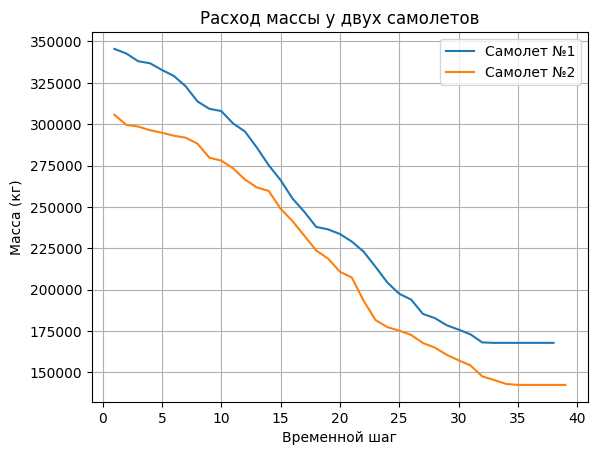

In [ ]:
import json
import matplotlib.pyplot as plt


def plot_two_planes_mass(json_path):
    # Загружаем JSON
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list) or len(data) < 2:
        raise ValueError("В файле должно быть минимум два самолета (список объектов)")

    plane1 = data[0]
    plane2 = data[1]

    path1 = plane1.get("path", [])
    path2 = plane2.get("path", [])

    if not path1 or not path2:
        raise ValueError("У одного из самолетов отсутствует path")

    # Извлекаем время и массу
    t1 = [p["t"] for p in path1]
    m1 = [p["current_mass_kg"] for p in path1]

    t2 = [p["t"] for p in path2]
    m2 = [p["current_mass_kg"] for p in path2]

    # Строим один график
    plt.figure()
    plt.plot(t1, m1, label=f"Самолет №{plane1.get('plane_id', 1)}")
    plt.plot(t2, m2, label=f"Самолет №{plane2.get('plane_id', 2)}")

    plt.xlabel("Временной шаг")
    plt.ylabel("Масса (кг)")
    plt.title("Расход массы у двух самолетов")
    plt.legend()
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    plot_two_planes_mass("two_planes.json")

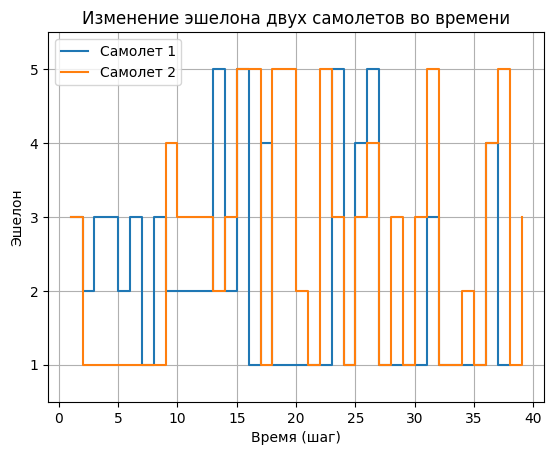

In [ ]:
import json
import matplotlib.pyplot as plt


def plot_two_planes_altitude():
    # Загружаем данные
    with open("two_planes.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list) or len(data) < 2:
        raise ValueError("В файле должно быть минимум два самолета")

    plane1 = data[0]
    plane2 = data[1]

    path1 = plane1.get("path", [])
    path2 = plane2.get("path", [])

    if not path1 or not path2:
        raise ValueError("У одного из самолетов отсутствует path")

    # Время и эшелон
    t1 = [p["t"] for p in path1]
    alt1 = [p["altitude_level"] for p in path1]

    t2 = [p["t"] for p in path2]
    alt2 = [p["altitude_level"] for p in path2]

    # Построение
    plt.figure()

    plt.step(t1, alt1, where="post", label=f"Самолет {plane1.get('plane_id', 1)}")
    plt.step(t2, alt2, where="post", label=f"Самолет {plane2.get('plane_id', 2)}")

    plt.xlabel("Время (шаг)")
    plt.ylabel("Эшелон")
    plt.title("Изменение эшелона двух самолетов во времени")

    # Жестко задаем шкалу эшелонов
    plt.yticks([1, 2, 3, 4, 5])
    plt.ylim(0.5, 5.5)

    plt.grid(True)
    plt.legend()
    plt.show()


if __name__ == "__main__":
    plot_two_planes_altitude()

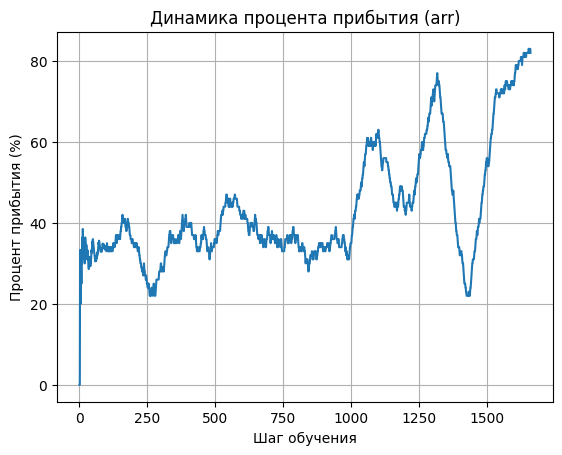

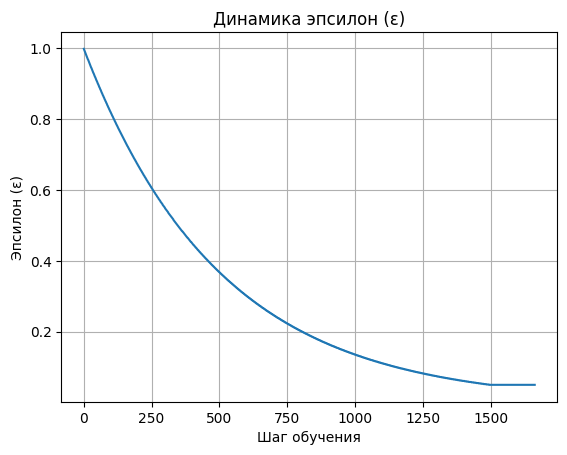

In [ ]:
import re
import matplotlib.pyplot as plt


def plot_arr_and_epsilon():
    filename = "лог вычисления.txt"
    max_step = 1660

    steps = []
    arr_values = []
    epsilon_values = []

    pattern = re.compile(
        r"Эп\s+(\d+)/3000\s+\|\s+Аг1:.*?arr=\s*([\d\.]+)%\s+ε=([\d\.]+)"
    )

    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                step = int(match.group(1))
                if step > max_step:
                    break

                arr = float(match.group(2))
                eps = float(match.group(3))

                steps.append(step)
                arr_values.append(arr)
                epsilon_values.append(eps)

    # --- График ARR ---
    plt.figure()
    plt.plot(steps, arr_values)
    plt.xlabel("Шаг обучения")
    plt.ylabel("Процент прибытия (%)")
    plt.title("Динамика процента прибытия (arr)")
    plt.grid(True)
    plt.show()

    # --- График EPSILON ---
    plt.figure()
    plt.plot(steps, epsilon_values)
    plt.xlabel("Шаг обучения")
    plt.ylabel("Эпсилон (ε)")
    plt.title("Динамика эпсилон (ε)")
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    plot_arr_and_epsilon()